# Experiments for research questions

In [1]:
import numpy as np
import pandas as pd
import torch
import time
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from huggingface_hub import login
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, RocCurveDisplay, mean_squared_error, mean_absolute_error, r2_score, confusion_matrix
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
from scipy import stats

## Datasets

In [2]:
diagnoses = pd.read_csv("data/diagnoosit.csv")
FI_diagnoses = pd.read_csv("data/FI_diagnoosit.csv")
EN_diagnoses = pd.read_csv("data/EN_diagnoosit.csv")
pseudo_diagnoses = pd.read_csv("data/pseudo_diagnoosit.csv")
EN_Bikes = pd.read_csv("data/EN_Bikes.csv")
FI_Bikes = pd.read_csv("data/FI_Bikes.csv")
FI_kumpula = pd.read_csv("data/FI_kumpula_19-25.csv")
EN_kumpula = pd.read_csv("data/EN_kumpula_19-25.csv")

clf_imbalanced_diagnoses =pd.read_csv("data/clf_imbalanced_diagnoosit.csv")
clf_imbalanced_bikes =pd.read_csv("data/clf_imbalanced_bikes.csv")
clf_imbalanced_weather =pd.read_csv("data/clf_imbalanced_weather.csv")

In [3]:
diagnoses = diagnoses[diagnoses["ikaryhma"] != "16-19"]
clf_FI_diagnoses = FI_diagnoses[FI_diagnoses["ikaryhma"] != "16-19"]
clf_EN_diagnoses = EN_diagnoses[EN_diagnoses["age_group"] != "16-19"]
clf_pseudo_diagnoses = pseudo_diagnoses[pseudo_diagnoses["Kloqcrfuej"] != "16-19"]

reg_FI_Bikes = FI_Bikes.drop(columns=["Lähtöaseman id", "Palautusaseman id"])
reg_EN_Bikes = EN_Bikes.drop(columns=["Departure station id", "Return station id"])

clf_EN_Bikes = EN_Bikes[EN_Bikes["Return station name"].isin(["Töölönlahdenkatu", "Itämerentori", "Kamppi (M)", "Ympyrätalo"])]
clf_EN_Bikes = clf_EN_Bikes[EN_Bikes["Departure station name"].isin(["Töölönlahdenkatu", "Itämerentori", "Tyynenmerenkatu", "Salmisaarenranta", "Baana", "Kamppi (M)", "Ympyrätalo"])]
clf_EN_Bikes = clf_EN_Bikes.drop(columns=["Departure station id", "Return station id"])

clf_FI_Bikes = FI_Bikes[FI_Bikes["Palautusaseman nimi"].isin(["Töölönlahdenkatu", "Itämerentori", "Kamppi (M)", "Ympyrätalo"])]
clf_FI_Bikes = clf_FI_Bikes[FI_Bikes["Lähtöaseman nimi"].isin(["Töölönlahdenkatu", "Itämerentori", "Tyynenmerenkatu", "Salmisaarenranta", "Baana", "Kamppi (M)", "Ympyrätalo"])]
clf_FI_Bikes = clf_FI_Bikes.drop(columns=["Lähtöaseman id", "Palautusaseman id"])

clf_imbalanced_bikes = clf_imbalanced_bikes.drop(columns=["Departure station id", "Return station id"])

/tmp/ipykernel_3596701/4001639806.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  clf_EN_Bikes = clf_EN_Bikes[EN_Bikes["Departure station name"].isin(["Töölönlahdenkatu", "Itämerentori", "Tyynenmerenkatu", "Salmisaarenranta", "Baana", "Kamppi (M)", "Ympyrätalo"])]
/tmp/ipykernel_3596701/4001639806.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  clf_FI_Bikes = clf_FI_Bikes[FI_Bikes["Lähtöaseman nimi"].isin(["Töölönlahdenkatu", "Itämerentori", "Tyynenmerenkatu", "Salmisaarenranta", "Baana", "Kamppi (M)", "Ympyrätalo"])]


In [4]:
clf_FI_diagnoses_test = clf_FI_diagnoses.iloc[:500]
clf_FI_diagnoses_train = clf_FI_diagnoses.iloc[500:]

clf_FI_Bikes_test = clf_FI_Bikes.iloc[:500]
clf_FI_Bikes_train = clf_FI_Bikes.iloc[500:]

clf_EN_diagnoses_test = clf_EN_diagnoses.iloc[:500]
clf_EN_diagnoses_train = clf_EN_diagnoses.iloc[500:]

clf_EN_Bikes_test = clf_EN_Bikes.iloc[:500]
clf_EN_Bikes_train = clf_EN_Bikes.iloc[500:]

reg_FI_diagnoses_test = FI_diagnoses.iloc[:500]
reg_FI_diagnoses_train = FI_diagnoses.iloc[500:]

reg_FI_Bikes_test = reg_FI_Bikes.iloc[:500]
reg_FI_Bikes_train = reg_FI_Bikes.iloc[500:]

reg_EN_diagnoses_test = EN_diagnoses.iloc[:500]
reg_EN_diagnoses_train = EN_diagnoses.iloc[500:]

reg_EN_Bikes_test = reg_EN_Bikes.iloc[:500]
reg_EN_Bikes_train = reg_EN_Bikes.iloc[500:]

FI_kumpula_test = FI_kumpula.iloc[:500]
FI_kumpula_train = FI_kumpula.iloc[500:]

EN_kumpula_test = EN_kumpula.iloc[:500]
EN_kumpula_train = EN_kumpula.iloc[500:]

clf_imbalanced_diagnoses_test = clf_imbalanced_diagnoses.iloc[:500]
clf_imbalanced_diagnoses_train = clf_imbalanced_diagnoses.iloc[500:]

clf_imbalanced_bikes_test = clf_imbalanced_bikes.iloc[:500]
clf_imbalanced_bikes_train = clf_imbalanced_bikes.iloc[500:]

clf_imbalanced_weather_test = clf_imbalanced_weather.iloc[:500]
clf_imbalanced_weather_train = clf_imbalanced_weather.iloc[500:]

### Classes

In [5]:
classes_of_interest1 = ["55-59", "60-64", "20-24", "65-67"]
classes_of_interest2 = ["Töölönlahdenkatu", "Itämerentori", "Kamppi (M)", "Ympyrätalo"]
classes_of_interest3 = ["Heikkoa lumisadetta", "Heikkoa vesisadetta", "Utua", "Heikkoja vesikuuroja", "Tihkusadetta tai lumijyväsiä edellisen tunnin aikana, mutta ei enää havaintohetkellä", "Heikkoa tai kohtalaista sadetta", "Heikkoja lumikuuroja"]
classes_of_interest4 = ["Light snow", "Light rain", "Mist", "Light rain showers", "Drizzle or snow grains during the preceding hour, but not at the time of observation", "Light or moderate precipitation", "Light snow showers"]
classes_of_interest5 = ["55-59","20-24", "25-29", "65-67"]
classes_of_interest6= ["Munkkiniemen aukio", "Innopoli", "Puotinkylän kartano", "Linnuntie", "Huovitie"]
classes_of_interest7 = ["Ei merkittäviä sääilmiöitä", "Heikkoa lumisadetta", "Heikkoa vesisadetta"]
classes_of_interest8 = ["55-59", "50-54", "45-49", "40-44", "35-39", "30-34", "25-29", "20-24", "65-67", "16-19"]

## Models

In [6]:
from tabpfn import TabPFNClassifier, TabPFNRegressor
from tabpfn.constants import ModelVersion
TabPFN_classifier = TabPFNClassifier.create_default_for_version(ModelVersion.V2_5)
TabPFN_regressor = TabPFNRegressor.create_default_for_version(ModelVersion.V2_5)

from tabicl import TabICLClassifier, TabICLRegressor
TabICL_classifier = TabICLClassifier()
TabICL_regressor = TabICLRegressor()

from sap_rpt_oss import SAP_RPT_OSS_Classifier, SAP_RPT_OSS_Regressor
ConTextTab_classifier = SAP_RPT_OSS_Classifier(max_context_size=8192, bagging=8)
ConTextTab_regressor = SAP_RPT_OSS_Regressor(max_context_size=8192, bagging=8)

from catboost import CatBoostClassifier, CatBoostRegressor
cb_classifier = CatBoostClassifier(verbose = False)
cb_regressor = CatBoostRegressor(verbose = False)

import xgboost as xgb
xgb_classifier = xgb.XGBClassifier(n_estimators=100)
xgb_regressor = xgb.XGBRegressor(n_estimators=100)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Evaluate Models and create result-tables

In [7]:
def clf_eval_model(y_true, y_pred, train_set, model, n, prints):
    acc = accuracy_score(y_true, y_pred)
    if prints:
        print(f"{model} with trainingset size {n}, Accuracy: {acc}")
    return acc, train_set

In [8]:
def reg_eval_model(y_true, y_pred, model, n, prints=True):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    if prints:
        print(f"{model} with training set of {n}: R2-score: {r2}, mean absolute error: {mae}, mean squared error: {mse}")

### Model comparisons

In [9]:
def clf_model_comparison(n, column, df_train, df_test, models, classes_of_interest, df_names, model_names, k_folds, multiple_columns = False, ROC_curves=True, prints=True, encoded_classes=None, categoricals=None, int_variables=None, float_variables=None):
    info = []
    d = {"size":[], "model": [], "accuracy": []}
    for df, df_name in zip(df_train, df_names):
        for subset in n:
            train_set = df.iloc[:subset]
            for model, model_name in zip (models, model_names):
                name = f"{df_name}_{model_name}"
                X_train = train_set.drop(column, axis=1)
                y_train = train_set[column]
                X_test = df_test.drop(column, axis=1)
                y_test = df_test[column]
                if "XGBoost" in name:
                    y_train = LabelEncoder().fit_transform(y_train)
                    y_test = LabelEncoder().fit_transform(y_test)
                label_binarizer = LabelBinarizer().fit(y_train)
                onehot_y_test = label_binarizer.transform(y_test)
                scores = cross_val_score(model, X_train, y_train, cv=k_folds, scoring="accuracy")
                mean_acc = scores.mean()
                std = scores.std()
                if "CatBoost" in name:
                    start_time = time.time()
                    clf = model.fit(X_train, y_train, verbose = False)
                    end_time = time.time()
                else:
                    start_time = time.time()
                    clf = model.fit(X_train, y_train)
                    end_time = time.time()
                total_runtime = end_time-start_time
                print(f"Total runtime for model fitting: {total_runtime} seconds")
                pred = clf.predict(X_test)
                y_score = clf.predict_proba(X_test)
                acc, trainingset = clf_eval_model(y_test, pred, train_set, name, subset, prints)
                print(f"Mean accuracy: {mean_acc}, Standard deviation: {std}")
                if "imbalanced" in name:
                    f1 = f1_score(y_test, pred, average="macro")
                    recall = recall_score(y_test, pred, average="macro")
                    print(f"Macro f1-score: {f1}, Macro recall-score: {recall}")
                    cm = confusion_matrix(y_test, pred)
                    sns.heatmap(cm, annot = True, xticklabels = classes_of_interest, yticklabels = classes_of_interest)
                    plt.xlabel("Predicted")
                    plt.ylabel("Actual")
                    plt.title(f"{model_name} with {subset} samples")
                    plt.show()
                d["size"].append(subset)
                d["model"].append(model_name)
                d["accuracy"].append(acc)
                info.append({"model_name" : name,
                        "subset_size": subset,
                        "label_binarizer": label_binarizer,
                        "onehot_y_test": onehot_y_test,
                        "y_score": y_score                       
                        })
    if ROC_curves:
        if encoded_classes:            
            for class_of_interest, encoded_class in zip(classes_of_interest, encoded_classes):
                fig, ax = plt.subplots()
                for row in info:
                    if "XGBoost" not in row["model_name"]:
                        class_indices = np.flatnonzero(row["label_binarizer"].classes_ == class_of_interest)[0]
                        RocCurveDisplay.from_predictions(
                            row["onehot_y_test"][:, class_indices],
                            row["y_score"][:, class_indices],
                            name = f"{row["model_name"]} n={row["subset_size"]}",
                            ax=ax,
                            despine=True,
                            )
                    else:
                        class_indices = np.flatnonzero(row["label_binarizer"].classes_ == encoded_class)[0]
                        RocCurveDisplay.from_predictions(
                            row["onehot_y_test"][:, class_indices],
                            row["y_score"][:, class_indices],
                            name = f"{row["model_name"]} n={row["subset_size"]}",
                            ax=ax,
                            despine=True,
                            )
                    
                _=ax.set(
                    xlabel="False Positive Rate",
                    ylabel="True Positive Rate",
                    title=f"One-vs-Rest ROC curves (class={class_of_interest}):",
                )
        else:
            for class_of_interest in classes_of_interest:
                fig, ax = plt.subplots()
                for row in info:
                    if "XGBoost" not in row["model_name"]:
                        class_indices = np.flatnonzero(row["label_binarizer"].classes_ == class_of_interest)[0]
                        RocCurveDisplay.from_predictions(
                            row["onehot_y_test"][:, class_indices],
                            row["y_score"][:, class_indices],
                            name = f"{row["model_name"]} n={row["subset_size"]}",
                            ax=ax,
                            despine=True,
                            )
            _=ax.set(
                    xlabel="False Positive Rate",
                    ylabel="True Positive Rate",
                    title=f"One-vs-Rest ROC curves (class={class_of_interest}):",
            )

In [10]:
def reg_model_comparison(n, column, df_train, df_test, models, df_names, model_names, k_folds, categoricals=None, int_variables=None, float_variables=None, drop_columns=None):
    info = []
    d = {"size":[], "model": [], "r2_score": [], "runtime": []}
    for df, df_name in zip(df_train, df_names):
        for subset in n:
            train_set = df.iloc[:subset]
            for model, model_name in zip (models, model_names):
                name = f"{df_name}_{model_name}"
                X_train = train_set.drop(column, axis=1)
                y_train = train_set[column]
                X_test = df_test.drop(column, axis=1)
                y_test = df_test[column]
                scores = cross_val_score(model, X_train, y_train, cv=k_folds, scoring="r2")
                mean_r2 = scores.mean()
                std = scores.std()
                print(f"Training set size: {subset}, Mean R2 score: {mean_r2}, Standard deviation: {std}")
                if "CatBoost" in name:
                    start_time = time.time()
                    reg = model.fit(X_train, y_train, verbose = False)
                    end_time = time.time()
                else:
                    start_time = time.time()
                    reg = model.fit(X_train, y_train)
                    end_time = time.time()
                total_runtime = (end_time-start_time)
                print(f"Total runtime for model fitting: {total_runtime} seconds")
                pred = reg.predict(X_test)
                reg_eval_model(y_test, pred, name, subset)
                d["size"].append(subset)
                d["model"].append(model_name)
                d["r2_score"].append(mean_r2)
                d["runtime"].append(total_runtime)
                info.append({"model_name" : name,
                            "subset_size": subset,              
                            })

In [11]:
def reg_model_comparison2(n, column, df_train, df_test, models, df_names, model_names, k_folds, prints=True, categoricals=None, int_variables=None, float_variables=None, drop_columns=None):
    info = []
    d = {"size":[], "model": [], "r2_score": [], "runtime": []}
    for df_name in df_names:
        for model, model_name in zip (models, model_names):
            name = f"{df_name}_{model_name}"
            if ("CatBoost" in name) or ("XGBoost" in name):
                df = df_train[1]
                test_df = df_test[1]
            else:
                df = df_train[0]
                test_df = df_test[0]
            for subset in n:
                train_set = df.iloc[:subset]
                X_train = train_set.drop(column, axis=1)
                y_train = train_set[column]
                X_test = test_df.drop(column, axis=1)
                y_test = test_df[column]
                scores = cross_val_score(model, X_train, y_train, cv=k_folds, scoring="r2")
                mean_r2 = scores.mean()
                std = scores.std()
                print(f"Training set size: {subset}, Mean R2 score: {mean_r2}, Standard deviation: {std}")
                if "CatBoost" in name:
                    start_time = time.time()
                    reg = model.fit(X_train, y_train, verbose = False)
                    end_time = time.time()
                else:
                    start_time = time.time()
                    reg = model.fit(X_train, y_train)
                    end_time = time.time()
                total_runtime = (end_time-start_time)
                print(f"Total runtime for model fitting: {total_runtime} seconds")
                pred = reg.predict(X_test)
                reg_eval_model(y_test, pred, name, subset, prints)
                d["size"].append(subset)
                d["model"].append(model_name)
                d["r2_score"].append(mean_r2)
                d["runtime"].append(total_runtime)
                info.append({"model_name" : name,
                            "subset_size": subset,              
                            })
    return d

In [12]:
def modify_df(df, int_variables, float_variables, categoricals=None):
    df = df.replace("-", None)
    df.columns = df.columns.str.replace("[", "(", regex=False)
    df.columns = df.columns.str.replace("]", ")", regex=False)
    df.columns = df.columns.str.replace("<", " ", regex=False)
    df.columns = df.columns.str.replace(">", " ", regex=False)
    if categoricals:
        df_encoded = pd.get_dummies(df[categoricals], dtype=int)
        df = df.join(df_encoded)
        df = df.drop(categoricals, axis=1)
    df[int_variables]=df[int_variables].astype(int)
    df[float_variables]=df[float_variables].astype(float)
    df = df.replace("-", None)
    df.columns = df.columns.str.replace("[", "(", regex=False)
    df.columns = df.columns.str.replace("]", ")", regex=False)
    df.columns = df.columns.str.replace("<", " ", regex=False)
    df.columns = df.columns.str.replace(">", " ", regex=False)
    return df

In [13]:
def k_fold_cv_tests(k_folds, n, column, df, model, model_name):
    test_df = df.iloc[:n]
    if ("CatBoost" in model_name) or ("XGBoost" in model_name):
        df2 = modify_df(test_df, categoricals, int_variables, float_variables)
        X2 = df2.drop(column, axis=1)
        y2 = df2[column]
        if model == xgb_classifier:
            y2 = LabelEncoder().fit_transform(y2)
        scores = cross_val_score(model, X2, y2, cv=k_folds, scoring="accuracy")

    else:
        X = test_df.drop(column, axis=1)
        y = test_df[column]
        scores = cross_val_score(model, X, y, cv=k_folds, scoring="accuracy")

    return scores

### Plots

In [14]:
def create_scatterplot(d, dataset_name):
    df = pd.DataFrame(data=d)
    sns.scatterplot(x="size", y="r2_score", hue="model", data=df)
    plt.title("r2_score vs. trainingset size")
    plt.show()

def create_scatterplot_runtimes(d, dataset_name):
    df = pd.DataFrame(data=d)
    sns.scatterplot(x="size", y="runtime", hue="model", data=df)
    plt.title(f"runtimes vs. trainingset size ({dataset_name})")
    plt.show()

### Folds

In [15]:
rskf = RepeatedStratifiedKFold(n_splits = 5, n_repeats = 2, random_state = 25)
k_folds = KFold(n_splits = 5, shuffle=True, random_state = 25)

## Diagnoses

### Diagnoses classification (trainingsets sizes 100, 1000, 2000 and 5000)

#### TabPFN classifier

In [21]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_FI_diagnoses_train], clf_FI_diagnoses_test, [TabPFN_classifier], classes_of_interest1, ["FI_diagnoses"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.24477291107177734 seconds
FI_diagnoses_TabPFN_classifier with trainingset size 100, Accuracy: 0.162
Mean accuracy: 0.17500000000000002, Standard deviation: 0.08139410298049853
Total runtime for model fitting: 0.303081750869751 seconds
FI_diagnoses_TabPFN_classifier with trainingset size 1000, Accuracy: 0.332
Mean accuracy: 0.3075, Standard deviation: 0.03002082610455615
Total runtime for model fitting: 0.36740684509277344 seconds
FI_diagnoses_TabPFN_classifier with trainingset size 2000, Accuracy: 0.352
Mean accuracy: 0.3504999999999999, Standard deviation: 0.020396078054371138
Total runtime for model fitting: 0.5375375747680664 seconds
FI_diagnoses_TabPFN_classifier with trainingset size 5000, Accuracy: 0.388
Mean accuracy: 0.4008999999999999, Standard deviation: 0.017426703646989575


In [22]:
clf_model_comparison([100, 1000, 2000, 5000], "age_group", [clf_EN_diagnoses_train], clf_EN_diagnoses_test, [TabPFN_classifier], classes_of_interest1, ["EN_diagnoses"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.24438810348510742 seconds
EN_diagnoses_TabPFN_classifier with trainingset size 100, Accuracy: 0.2
Mean accuracy: 0.21000000000000002, Standard deviation: 0.06244997998398398
Total runtime for model fitting: 0.30194616317749023 seconds
EN_diagnoses_TabPFN_classifier with trainingset size 1000, Accuracy: 0.318
Mean accuracy: 0.3155, Standard deviation: 0.03028613544181562
Total runtime for model fitting: 0.3612816333770752 seconds
EN_diagnoses_TabPFN_classifier with trainingset size 2000, Accuracy: 0.342
Mean accuracy: 0.34825, Standard deviation: 0.02770491833592007
Total runtime for model fitting: 0.540374755859375 seconds
EN_diagnoses_TabPFN_classifier with trainingset size 5000, Accuracy: 0.404
Mean accuracy: 0.40659999999999996, Standard deviation: 0.014207040508142423


Total runtime for model fitting: 0.23671984672546387 seconds
not_imbalanced_diagnoses_TabPFN_classifier with trainingset size 100, Accuracy: 0.162
Mean accuracy: 0.17500000000000002, Standard deviation: 0.08139410298049853
Macro f1-score: 0.13912136710749304, Macro recall-score: 0.17501101714030415


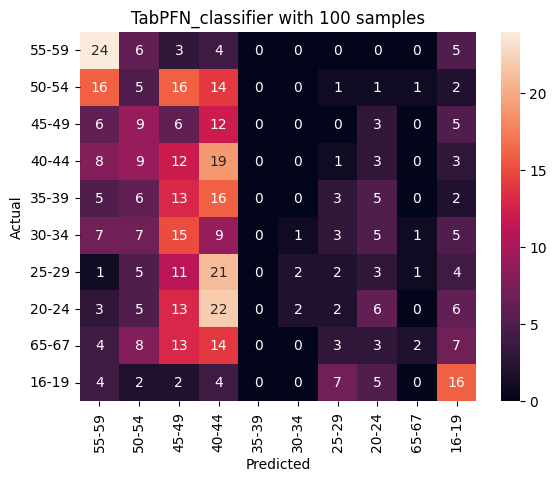

Total runtime for model fitting: 0.2952308654785156 seconds
not_imbalanced_diagnoses_TabPFN_classifier with trainingset size 1000, Accuracy: 0.332
Mean accuracy: 0.3075, Standard deviation: 0.03002082610455615
Macro f1-score: 0.31335401233548915, Macro recall-score: 0.3496010028920244


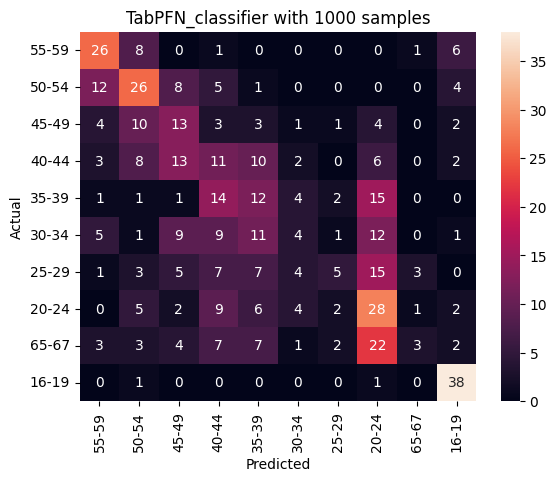

Total runtime for model fitting: 0.34831881523132324 seconds
not_imbalanced_diagnoses_TabPFN_classifier with trainingset size 2000, Accuracy: 0.352
Mean accuracy: 0.3504999999999999, Standard deviation: 0.020396078054371138
Macro f1-score: 0.3498150171917148, Macro recall-score: 0.368005119576625


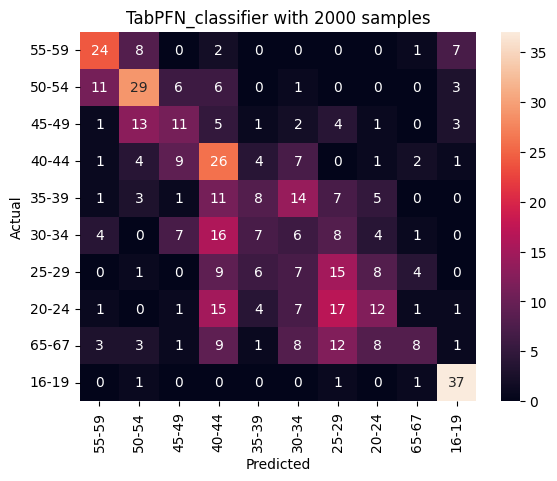

Total runtime for model fitting: 0.5204229354858398 seconds
not_imbalanced_diagnoses_TabPFN_classifier with trainingset size 5000, Accuracy: 0.388
Mean accuracy: 0.4008999999999999, Standard deviation: 0.017426703646989575
Macro f1-score: 0.3908697855833242, Macro recall-score: 0.3987025072146789


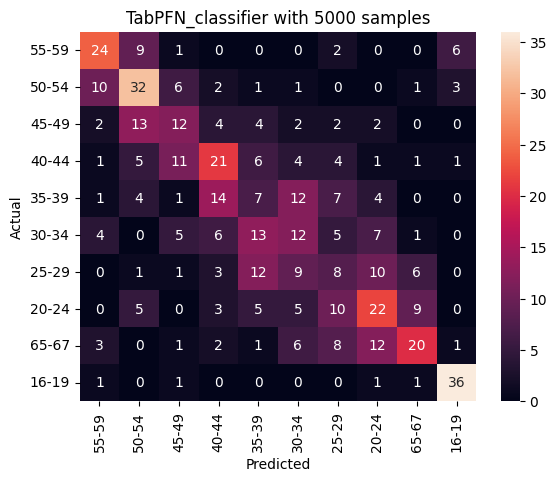

In [23]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_FI_diagnoses_train], clf_FI_diagnoses_test, [TabPFN_classifier], classes_of_interest8, ["not_imbalanced_diagnoses"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.23730254173278809 seconds
imbalanced_diagnoses_TabPFN_classifier with trainingset size 100, Accuracy: 0.47
Mean accuracy: 0.58, Standard deviation: 0.055677643628300216
Macro f1-score: 0.22420389208314906, Macro recall-score: 0.28755175983436854


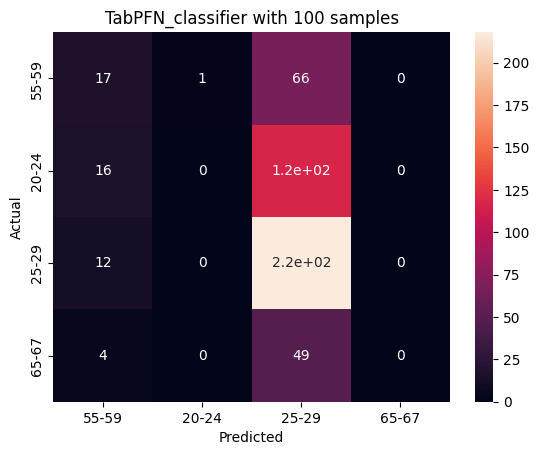

Total runtime for model fitting: 0.5207939147949219 seconds
imbalanced_diagnoses_TabPFN_classifier with trainingset size 1000, Accuracy: 0.54
Mean accuracy: 0.5309999999999999, Standard deviation: 0.029308701779505692
Macro f1-score: 0.36964212148530157, Macro recall-score: 0.3995940939304784


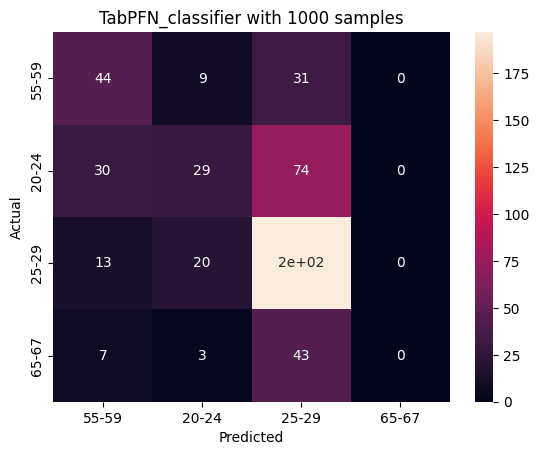

Total runtime for model fitting: 0.3531346321105957 seconds
imbalanced_diagnoses_TabPFN_classifier with trainingset size 2000, Accuracy: 0.55
Mean accuracy: 0.5149999999999999, Standard deviation: 0.02009353129741012
Macro f1-score: 0.4181098853478343, Macro recall-score: 0.43704107479527365


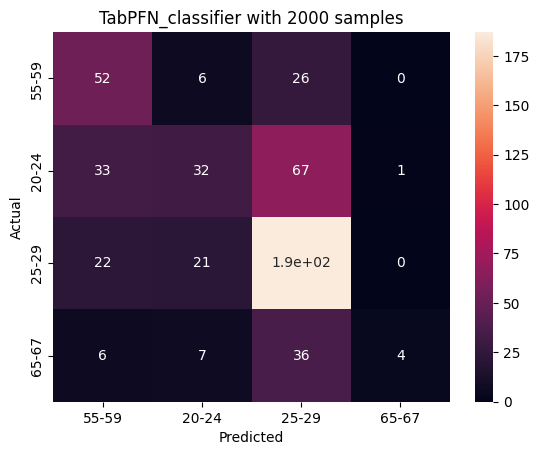

Total runtime for model fitting: 0.5244259834289551 seconds
imbalanced_diagnoses_TabPFN_classifier with trainingset size 5000, Accuracy: 0.568
Mean accuracy: 0.5315000000000001, Standard deviation: 0.010082162466455309
Macro f1-score: 0.43641929323008943, Macro recall-score: 0.449053468371503


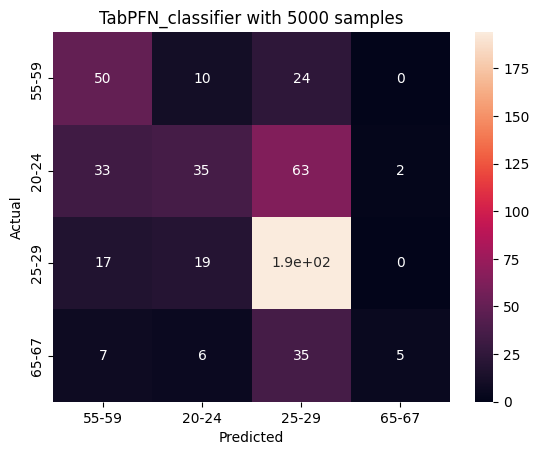

In [24]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_imbalanced_diagnoses_train], clf_imbalanced_diagnoses_test, [TabPFN_classifier], classes_of_interest5, ["imbalanced_diagnoses"], ["TabPFN_classifier"], rskf, False, False)

#### TabICL classifier

In [25]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_FI_diagnoses_train], clf_FI_diagnoses_test, [TabICL_classifier], classes_of_interest1, ["FI_diagnoses"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.5424785614013672 seconds
FI_diagnoses_TabICL_classifier with trainingset size 100, Accuracy: 0.206
Mean accuracy: 0.205, Standard deviation: 0.04153311931459037
Total runtime for model fitting: 0.5120265483856201 seconds
FI_diagnoses_TabICL_classifier with trainingset size 1000, Accuracy: 0.314
Mean accuracy: 0.29050000000000004, Standard deviation: 0.03335041229130459
Total runtime for model fitting: 0.5073328018188477 seconds
FI_diagnoses_TabICL_classifier with trainingset size 2000, Accuracy: 0.378
Mean accuracy: 0.36325, Standard deviation: 0.024926140896657078
Total runtime for model fitting: 0.5407683849334717 seconds
FI_diagnoses_TabICL_classifier with trainingset size 5000, Accuracy: 0.474
Mean accuracy: 0.4287000000000001, Standard deviation: 0.014697278659670302


In [26]:
clf_model_comparison([100, 1000, 2000, 5000], "age_group", [clf_EN_diagnoses_train], clf_EN_diagnoses_test, [TabICL_classifier], classes_of_interest1, ["EN_diagnoses"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.49151110649108887 seconds
EN_diagnoses_TabICL_classifier with trainingset size 100, Accuracy: 0.204
Mean accuracy: 0.20500000000000002, Standard deviation: 0.052201532544552745
Total runtime for model fitting: 0.49272894859313965 seconds
EN_diagnoses_TabICL_classifier with trainingset size 1000, Accuracy: 0.322
Mean accuracy: 0.2945, Standard deviation: 0.02944910864525444
Total runtime for model fitting: 0.5047872066497803 seconds
EN_diagnoses_TabICL_classifier with trainingset size 2000, Accuracy: 0.368
Mean accuracy: 0.35900000000000004, Standard deviation: 0.023510635891017505
Total runtime for model fitting: 0.5483174324035645 seconds
EN_diagnoses_TabICL_classifier with trainingset size 5000, Accuracy: 0.47
Mean accuracy: 0.42729999999999996, Standard deviation: 0.013439121995130485


Total runtime for model fitting: 0.5073592662811279 seconds
not_imbalanced_diagnoses_TabICL_classifier with trainingset size 100, Accuracy: 0.206
Mean accuracy: 0.205, Standard deviation: 0.04153311931459037
Macro f1-score: 0.18817814685944773, Macro recall-score: 0.22415961539328047


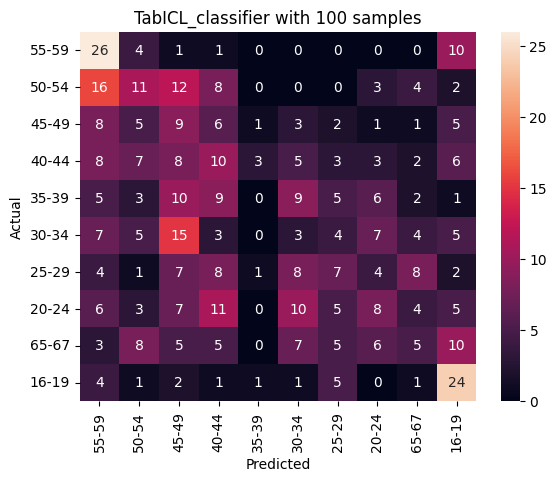

Total runtime for model fitting: 0.4876117706298828 seconds
not_imbalanced_diagnoses_TabICL_classifier with trainingset size 1000, Accuracy: 0.314
Mean accuracy: 0.29050000000000004, Standard deviation: 0.03335041229130459
Macro f1-score: 0.30977472470920214, Macro recall-score: 0.33363887802663766


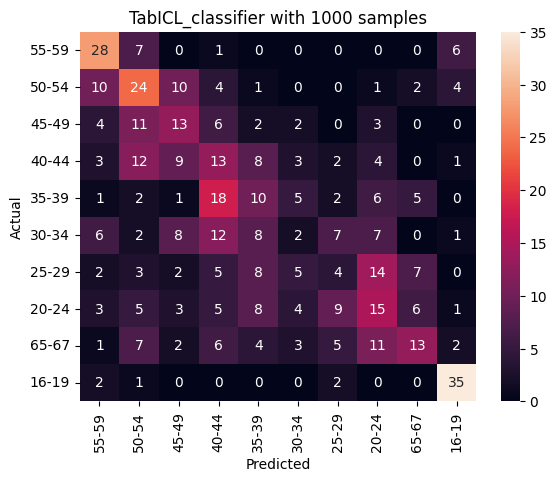

Total runtime for model fitting: 0.507904052734375 seconds
not_imbalanced_diagnoses_TabICL_classifier with trainingset size 2000, Accuracy: 0.378
Mean accuracy: 0.36325, Standard deviation: 0.024926140896657078
Macro f1-score: 0.3761950722841809, Macro recall-score: 0.39315510774004464


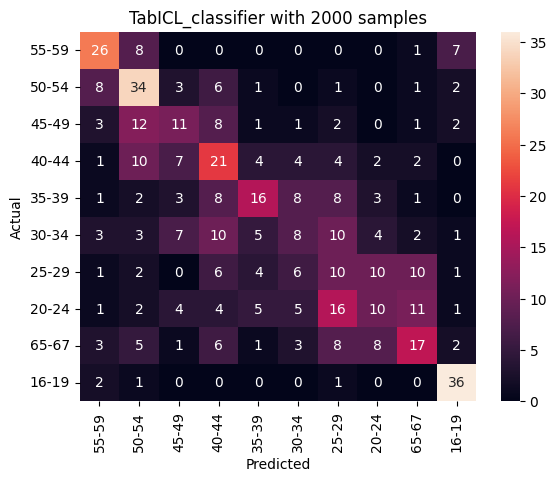

Total runtime for model fitting: 0.5384149551391602 seconds
not_imbalanced_diagnoses_TabICL_classifier with trainingset size 5000, Accuracy: 0.474
Mean accuracy: 0.4287000000000001, Standard deviation: 0.014697278659670302
Macro f1-score: 0.47878888096929384, Macro recall-score: 0.48520531411381357


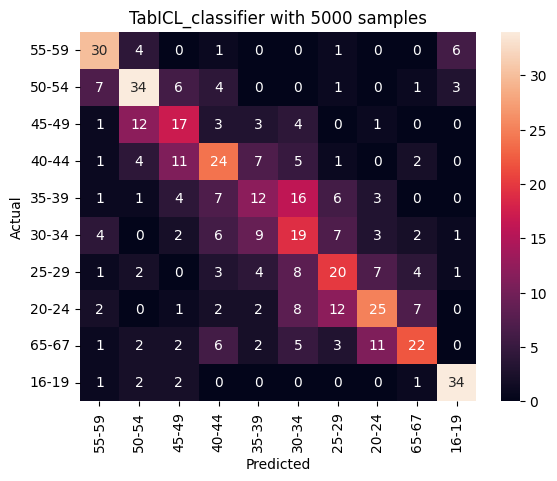

In [27]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_FI_diagnoses_train], clf_FI_diagnoses_test, [TabICL_classifier], classes_of_interest8, ["not_imbalanced_diagnoses"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.47904229164123535 seconds
imbalanced_diagnoses_TabICL_classifier with trainingset size 100, Accuracy: 0.484
Mean accuracy: 0.54, Standard deviation: 0.08306623862918076
Macro f1-score: 0.26596192679168, Macro recall-score: 0.3318486433474992


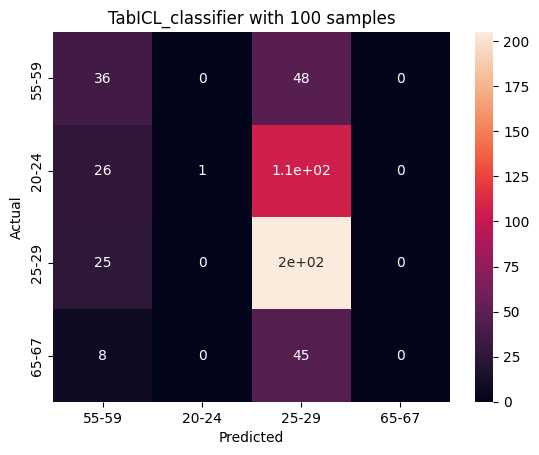

Total runtime for model fitting: 0.5008559226989746 seconds
imbalanced_diagnoses_TabICL_classifier with trainingset size 1000, Accuracy: 0.582
Mean accuracy: 0.5345, Standard deviation: 0.02893527259246056
Macro f1-score: 0.4503931922730588, Macro recall-score: 0.46016682395077113


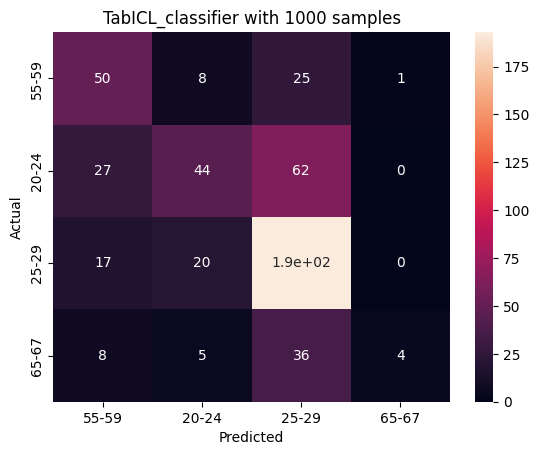

Total runtime for model fitting: 0.5212101936340332 seconds
imbalanced_diagnoses_TabICL_classifier with trainingset size 2000, Accuracy: 0.578
Mean accuracy: 0.55525, Standard deviation: 0.01807795618979093
Macro f1-score: 0.4803862860499877, Macro recall-score: 0.4865073111408546


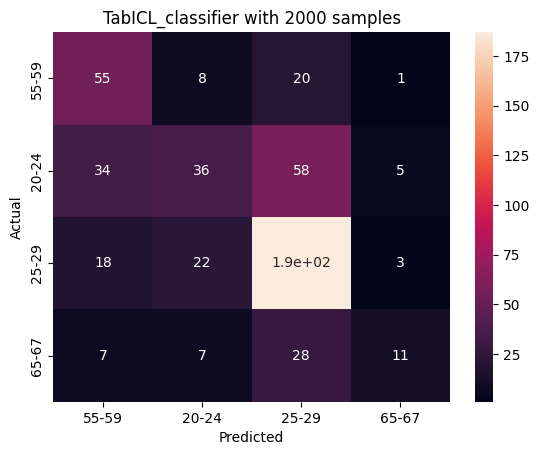

Total runtime for model fitting: 0.5582740306854248 seconds
imbalanced_diagnoses_TabICL_classifier with trainingset size 5000, Accuracy: 0.61
Mean accuracy: 0.5829, Standard deviation: 0.013874076545846227
Macro f1-score: 0.5275128938595867, Macro recall-score: 0.5235456617343194


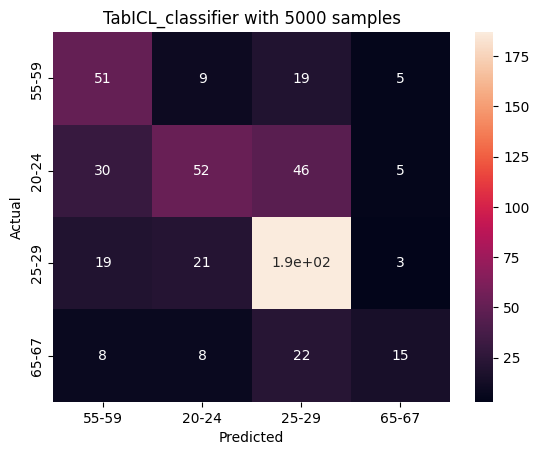

In [28]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_imbalanced_diagnoses_train], clf_imbalanced_diagnoses_test, [TabICL_classifier], classes_of_interest5, ["imbalanced_diagnoses"], ["TabICL_classifier"], rskf, False, False)

#### ConTextTab classifier

In [29]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_FI_diagnoses_train], clf_FI_diagnoses_test, [ConTextTab_classifier], classes_of_interest1, ["FI_diagnoses"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0037336349487304688 seconds
FI_diagnoses_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.36
Mean accuracy: 0.33310000000000006, Standard deviation: 0.004908156476723215


In [30]:
clf_model_comparison([100, 1000, 2000, 5000], "age_group", [clf_EN_diagnoses_train], clf_EN_diagnoses_test, [ConTextTab_classifier], classes_of_interest1, ["EN_diagnoses"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0037469863891601562 seconds
EN_diagnoses_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.326
Mean accuracy: 0.328, Standard deviation: 0.007823042886243185


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0005614757537841797 seconds
not_imbalanced_diagnoses_ConTextTab_classifier with trainingset size 100, Accuracy: 0.222
Mean accuracy: 0.185, Standard deviation: 0.10259142264341595
Macro f1-score: 0.21543509574451242, Macro recall-score: 0.2457366420206398


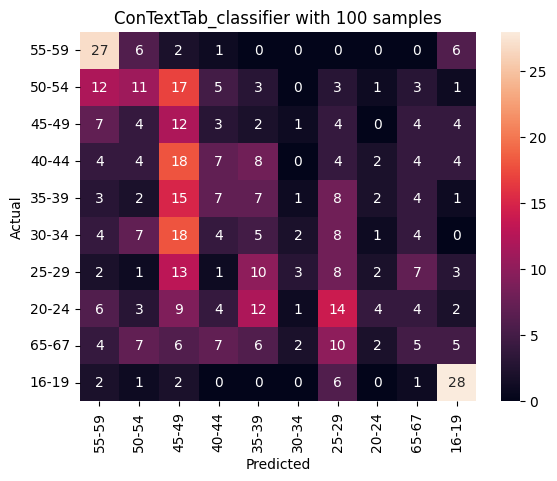

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0009672641754150391 seconds
not_imbalanced_diagnoses_ConTextTab_classifier with trainingset size 1000, Accuracy: 0.322
Mean accuracy: 0.27949999999999997, Standard deviation: 0.02196019125599774
Macro f1-score: 0.31514029214663913, Macro recall-score: 0.3383221920870489


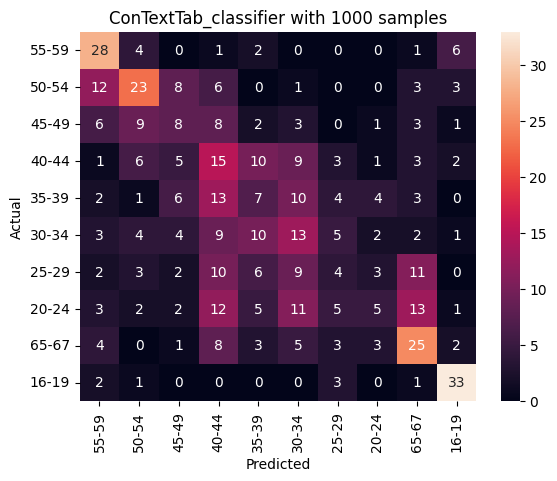

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0017554759979248047 seconds
not_imbalanced_diagnoses_ConTextTab_classifier with trainingset size 2000, Accuracy: 0.358
Mean accuracy: 0.33499999999999996, Standard deviation: 0.021505813167606566
Macro f1-score: 0.3503525324547968, Macro recall-score: 0.3754331156275941


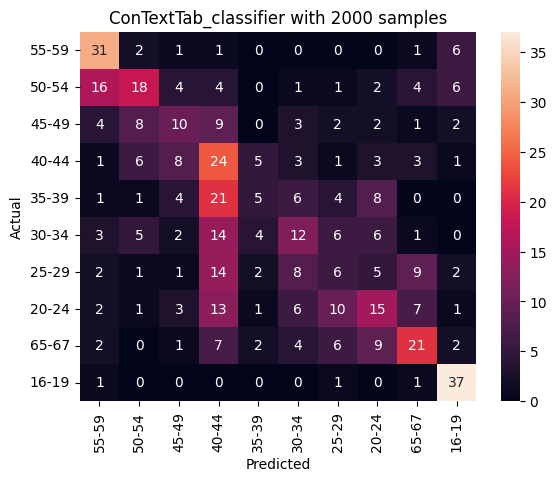

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0037505626678466797 seconds
not_imbalanced_diagnoses_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.36
Mean accuracy: 0.33310000000000006, Standard deviation: 0.004908156476723215
Macro f1-score: 0.3479265531033689, Macro recall-score: 0.37939546224948345


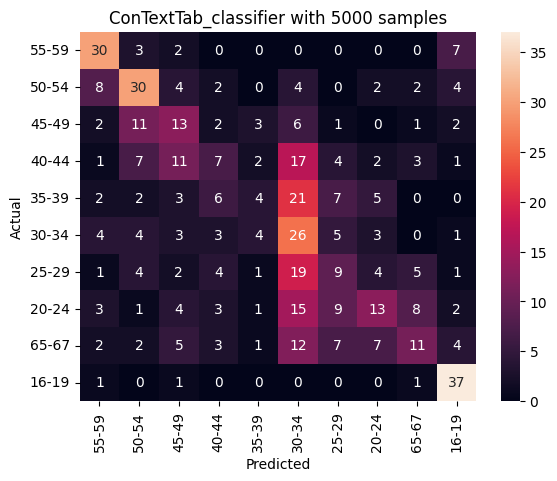

In [31]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_FI_diagnoses_train], clf_FI_diagnoses_test, [ConTextTab_classifier], classes_of_interest8, ["not_imbalanced_diagnoses"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0005066394805908203 seconds
imbalanced_diagnoses_ConTextTab_classifier with trainingset size 100, Accuracy: 0.496
Mean accuracy: 0.56, Standard deviation: 0.058309518948452994
Macro f1-score: 0.2765827922077922, Macro recall-score: 0.3489130434782609


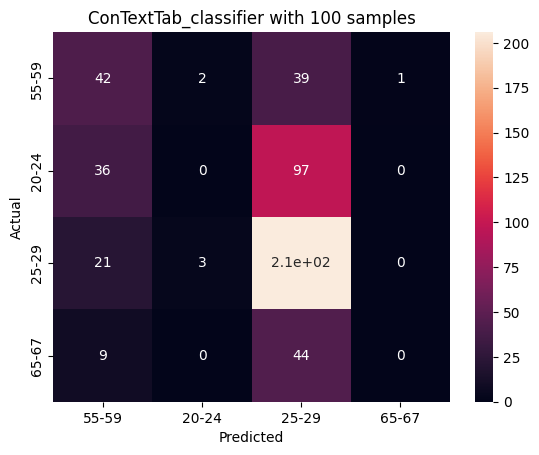

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0009567737579345703 seconds
imbalanced_diagnoses_ConTextTab_classifier with trainingset size 1000, Accuracy: 0.536
Mean accuracy: 0.5145000000000001, Standard deviation: 0.017670597047072308
Macro f1-score: 0.43151009853112277, Macro recall-score: 0.43974489649061127


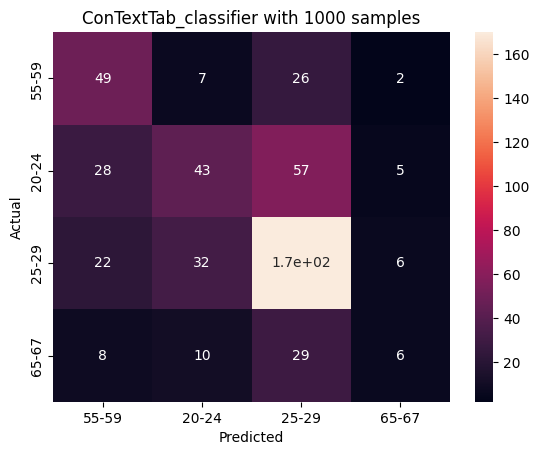

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0016317367553710938 seconds
imbalanced_diagnoses_ConTextTab_classifier with trainingset size 2000, Accuracy: 0.546
Mean accuracy: 0.5215, Standard deviation: 0.028530685235374213
Macro f1-score: 0.4812731621202386, Macro recall-score: 0.48242797313217417


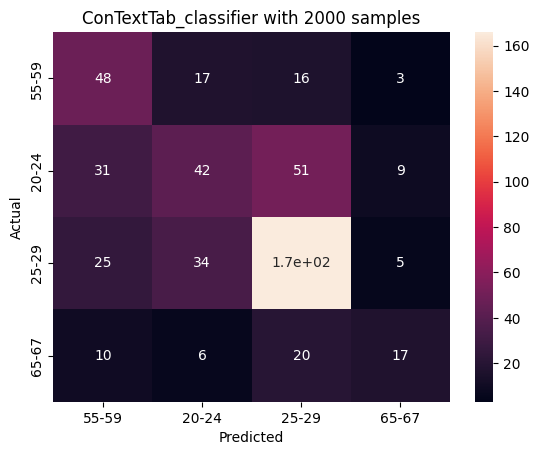

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0036749839782714844 seconds
imbalanced_diagnoses_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.574
Mean accuracy: 0.5546, Standard deviation: 0.012306096050332102
Macro f1-score: 0.5170701890616596, Macro recall-score: 0.5115947682989261


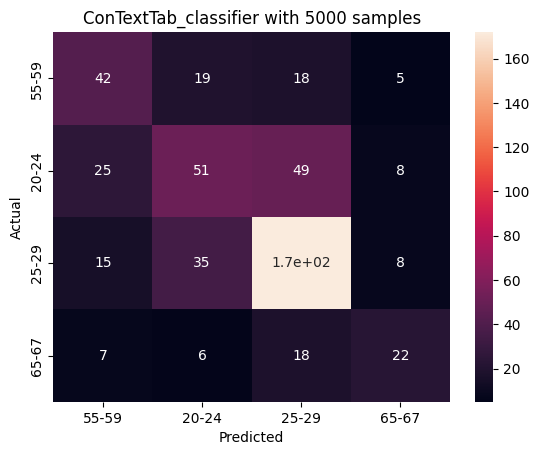

In [32]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [clf_imbalanced_diagnoses_train], clf_imbalanced_diagnoses_test, [ConTextTab_classifier], classes_of_interest5, ["imbalanced_diagnoses"], ["ConTextTab_classifier"], rskf, False, False)

#### XGBoost classifier

##### Preprosessing needed for tree methods

In [37]:
categories = ["aikatyyppi", "sukupuoli", "etuus", "diagnoosi"]
int_vals = ["kuukausi_nro", "vuosi", "alkanut_kausi_lkm"]
float_vals = ["ka_paiva_lkm", "ka_maksettu/paiva"]
GBDT_imbalanced_diagnoses = modify_df(clf_imbalanced_diagnoses, int_vals, float_vals, categories)
GBDT_clf_FI_diagnoses = modify_df(clf_FI_diagnoses, int_vals, float_vals, categories)

categories = ["time_category", "sex", "benefit_type", "diagnosis"]
int_vals = ["month_number", "year", "benefit_periods_started"]
float_vals = ["average_number_of_days", "average_amount_paid/day"]
GBDT_clf_EN_diagnoses = modify_df(clf_EN_diagnoses, int_vals, float_vals, categories)

In [38]:
GBDT_clf_FI_diagnoses_test = GBDT_clf_FI_diagnoses.iloc[:500]
GBDT_clf_FI_diagnoses_train = GBDT_clf_FI_diagnoses.iloc[500:]

GBDT_imbalanced_diagnoses_test = GBDT_imbalanced_diagnoses.iloc[:500]
GBDT_imbalanced_diagnoses_train = GBDT_imbalanced_diagnoses.iloc[500:]

GBDT_clf_EN_diagnoses_test = GBDT_clf_EN_diagnoses.iloc[:500]
GBDT_clf_EN_diagnoses_train = GBDT_clf_EN_diagnoses.iloc[500:]

In [35]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [GBDT_clf_FI_diagnoses_train], GBDT_clf_FI_diagnoses_test, [xgb_classifier], classes_of_interest1, ["FI_diagnoses"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.17434453964233398 seconds
FI_diagnoses_XGBoost_classifier with trainingset size 100, Accuracy: 0.138
Mean accuracy: 0.13999999999999999, Standard deviation: 0.07681145747868608
Total runtime for model fitting: 0.5596561431884766 seconds
FI_diagnoses_XGBoost_classifier with trainingset size 1000, Accuracy: 0.272
Mean accuracy: 0.2265, Standard deviation: 0.024904818810824545
Total runtime for model fitting: 0.6724317073822021 seconds
FI_diagnoses_XGBoost_classifier with trainingset size 2000, Accuracy: 0.24
Mean accuracy: 0.2475, Standard deviation: 0.014705441169852746
Total runtime for model fitting: 0.8720254898071289 seconds
FI_diagnoses_XGBoost_classifier with trainingset size 5000, Accuracy: 0.304
Mean accuracy: 0.2811, Standard deviation: 0.014652303573158715


In [36]:
clf_model_comparison([100, 1000, 2000, 5000], "age_group", [GBDT_clf_EN_diagnoses_train], GBDT_clf_EN_diagnoses_test, [xgb_classifier], classes_of_interest1, ["EN_diagnoses"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.16268396377563477 seconds
EN_diagnoses_XGBoost_classifier with trainingset size 100, Accuracy: 0.138
Mean accuracy: 0.13999999999999999, Standard deviation: 0.07681145747868608
Total runtime for model fitting: 0.545839786529541 seconds
EN_diagnoses_XGBoost_classifier with trainingset size 1000, Accuracy: 0.272
Mean accuracy: 0.2265, Standard deviation: 0.024904818810824545
Total runtime for model fitting: 0.6459882259368896 seconds
EN_diagnoses_XGBoost_classifier with trainingset size 2000, Accuracy: 0.24
Mean accuracy: 0.2475, Standard deviation: 0.014705441169852746
Total runtime for model fitting: 0.8556315898895264 seconds
EN_diagnoses_XGBoost_classifier with trainingset size 5000, Accuracy: 0.304
Mean accuracy: 0.2811, Standard deviation: 0.014652303573158715


Total runtime for model fitting: 0.17740535736083984 seconds
not_imbalanced_diagnoses_XGBoost_classifier with trainingset size 100, Accuracy: 0.138
Mean accuracy: 0.13999999999999999, Standard deviation: 0.07681145747868608
Macro f1-score: 0.1414019742910296, Macro recall-score: 0.1408814320495625


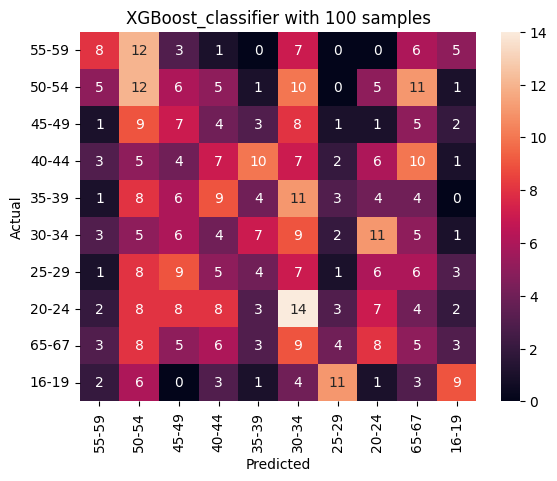

Total runtime for model fitting: 0.5964353084564209 seconds
not_imbalanced_diagnoses_XGBoost_classifier with trainingset size 1000, Accuracy: 0.272
Mean accuracy: 0.2265, Standard deviation: 0.024904818810824545
Macro f1-score: 0.2823862022573966, Macro recall-score: 0.28571975875818884


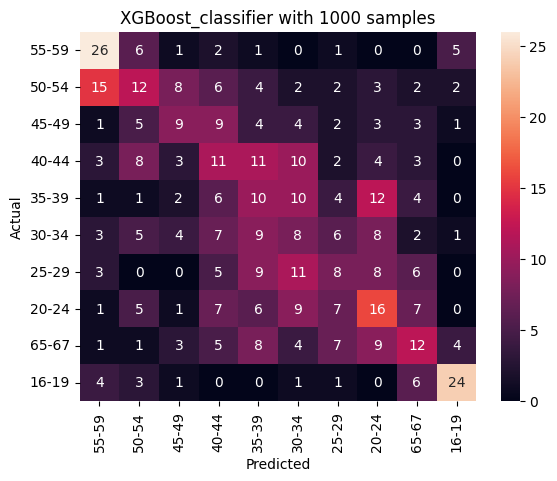

Total runtime for model fitting: 0.6628420352935791 seconds
not_imbalanced_diagnoses_XGBoost_classifier with trainingset size 2000, Accuracy: 0.24
Mean accuracy: 0.2475, Standard deviation: 0.014705441169852746
Macro f1-score: 0.2542557596669029, Macro recall-score: 0.25499144224370224


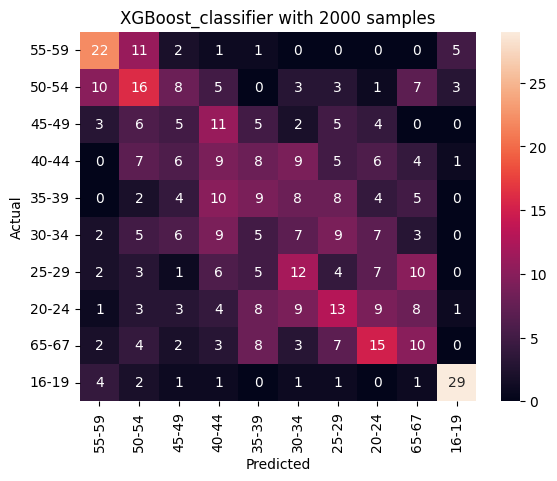

Total runtime for model fitting: 0.8611006736755371 seconds
not_imbalanced_diagnoses_XGBoost_classifier with trainingset size 5000, Accuracy: 0.304
Mean accuracy: 0.2811, Standard deviation: 0.014652303573158715
Macro f1-score: 0.3143629630063951, Macro recall-score: 0.3191437566678193


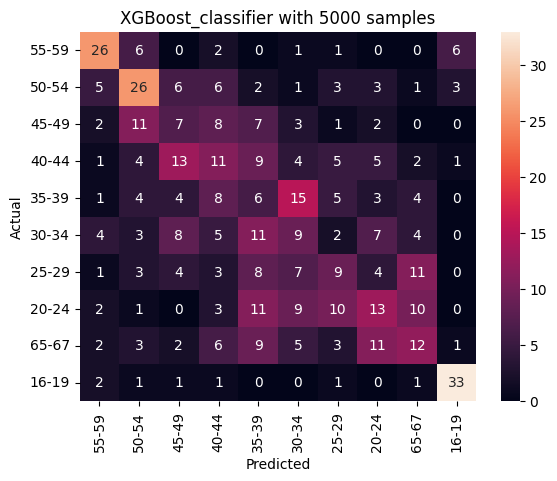

In [37]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [GBDT_clf_FI_diagnoses_train], GBDT_clf_FI_diagnoses_test, [xgb_classifier], classes_of_interest8, ["not_imbalanced_diagnoses"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.8874156475067139 seconds
imbalanced_diagnoses_XGBoost_classifier with trainingset size 100, Accuracy: 0.412
Mean accuracy: 0.43, Standard deviation: 0.10295630140987001
Macro f1-score: 0.3008801397229995, Macro recall-score: 0.3073349904704337


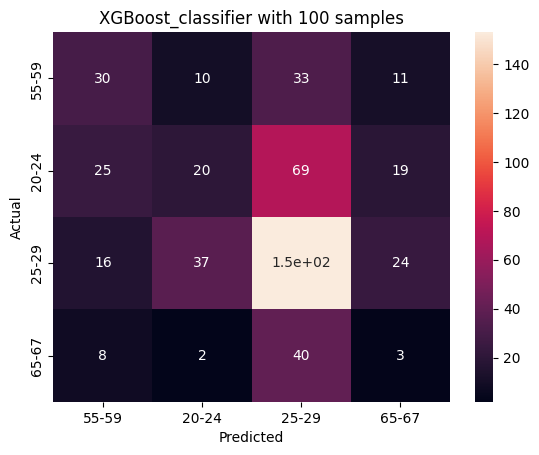

Total runtime for model fitting: 1.4804785251617432 seconds
imbalanced_diagnoses_XGBoost_classifier with trainingset size 1000, Accuracy: 0.506
Mean accuracy: 0.45949999999999996, Standard deviation: 0.028761954036539316
Macro f1-score: 0.4001516299557915, Macro recall-score: 0.4032664721689375


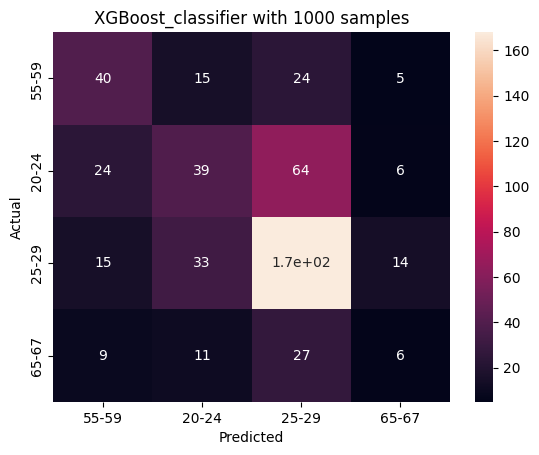

Total runtime for model fitting: 1.7565603256225586 seconds
imbalanced_diagnoses_XGBoost_classifier with trainingset size 2000, Accuracy: 0.512
Mean accuracy: 0.47975, Standard deviation: 0.01911968880499888
Macro f1-score: 0.4031292273414498, Macro recall-score: 0.4068310902358439


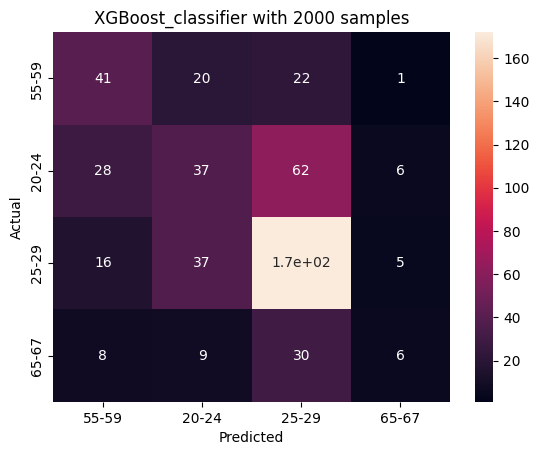

Total runtime for model fitting: 2.7009663581848145 seconds
imbalanced_diagnoses_XGBoost_classifier with trainingset size 5000, Accuracy: 0.548
Mean accuracy: 0.5185000000000001, Standard deviation: 0.012862736878285286
Macro f1-score: 0.4199113753911651, Macro recall-score: 0.4246623788758196


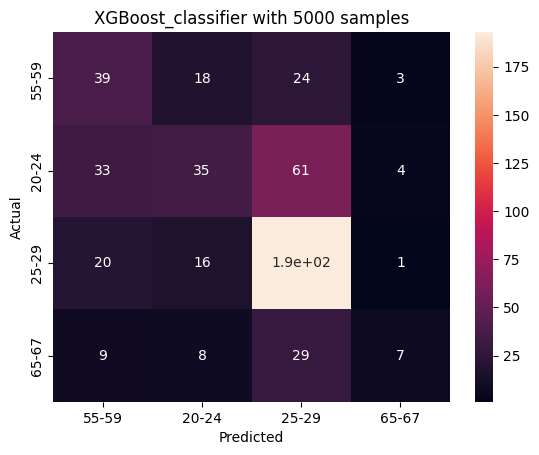

In [38]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [GBDT_imbalanced_diagnoses_train], GBDT_imbalanced_diagnoses_test, [xgb_classifier], classes_of_interest5, ["imbalanced_diagnoses"], ["XGBoost_classifier"], rskf, False, False)

#### CatBoost classifier

In [39]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [GBDT_clf_FI_diagnoses_train], GBDT_clf_FI_diagnoses_test, [cb_classifier], classes_of_interest1, ["FI_diagnoses"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 1.928349494934082 seconds
FI_diagnoses_CatBoost_classifier with trainingset size 100, Accuracy: 0.154
Mean accuracy: 0.09, Standard deviation: 0.03741657386773941
Total runtime for model fitting: 4.76872992515564 seconds
FI_diagnoses_CatBoost_classifier with trainingset size 1000, Accuracy: 0.236
Mean accuracy: 0.2225, Standard deviation: 0.017499999999999998
Total runtime for model fitting: 5.221694231033325 seconds
FI_diagnoses_CatBoost_classifier with trainingset size 2000, Accuracy: 0.244
Mean accuracy: 0.25475, Standard deviation: 0.014766939425622374
Total runtime for model fitting: 7.582463502883911 seconds
FI_diagnoses_CatBoost_classifier with trainingset size 5000, Accuracy: 0.302
Mean accuracy: 0.2842, Standard deviation: 0.010824047302187835


In [40]:
clf_model_comparison([100, 1000, 2000, 5000], "age_group", [GBDT_clf_EN_diagnoses_train], GBDT_clf_EN_diagnoses_test, [cb_classifier], classes_of_interest1, ["EN_diagnoses"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 1.7537424564361572 seconds
EN_diagnoses_CatBoost_classifier with trainingset size 100, Accuracy: 0.16
Mean accuracy: 0.095, Standard deviation: 0.034999999999999996
Total runtime for model fitting: 4.518387317657471 seconds
EN_diagnoses_CatBoost_classifier with trainingset size 1000, Accuracy: 0.242
Mean accuracy: 0.2205, Standard deviation: 0.017095320997278757
Total runtime for model fitting: 5.18650484085083 seconds
EN_diagnoses_CatBoost_classifier with trainingset size 2000, Accuracy: 0.256
Mean accuracy: 0.25349999999999995, Standard deviation: 0.016286497474902337
Total runtime for model fitting: 7.59662652015686 seconds
EN_diagnoses_CatBoost_classifier with trainingset size 5000, Accuracy: 0.29
Mean accuracy: 0.2835, Standard deviation: 0.015048255712872499


Total runtime for model fitting: 1.774914264678955 seconds
not_imbalanced_diagnoses_CatBoost_classifier with trainingset size 100, Accuracy: 0.154
Mean accuracy: 0.09, Standard deviation: 0.03741657386773941
Macro f1-score: 0.15279178507314717, Macro recall-score: 0.15689608962820256


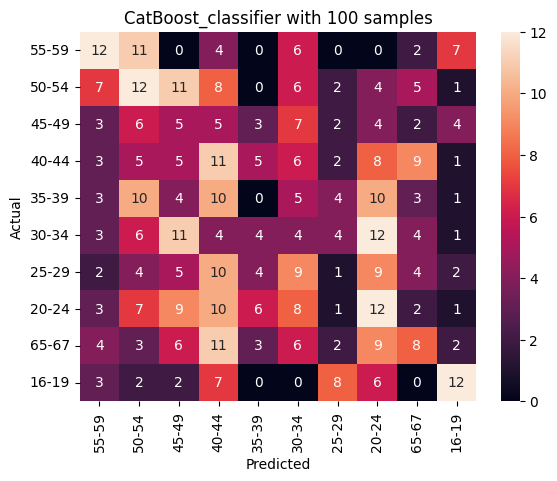

Total runtime for model fitting: 4.733606815338135 seconds
not_imbalanced_diagnoses_CatBoost_classifier with trainingset size 1000, Accuracy: 0.236
Mean accuracy: 0.2225, Standard deviation: 0.017499999999999998
Macro f1-score: 0.2438898825380198, Macro recall-score: 0.25412216804434073


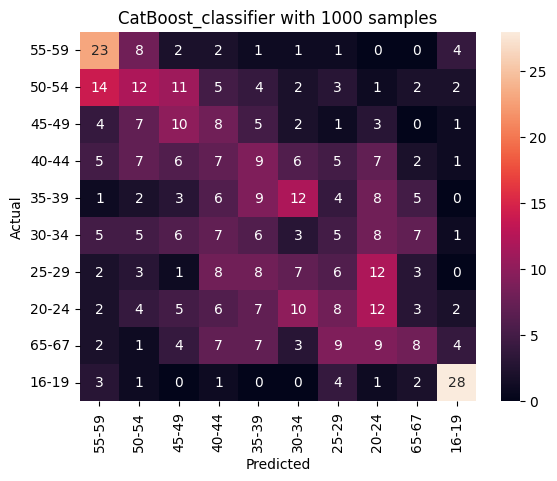

Total runtime for model fitting: 5.200616836547852 seconds
not_imbalanced_diagnoses_CatBoost_classifier with trainingset size 2000, Accuracy: 0.244
Mean accuracy: 0.25475, Standard deviation: 0.014766939425622374
Macro f1-score: 0.25427833484118745, Macro recall-score: 0.26255899952230105


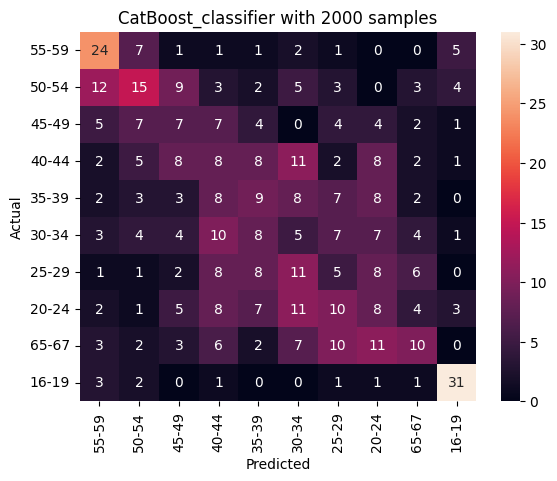

Total runtime for model fitting: 7.789998769760132 seconds
not_imbalanced_diagnoses_CatBoost_classifier with trainingset size 5000, Accuracy: 0.302
Mean accuracy: 0.2842, Standard deviation: 0.010824047302187835
Macro f1-score: 0.30736303051414254, Macro recall-score: 0.31969042079777843


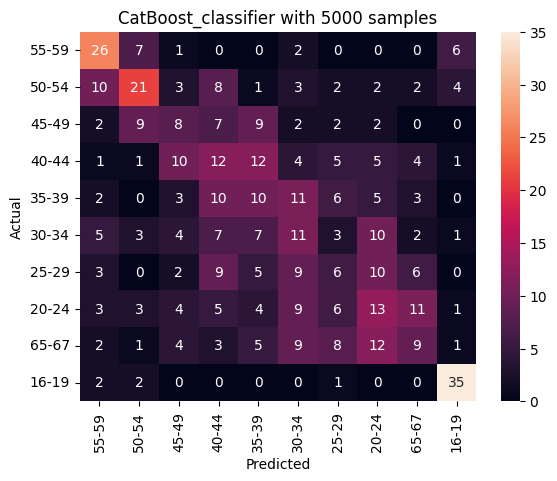

In [41]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [GBDT_clf_FI_diagnoses_train], GBDT_clf_FI_diagnoses_test, [cb_classifier], classes_of_interest8, ["not_imbalanced_diagnoses"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 1.177964448928833 seconds
imbalanced_diagnoses_CatBoost_classifier with trainingset size 100, Accuracy: 0.474
Mean accuracy: 0.53, Standard deviation: 0.09797958971132711
Macro f1-score: 0.27745934199903, Macro recall-score: 0.324865177710478


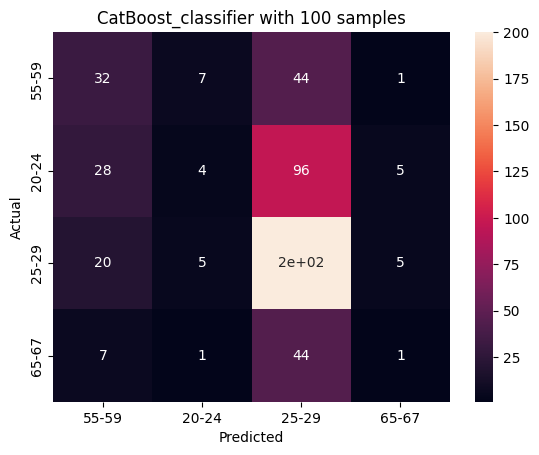

Total runtime for model fitting: 4.956880331039429 seconds
imbalanced_diagnoses_CatBoost_classifier with trainingset size 1000, Accuracy: 0.53
Mean accuracy: 0.501, Standard deviation: 0.02596150997149435
Macro f1-score: 0.40347009406760564, Macro recall-score: 0.41468080064805163


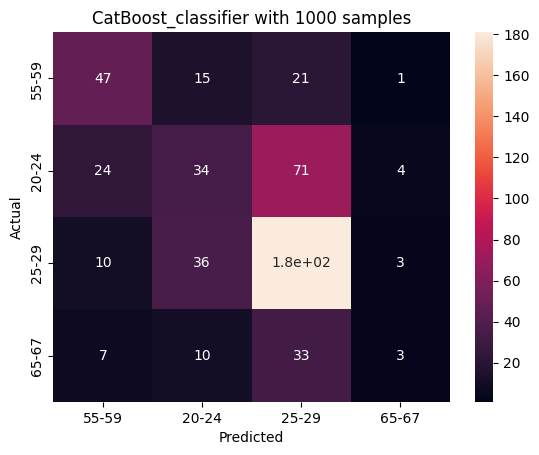

Total runtime for model fitting: 7.292909145355225 seconds
imbalanced_diagnoses_CatBoost_classifier with trainingset size 2000, Accuracy: 0.522
Mean accuracy: 0.5085, Standard deviation: 0.017471405209656156
Macro f1-score: 0.38688978301324684, Macro recall-score: 0.40387252997135986


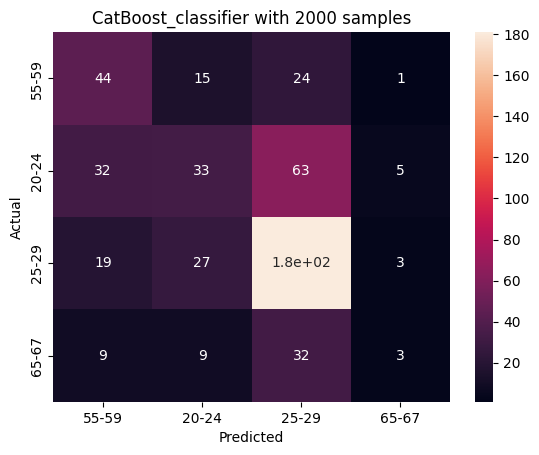

Total runtime for model fitting: 9.89091682434082 seconds
imbalanced_diagnoses_CatBoost_classifier with trainingset size 5000, Accuracy: 0.538
Mean accuracy: 0.5127, Standard deviation: 0.005254521862167865
Macro f1-score: 0.4000752871168331, Macro recall-score: 0.4165019552572983


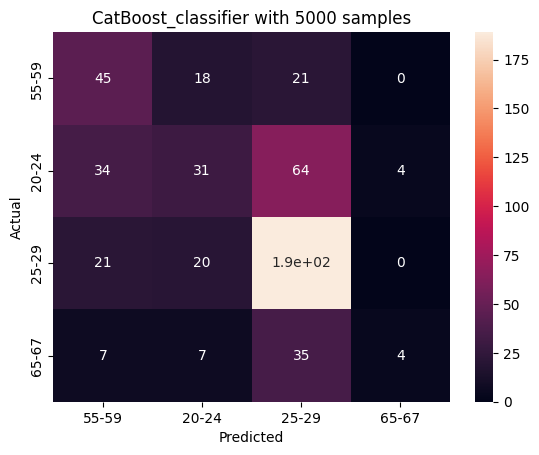

In [42]:
clf_model_comparison([100, 1000, 2000, 5000], "ikaryhma", [GBDT_imbalanced_diagnoses_train], GBDT_imbalanced_diagnoses_test, [cb_classifier], classes_of_interest5, ["imbalanced_diagnoses"], ["CatBoost_classifier"], rskf, False, False)

### Diagnoses regression (trainingsets sizes 100, 1000, 2000 and 5000)

#### TabPFN regressor

In [45]:
reg_model_comparison([100, 1000, 2000, 5000], "ka_maksettu/paiva", [reg_FI_diagnoses_train], reg_FI_diagnoses_test, [TabPFN_regressor], ["FI_diagnoses"], ["TabPFN_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.4849504708066747, Standard deviation: 0.2844035502855647
Total runtime for model fitting: 0.23581719398498535 seconds
FI_diagnoses_TabPFN_regressor with training set of 100: R2-score: 0.5950243975613047, mean absolute error: 7.230131562042237, mean squared error: 113.95332983524222
Training set size: 1000, Mean R2 score: 0.6584017154714971, Standard deviation: 0.06373328705434675
Total runtime for model fitting: 0.3060746192932129 seconds
FI_diagnoses_TabPFN_regressor with training set of 1000: R2-score: 0.6957295221066329, mean absolute error: 5.70419412185669, mean squared error: 85.61659990803602
Training set size: 2000, Mean R2 score: 0.667905963100836, Standard deviation: 0.057994413117621116
Total runtime for model fitting: 0.3738090991973877 seconds
FI_diagnoses_TabPFN_regressor with training set of 2000: R2-score: 0.7157706633413505, mean absolute error: 5.453549056854249, mean squared error: 79.97735951023907
Training set size: 5000, Me

In [46]:
reg_model_comparison([100, 1000, 2000, 5000], "average_amount_paid/day", [reg_EN_diagnoses_train], reg_EN_diagnoses_test, [TabPFN_regressor], ["EN_diagnoses"], ["TabPFN_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.5023705413053097, Standard deviation: 0.28594375102394065
Total runtime for model fitting: 0.23740482330322266 seconds
EN_diagnoses_TabPFN_regressor with training set of 100: R2-score: 0.6048355223833713, mean absolute error: 7.126163853149414, mean squared error: 111.19264416388022
Training set size: 1000, Mean R2 score: 0.6556801811585605, Standard deviation: 0.06707580984356472
Total runtime for model fitting: 0.3067176342010498 seconds
EN_diagnoses_TabPFN_regressor with training set of 1000: R2-score: 0.6922839903868861, mean absolute error: 5.755548444213868, mean squared error: 86.58611463967353
Training set size: 2000, Mean R2 score: 0.6697633510108669, Standard deviation: 0.058135121126934086
Total runtime for model fitting: 0.3731255531311035 seconds
EN_diagnoses_TabPFN_regressor with training set of 2000: R2-score: 0.7106740680467281, mean absolute error: 5.491199348144532, mean squared error: 81.41145578949032
Training set size: 5000,

#### TabICL regressor

In [47]:
reg_model_comparison([100, 1000, 2000, 5000], "ka_maksettu/paiva", [reg_FI_diagnoses_train], reg_FI_diagnoses_test, [TabICL_regressor], ["FI_diagnoses"], ["TabICL_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.5086391830005418, Standard deviation: 0.2717366637580642
Total runtime for model fitting: 0.47084593772888184 seconds
FI_diagnoses_TabICL_regressor with training set of 100: R2-score: 0.45032980090786323, mean absolute error: 8.233578417358398, mean squared error: 154.66795807095906
Training set size: 1000, Mean R2 score: 0.662048589829097, Standard deviation: 0.06024247733146885
Total runtime for model fitting: 0.4848349094390869 seconds
FI_diagnoses_TabICL_regressor with training set of 1000: R2-score: 0.6933935357902161, mean absolute error: 5.70334416671753, mean squared error: 86.27390720655544
Training set size: 2000, Mean R2 score: 0.6643127820806081, Standard deviation: 0.057882084000213115
Total runtime for model fitting: 0.49460673332214355 seconds
FI_diagnoses_TabICL_regressor with training set of 2000: R2-score: 0.7141781336370939, mean absolute error: 5.404456420288087, mean squared error: 80.4254706101887
Training set size: 5000, M

In [48]:
reg_model_comparison([100, 1000, 2000, 5000], "average_amount_paid/day", [reg_EN_diagnoses_train], reg_EN_diagnoses_test, [TabICL_regressor], ["EN_diagnoses"], ["TabICL_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.5171682648578355, Standard deviation: 0.29213952321383524
Total runtime for model fitting: 0.49675822257995605 seconds
EN_diagnoses_TabICL_regressor with training set of 100: R2-score: 0.4337110691026268, mean absolute error: 8.422280742034912, mean squared error: 159.3441899610819
Training set size: 1000, Mean R2 score: 0.6602976202601936, Standard deviation: 0.05958705587454739
Total runtime for model fitting: 0.5148341655731201 seconds
EN_diagnoses_TabICL_regressor with training set of 1000: R2-score: 0.6919591408172974, mean absolute error: 5.698386842956543, mean squared error: 86.6775218502
Training set size: 2000, Mean R2 score: 0.6654081610992322, Standard deviation: 0.05772509710604775
Total runtime for model fitting: 0.520838737487793 seconds
EN_diagnoses_TabICL_regressor with training set of 2000: R2-score: 0.7120947715735793, mean absolute error: 5.406444019775391, mean squared error: 81.01169368871567
Training set size: 5000, Mean R

#### ConTextTab regressor

In [49]:
reg_model_comparison([100, 1000, 2000, 5000], "ka_maksettu/paiva", [reg_FI_diagnoses_train], reg_FI_diagnoses_test, [ConTextTab_regressor], ["FI_diagnoses"], ["ConTextTab_regressor"], k_folds)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 5000, Mean R2 score: 0.6712385254962243, Standard deviation: 0.028757286553926446
Total runtime for model fitting: 0.00040030479431152344 seconds
FI_diagnoses_ConTextTab_regressor with training set of 5000: R2-score: 0.7195734666124382, mean absolute error: 5.3459525, mean squared error: 78.9073145671875


In [50]:
reg_model_comparison([100, 1000, 2000, 5000], "average_amount_paid/day", [reg_EN_diagnoses_train], reg_EN_diagnoses_test, [ConTextTab_regressor], ["EN_diagnoses"], ["ConTextTab_regressor"], k_folds)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 5000, Mean R2 score: 0.6693144700723062, Standard deviation: 0.0306043115389329
Total runtime for model fitting: 0.0004153251647949219 seconds
EN_diagnoses_ConTextTab_regressor with training set of 5000: R2-score: 0.7229098652762787, mean absolute error: 5.302425, mean squared error: 77.96850804375


#### XGBoost regressor

##### Preprosessing needed for tree methods

In [40]:
categories = ["aikatyyppi", "sukupuoli", "etuus", "diagnoosi", "ikaryhma"]
int_vals = ["kuukausi_nro", "vuosi", "alkanut_kausi_lkm"]
float_vals = ["ka_paiva_lkm"]
GBDT_reg_FI_diagnoses = modify_df(FI_diagnoses, int_vals, float_vals, categories)

categories = ["time_category", "sex", "benefit_type", "diagnosis", "age_group"]
int_vals = ["month_number", "year", "benefit_periods_started"]
float_vals = ["average_number_of_days"]
GBDT_reg_EN_diagnoses = modify_df(EN_diagnoses, int_vals, float_vals, categories)

In [41]:
GBDT_reg_FI_diagnoses_test = GBDT_reg_FI_diagnoses.iloc[:500]
GBDT_reg_FI_diagnoses_train = GBDT_reg_FI_diagnoses.iloc[500:]

GBDT_reg_EN_diagnoses_test = GBDT_reg_EN_diagnoses.iloc[:500]
GBDT_reg_EN_diagnoses_train = GBDT_reg_EN_diagnoses.iloc[500:]

In [53]:
reg_model_comparison([100, 1000, 2000, 5000], "ka_maksettu/paiva", [GBDT_reg_FI_diagnoses_train], GBDT_reg_FI_diagnoses_test, [xgb_regressor], ["FI_diagnoses"], ["XGBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.2888479162662434, Standard deviation: 0.2656192617661757
Total runtime for model fitting: 0.08048105239868164 seconds
FI_diagnoses_XGBoost_regressor with training set of 100: R2-score: 0.23388675072691179, mean absolute error: 9.152443679046632, mean squared error: 215.57139556025697
Training set size: 1000, Mean R2 score: 0.5593756894246527, Standard deviation: 0.0722575514587836
Total runtime for model fitting: 0.11039233207702637 seconds
FI_diagnoses_XGBoost_regressor with training set of 1000: R2-score: 0.6302525878740912, mean absolute error: 6.448112272205353, mean squared error: 104.04070901058564
Training set size: 2000, Mean R2 score: 0.584853914902289, Standard deviation: 0.06030006635542358
Total runtime for model fitting: 0.11613750457763672 seconds
FI_diagnoses_XGBoost_regressor with training set of 2000: R2-score: 0.6473783141633657, mean absolute error: 6.145606935005188, mean squared error: 99.22181739154004
Training set size: 50

In [54]:
reg_model_comparison([100, 1000, 2000, 5000], "average_amount_paid/day", [GBDT_reg_EN_diagnoses_train], GBDT_reg_EN_diagnoses_test, [xgb_regressor], ["EN_diagnoses"], ["XGBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.2888479162662434, Standard deviation: 0.2656192617661757
Total runtime for model fitting: 0.06358575820922852 seconds
EN_diagnoses_XGBoost_regressor with training set of 100: R2-score: 0.23390028558477738, mean absolute error: 9.152388678741456, mean squared error: 215.56758707867598
Training set size: 1000, Mean R2 score: 0.5593756894246527, Standard deviation: 0.0722575514587836
Total runtime for model fitting: 0.09471344947814941 seconds
EN_diagnoses_XGBoost_regressor with training set of 1000: R2-score: 0.6302525878740912, mean absolute error: 6.448112272205353, mean squared error: 104.04070901058564
Training set size: 2000, Mean R2 score: 0.5848418742091155, Standard deviation: 0.060304537217487
Total runtime for model fitting: 0.10049867630004883 seconds
EN_diagnoses_XGBoost_regressor with training set of 2000: R2-score: 0.6473783141633657, mean absolute error: 6.145606935005188, mean squared error: 99.22181739154004
Training set size: 500

#### CatBoost regressor

In [55]:
reg_model_comparison([100, 1000, 2000, 5000], "ka_maksettu/paiva", [GBDT_reg_FI_diagnoses_train], GBDT_reg_FI_diagnoses_test, [cb_regressor], ["FI_diagnoses"], ["CatBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.2926258151874868, Standard deviation: 0.30844830444173005
Total runtime for model fitting: 0.6389315128326416 seconds
FI_diagnoses_CatBoost_regressor with training set of 100: R2-score: 0.3844922474107001, mean absolute error: 9.249838813242745, mean squared error: 173.1935393751892
Training set size: 1000, Mean R2 score: 0.6300316870140972, Standard deviation: 0.0523337220637664
Total runtime for model fitting: 1.0201244354248047 seconds
FI_diagnoses_CatBoost_regressor with training set of 1000: R2-score: 0.6574241110234762, mean absolute error: 6.199556488453094, mean squared error: 96.39509895180069
Training set size: 2000, Mean R2 score: 0.6128667671614222, Standard deviation: 0.05532535493870486
Total runtime for model fitting: 1.0337004661560059 seconds
FI_diagnoses_CatBoost_regressor with training set of 2000: R2-score: 0.6891236683242237, mean absolute error: 5.874825132710999, mean squared error: 87.47537616610508
Training set size: 500

In [56]:
reg_model_comparison([100, 1000, 2000, 5000], "average_amount_paid/day", [GBDT_reg_EN_diagnoses_train], GBDT_reg_EN_diagnoses_test, [cb_regressor], ["EN_diagnoses"], ["CatBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.3094260769360947, Standard deviation: 0.325775410299995
Total runtime for model fitting: 0.5446300506591797 seconds
EN_diagnoses_CatBoost_regressor with training set of 100: R2-score: 0.3681666088427431, mean absolute error: 9.226697192818644, mean squared error: 177.78729975310475
Training set size: 1000, Mean R2 score: 0.626919570155784, Standard deviation: 0.06066392882796814
Total runtime for model fitting: 0.922863245010376 seconds
EN_diagnoses_CatBoost_regressor with training set of 1000: R2-score: 0.6513498926486421, mean absolute error: 6.2503858356048525, mean squared error: 98.10428193909814
Training set size: 2000, Mean R2 score: 0.6214360008758989, Standard deviation: 0.0490441547035509
Total runtime for model fitting: 1.0332047939300537 seconds
EN_diagnoses_CatBoost_regressor with training set of 2000: R2-score: 0.6893045527228603, mean absolute error: 5.9113770017566845, mean squared error: 87.42447833567834
Training set size: 5000

## City Bikes

### City Bikes classification (trainingsets sizes 100, 1000, 2000 and 5000)

#### TabPFN classifier

In [57]:
clf_model_comparison([100, 1000, 2000, 5000], "Palautusaseman nimi", [clf_FI_Bikes_train], clf_FI_Bikes_test, [TabPFN_classifier], classes_of_interest2, ["FI_Bikes"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.24053645133972168 seconds
FI_Bikes_TabPFN_classifier with trainingset size 100, Accuracy: 0.884
Mean accuracy: 0.915, Standard deviation: 0.06726812023536853
Total runtime for model fitting: 0.2940545082092285 seconds
FI_Bikes_TabPFN_classifier with trainingset size 1000, Accuracy: 0.94
Mean accuracy: 0.9440000000000002, Standard deviation: 0.01337908816025962
Total runtime for model fitting: 0.35590434074401855 seconds
FI_Bikes_TabPFN_classifier with trainingset size 2000, Accuracy: 0.946
Mean accuracy: 0.9450000000000001, Standard deviation: 0.009617692030835652
Total runtime for model fitting: 0.5602266788482666 seconds
FI_Bikes_TabPFN_classifier with trainingset size 5000, Accuracy: 0.944
Mean accuracy: 0.9441999999999998, Standard deviation: 0.005114684741017758


In [58]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_EN_Bikes_train], clf_EN_Bikes_test, [TabPFN_classifier], classes_of_interest2, ["EN_Bikes"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.24341630935668945 seconds
EN_Bikes_TabPFN_classifier with trainingset size 100, Accuracy: 0.884
Mean accuracy: 0.89, Standard deviation: 0.053851648071345015
Total runtime for model fitting: 0.303372859954834 seconds
EN_Bikes_TabPFN_classifier with trainingset size 1000, Accuracy: 0.954
Mean accuracy: 0.9259999999999999, Standard deviation: 0.017999999999999967
Total runtime for model fitting: 0.3618288040161133 seconds
EN_Bikes_TabPFN_classifier with trainingset size 2000, Accuracy: 0.952
Mean accuracy: 0.9295, Standard deviation: 0.008426149773176357
Total runtime for model fitting: 0.5373682975769043 seconds
EN_Bikes_TabPFN_classifier with trainingset size 5000, Accuracy: 0.956
Mean accuracy: 0.9428999999999998, Standard deviation: 0.006564297372910506


Total runtime for model fitting: 0.24206900596618652 seconds
not_imbalanced_bikes_TabPFN_classifier with trainingset size 100, Accuracy: 0.884
Mean accuracy: 0.89, Standard deviation: 0.053851648071345015
Macro f1-score: 0.8364447768544809, Macro recall-score: 0.8142083067479631


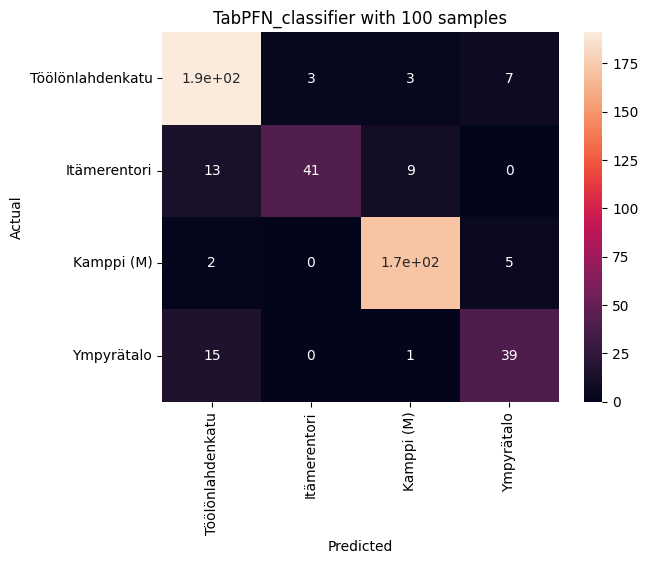

Total runtime for model fitting: 0.2996084690093994 seconds
not_imbalanced_bikes_TabPFN_classifier with trainingset size 1000, Accuracy: 0.954
Mean accuracy: 0.9259999999999999, Standard deviation: 0.017999999999999967
Macro f1-score: 0.938554375013541, Macro recall-score: 0.929772825030591


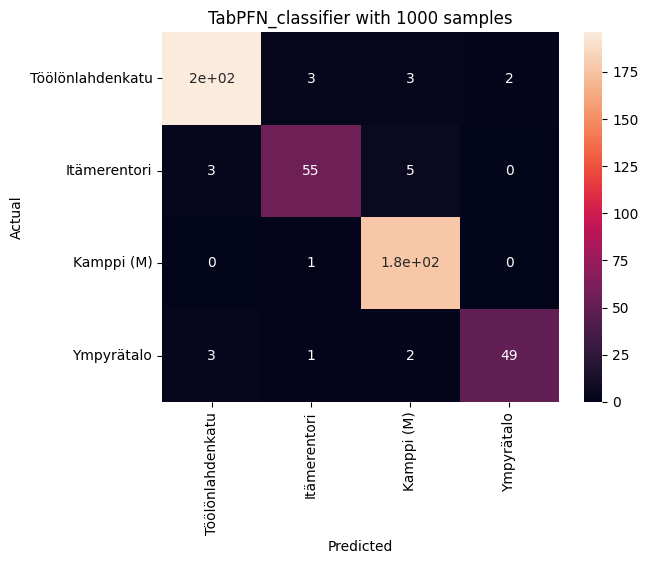

Total runtime for model fitting: 0.3564584255218506 seconds
not_imbalanced_bikes_TabPFN_classifier with trainingset size 2000, Accuracy: 0.952
Mean accuracy: 0.9295, Standard deviation: 0.008426149773176357
Macro f1-score: 0.9354351132641907, Macro recall-score: 0.927612125885424


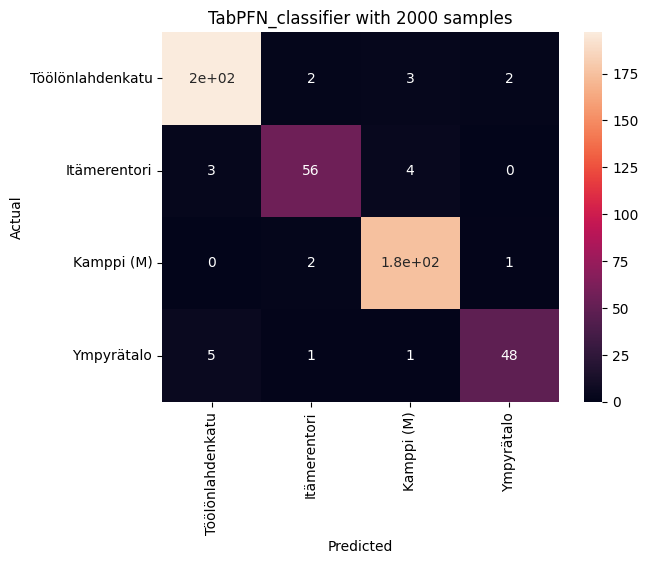

Total runtime for model fitting: 0.5334105491638184 seconds
not_imbalanced_bikes_TabPFN_classifier with trainingset size 5000, Accuracy: 0.956
Mean accuracy: 0.9428999999999998, Standard deviation: 0.006564297372910506
Macro f1-score: 0.942766948122474, Macro recall-score: 0.939047602357252


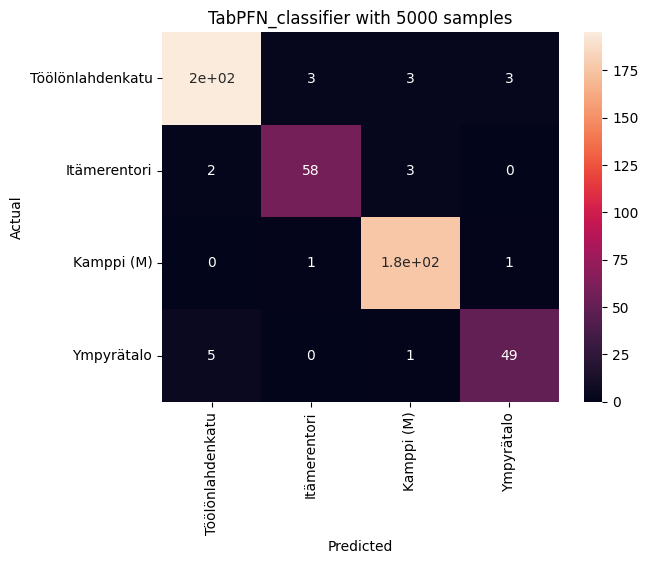

In [59]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_EN_Bikes_train], clf_EN_Bikes_test, [TabPFN_classifier], classes_of_interest2, ["not_imbalanced_bikes"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.2369074821472168 seconds
imbalanced_bikes_TabPFN_classifier with trainingset size 100, Accuracy: 0.522
Mean accuracy: 0.37499999999999994, Standard deviation: 0.1436140661634507
Macro f1-score: 0.5298674275499071, Macro recall-score: 0.5240926164904369


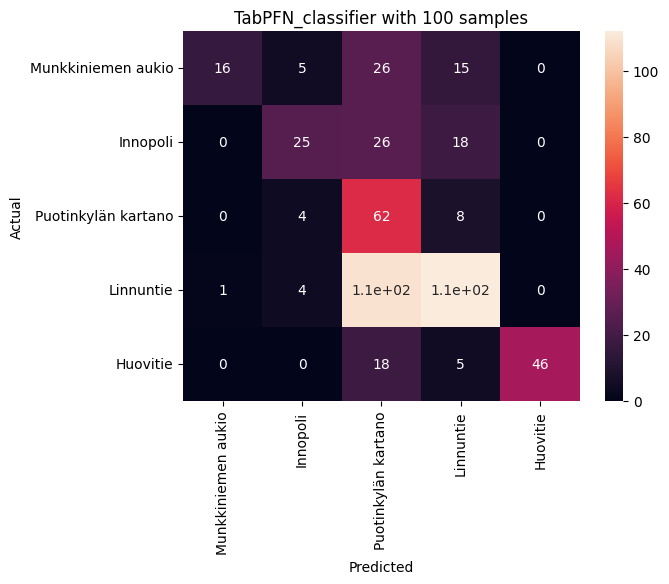

Total runtime for model fitting: 0.30184435844421387 seconds
imbalanced_bikes_TabPFN_classifier with trainingset size 1000, Accuracy: 0.87
Mean accuracy: 0.8720000000000001, Standard deviation: 0.02767670500619612
Macro f1-score: 0.8579340023281287, Macro recall-score: 0.8394997561823512


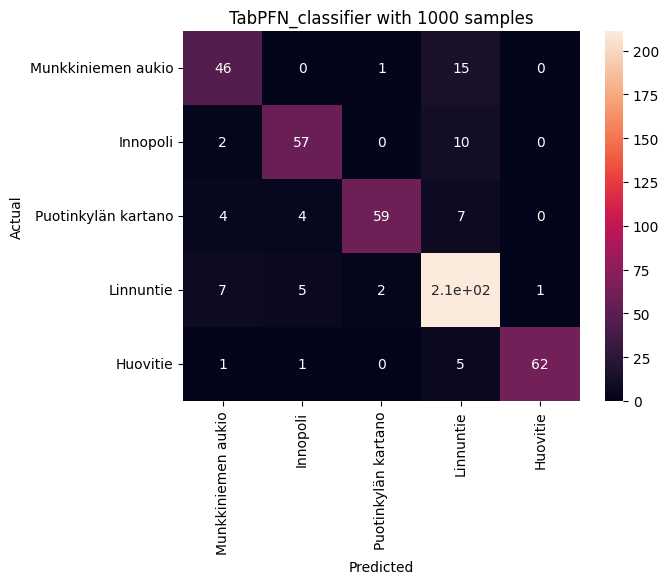

Total runtime for model fitting: 0.36010146141052246 seconds
imbalanced_bikes_TabPFN_classifier with trainingset size 2000, Accuracy: 0.892
Mean accuracy: 0.89275, Standard deviation: 0.014467636296230282
Macro f1-score: 0.8850179735744709, Macro recall-score: 0.8676194396185956


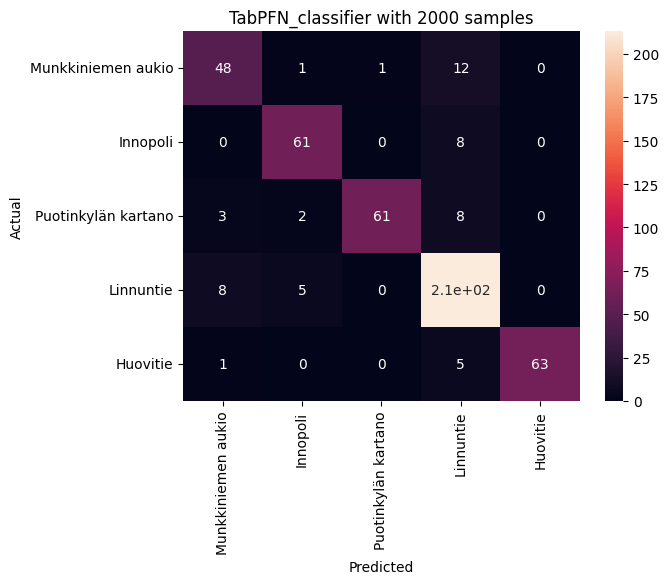

Total runtime for model fitting: 0.535374641418457 seconds
imbalanced_bikes_TabPFN_classifier with trainingset size 5000, Accuracy: 0.918
Mean accuracy: 0.9212, Standard deviation: 0.0044676615807377395
Macro f1-score: 0.9121854530209937, Macro recall-score: 0.9065451816298916


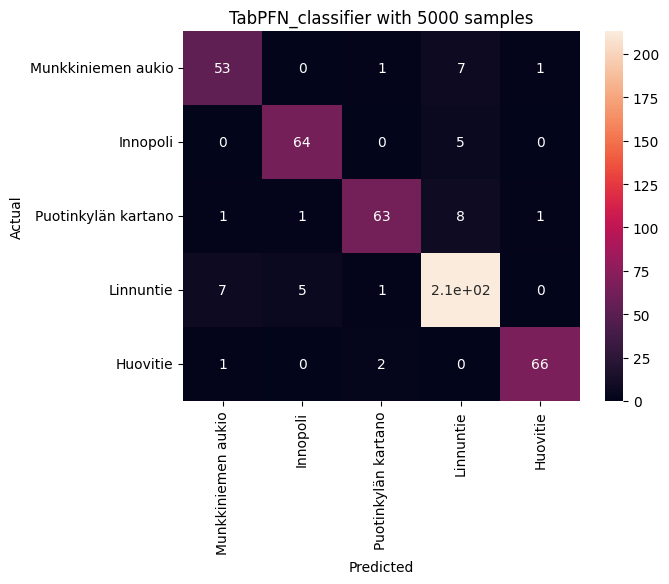

In [60]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_imbalanced_bikes_train], clf_imbalanced_bikes_test, [TabPFN_classifier], classes_of_interest6, ["imbalanced_bikes"], ["TabPFN_classifier"], rskf, False, False)

#### TabICL classifier

In [61]:
clf_model_comparison([100, 1000, 2000, 5000], "Palautusaseman nimi", [clf_FI_Bikes_train], clf_FI_Bikes_test, [TabICL_classifier], classes_of_interest2, ["FI_Bikes"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.4927966594696045 seconds
FI_Bikes_TabICL_classifier with trainingset size 100, Accuracy: 0.828
Mean accuracy: 0.785, Standard deviation: 0.07088723439378913
Total runtime for model fitting: 0.5093550682067871 seconds
FI_Bikes_TabICL_classifier with trainingset size 1000, Accuracy: 0.944
Mean accuracy: 0.9490000000000001, Standard deviation: 0.013747727084867493
Total runtime for model fitting: 0.5224096775054932 seconds
FI_Bikes_TabICL_classifier with trainingset size 2000, Accuracy: 0.944
Mean accuracy: 0.9477500000000001, Standard deviation: 0.0074540257579377624
Total runtime for model fitting: 0.5707755088806152 seconds
FI_Bikes_TabICL_classifier with trainingset size 5000, Accuracy: 0.942
Mean accuracy: 0.9456, Standard deviation: 0.005499090833947013


In [62]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_EN_Bikes_train], clf_EN_Bikes_test, [TabICL_classifier], classes_of_interest2, ["EN_Bikes"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.5159533023834229 seconds
EN_Bikes_TabICL_classifier with trainingset size 100, Accuracy: 0.868
Mean accuracy: 0.86, Standard deviation: 0.07348469228349533
Total runtime for model fitting: 0.5112340450286865 seconds
EN_Bikes_TabICL_classifier with trainingset size 1000, Accuracy: 0.952
Mean accuracy: 0.9285, Standard deviation: 0.015660459763365803
Total runtime for model fitting: 0.5236899852752686 seconds
EN_Bikes_TabICL_classifier with trainingset size 2000, Accuracy: 0.95
Mean accuracy: 0.93225, Standard deviation: 0.006841966091701985
Total runtime for model fitting: 0.5746273994445801 seconds
EN_Bikes_TabICL_classifier with trainingset size 5000, Accuracy: 0.962
Mean accuracy: 0.9437000000000001, Standard deviation: 0.005797413216254287


Total runtime for model fitting: 0.49739861488342285 seconds
not_imbalanced_bikes_TabICL_classifier with trainingset size 100, Accuracy: 0.868
Mean accuracy: 0.86, Standard deviation: 0.07348469228349533
Macro f1-score: 0.8058332784631079, Macro recall-score: 0.7804757159929003


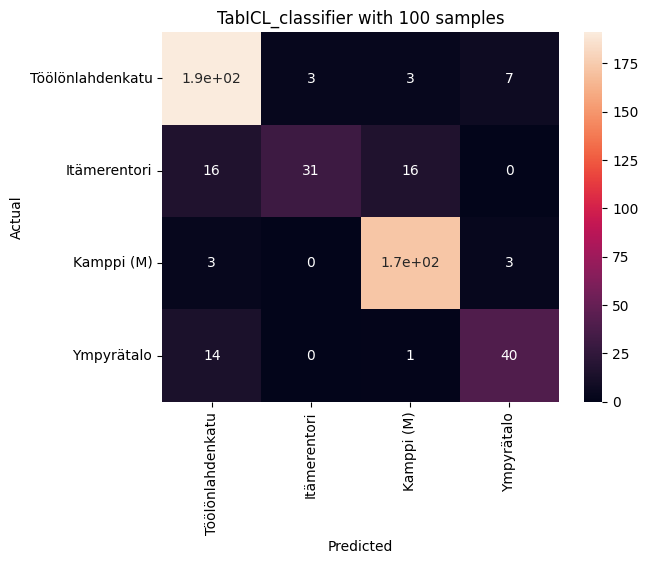

Total runtime for model fitting: 0.5090956687927246 seconds
not_imbalanced_bikes_TabICL_classifier with trainingset size 1000, Accuracy: 0.952
Mean accuracy: 0.9285, Standard deviation: 0.015660459763365803
Macro f1-score: 0.9386751369957401, Macro recall-score: 0.9281893264626246


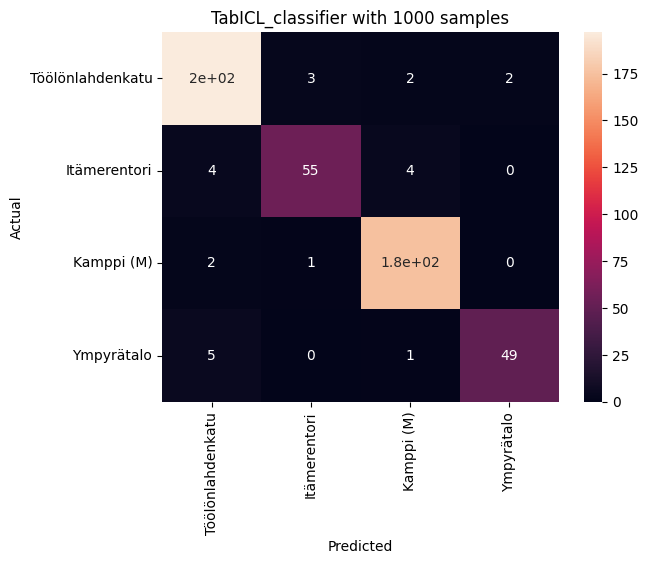

Total runtime for model fitting: 0.5206601619720459 seconds
not_imbalanced_bikes_TabICL_classifier with trainingset size 2000, Accuracy: 0.95
Mean accuracy: 0.93225, Standard deviation: 0.006841966091701985
Macro f1-score: 0.9340968961723104, Macro recall-score: 0.9350131233971286


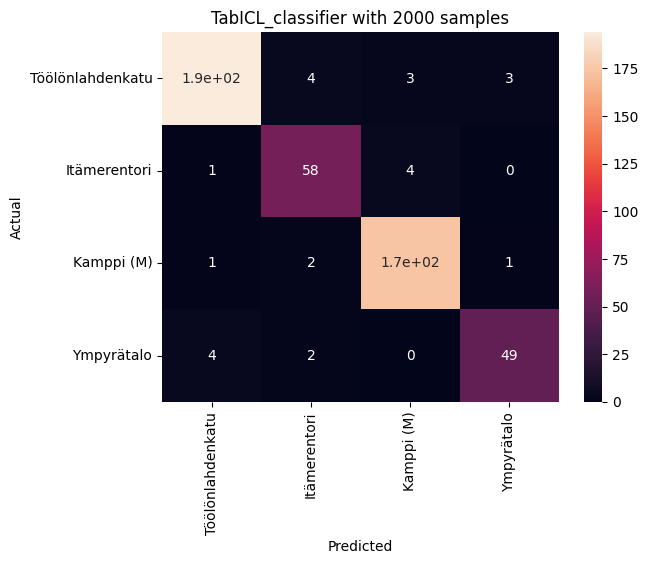

Total runtime for model fitting: 0.5754985809326172 seconds
not_imbalanced_bikes_TabICL_classifier with trainingset size 5000, Accuracy: 0.962
Mean accuracy: 0.9437000000000001, Standard deviation: 0.005797413216254287
Macro f1-score: 0.9478725686712579, Macro recall-score: 0.9515295648392146


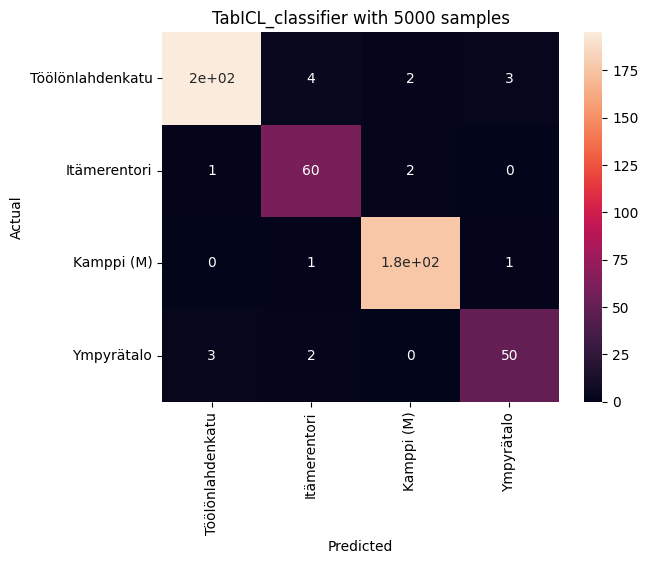

In [63]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_EN_Bikes_train], clf_EN_Bikes_test, [TabICL_classifier], classes_of_interest2, ["not_imbalanced_bikes"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.49295544624328613 seconds
imbalanced_bikes_TabICL_classifier with trainingset size 100, Accuracy: 0.528
Mean accuracy: 0.4, Standard deviation: 0.13228756555322954
Macro f1-score: 0.5222696161979961, Macro recall-score: 0.5337242466560194


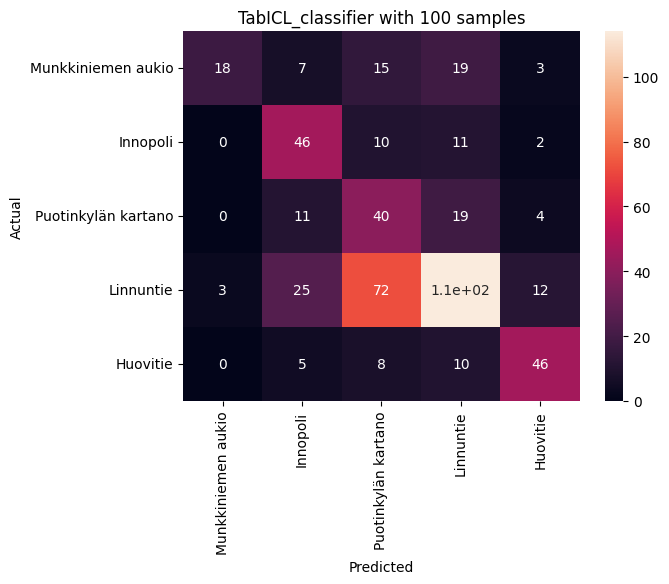

Total runtime for model fitting: 0.5126361846923828 seconds
imbalanced_bikes_TabICL_classifier with trainingset size 1000, Accuracy: 0.926
Mean accuracy: 0.9075, Standard deviation: 0.02052437575177379
Macro f1-score: 0.9184999311797588, Macro recall-score: 0.9033897082675149


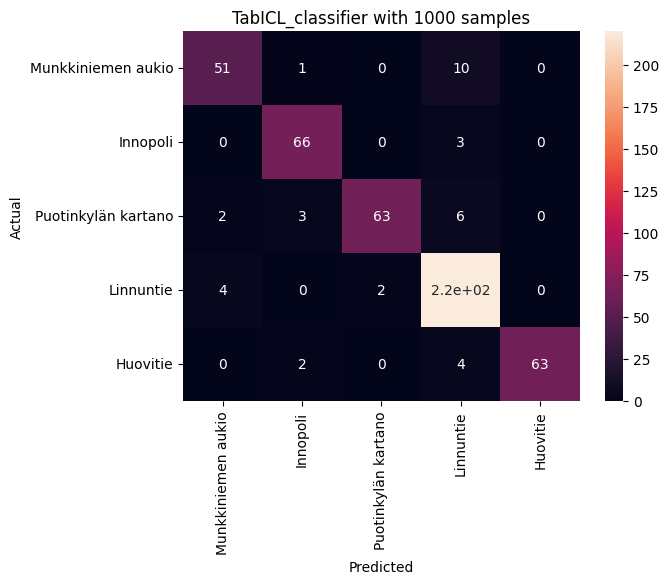

Total runtime for model fitting: 0.5312333106994629 seconds
imbalanced_bikes_TabICL_classifier with trainingset size 2000, Accuracy: 0.926
Mean accuracy: 0.93, Standard deviation: 0.014790199457749039
Macro f1-score: 0.9200351691406649, Macro recall-score: 0.9157340935121472


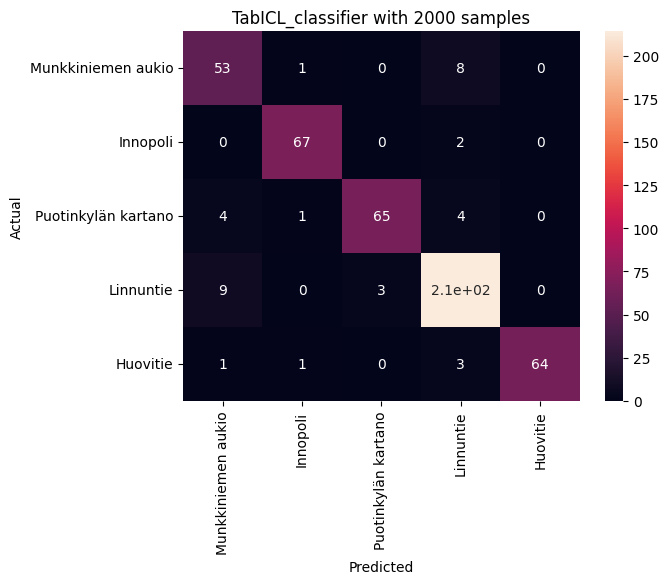

Total runtime for model fitting: 0.5777177810668945 seconds
imbalanced_bikes_TabICL_classifier with trainingset size 5000, Accuracy: 0.956
Mean accuracy: 0.9541999999999998, Standard deviation: 0.0055461698495448235
Macro f1-score: 0.9540637012604065, Macro recall-score: 0.9480481114111914


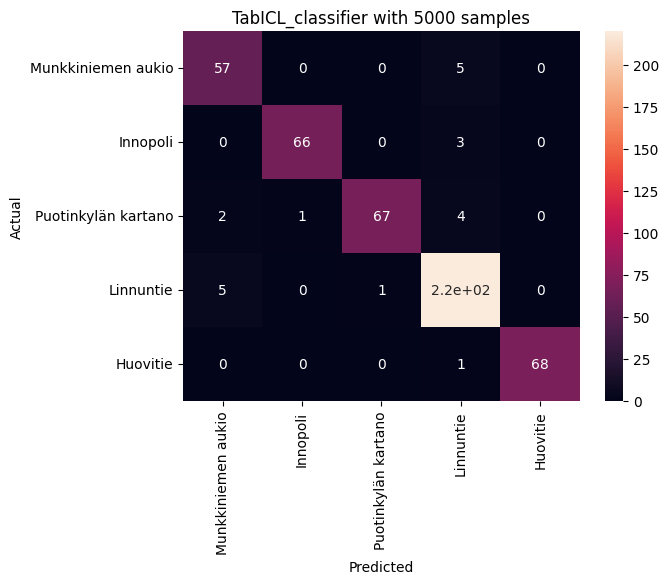

In [64]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_imbalanced_bikes_train], clf_imbalanced_bikes_test, [TabICL_classifier], classes_of_interest6, ["imbalanced_bikes"], ["TabICL_classifier"], rskf, False, False)

#### ConTextTab classifier

In [65]:
clf_model_comparison([100, 1000, 2000, 5000], "Palautusaseman nimi", [clf_FI_Bikes_train], clf_FI_Bikes_test, [ConTextTab_classifier], classes_of_interest2, ["FI_Bikes"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.005248308181762695 seconds
FI_Bikes_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.942
Mean accuracy: 0.9439, Standard deviation: 0.005889821729050852


In [66]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_EN_Bikes_train], clf_EN_Bikes_test, [ConTextTab_classifier], classes_of_interest2, ["EN_Bikes"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.004643678665161133 seconds
EN_Bikes_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.95
Mean accuracy: 0.9427999999999999, Standard deviation: 0.005153639490690038


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0005013942718505859 seconds
not_imbalanced_bikes_ConTextTab_classifier with trainingset size 100, Accuracy: 0.886
Mean accuracy: 0.9, Standard deviation: 0.05477225575051658
Macro f1-score: 0.841239234654297, Macro recall-score: 0.8189327654793617


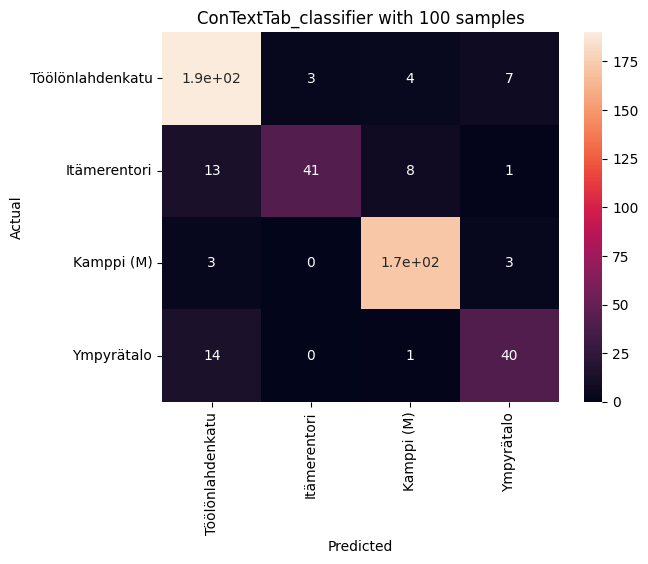

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.001173257827758789 seconds
not_imbalanced_bikes_ConTextTab_classifier with trainingset size 1000, Accuracy: 0.95
Mean accuracy: 0.9259999999999999, Standard deviation: 0.016852299546352683
Macro f1-score: 0.9322764631070638, Macro recall-score: 0.925809435112145


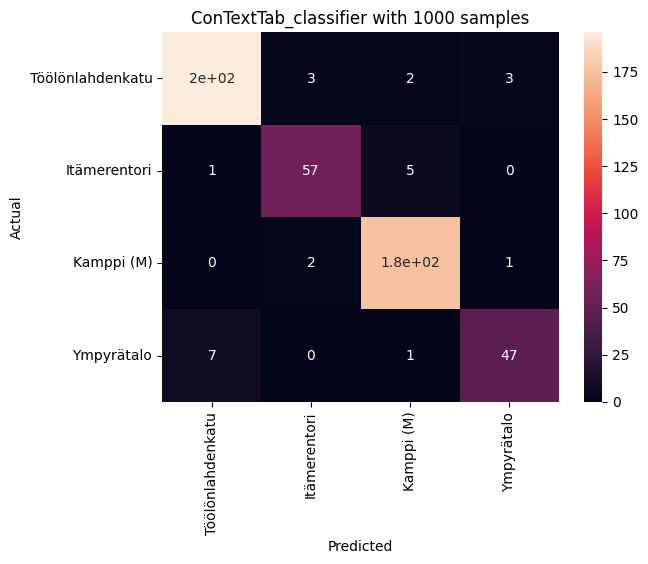

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0018537044525146484 seconds
not_imbalanced_bikes_ConTextTab_classifier with trainingset size 2000, Accuracy: 0.952
Mean accuracy: 0.9305, Standard deviation: 0.006782329983125269
Macro f1-score: 0.9341231440863611, Macro recall-score: 0.9360596094072631


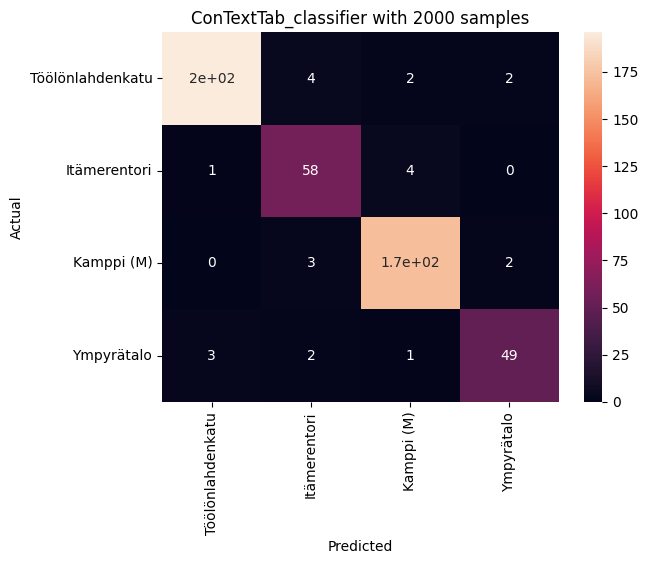

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0044291019439697266 seconds
not_imbalanced_bikes_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.95
Mean accuracy: 0.9427999999999999, Standard deviation: 0.005153639490690038
Macro f1-score: 0.9310352602834189, Macro recall-score: 0.9326283679968412


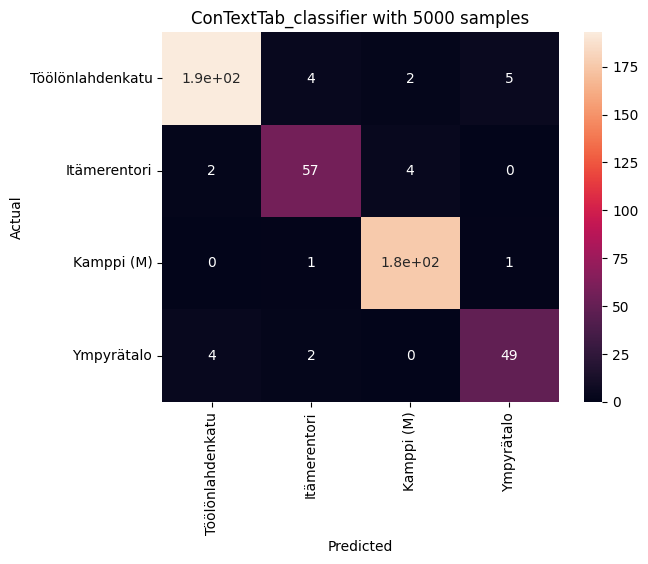

In [67]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_EN_Bikes_train], clf_EN_Bikes_test, [ConTextTab_classifier], classes_of_interest2, ["not_imbalanced_bikes"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0005078315734863281 seconds
imbalanced_bikes_ConTextTab_classifier with trainingset size 100, Accuracy: 0.706
Mean accuracy: 0.59, Standard deviation: 0.07999999999999999
Macro f1-score: 0.6596666496723717, Macro recall-score: 0.603083697829816


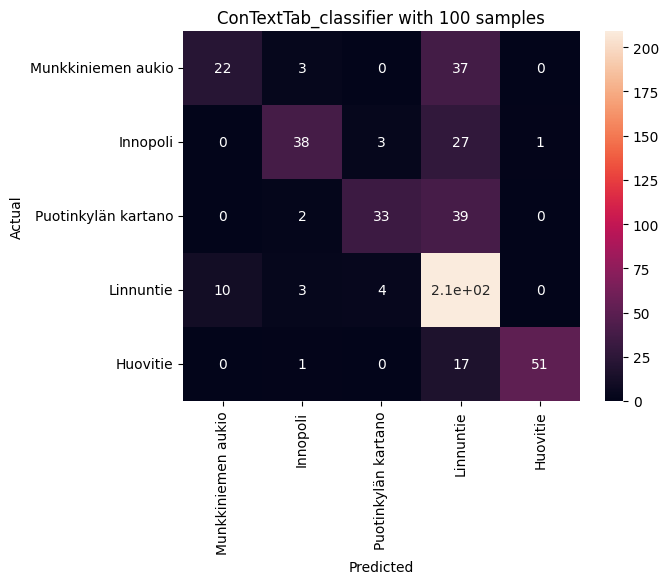

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0009691715240478516 seconds
imbalanced_bikes_ConTextTab_classifier with trainingset size 1000, Accuracy: 0.9
Mean accuracy: 0.9005000000000001, Standard deviation: 0.02611991577321796
Macro f1-score: 0.8947710827748274, Macro recall-score: 0.8722580578070904


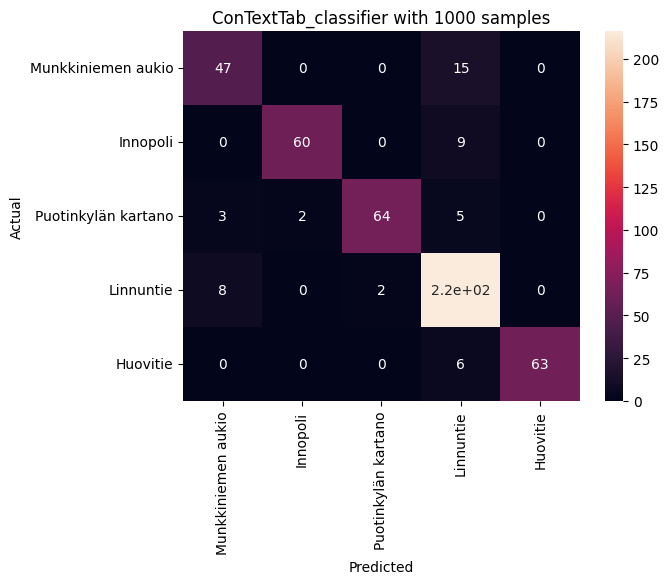

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0018763542175292969 seconds
imbalanced_bikes_ConTextTab_classifier with trainingset size 2000, Accuracy: 0.91
Mean accuracy: 0.9189999999999999, Standard deviation: 0.011247221879202006
Macro f1-score: 0.9046580671907524, Macro recall-score: 0.8872094748622942


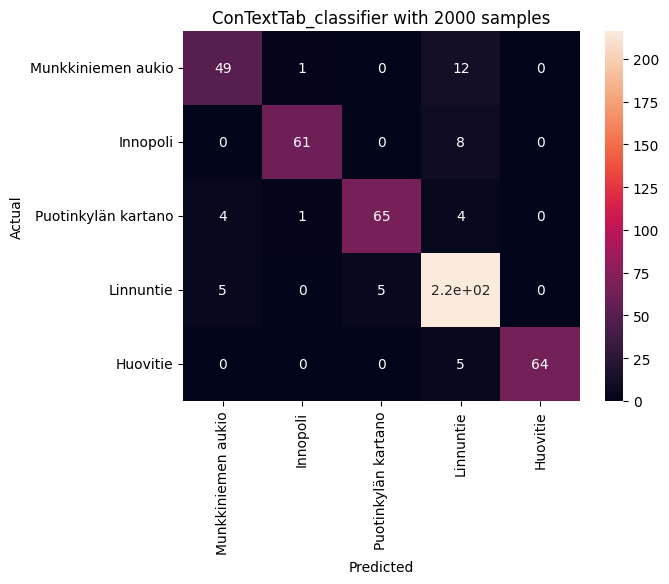

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.003881216049194336 seconds
imbalanced_bikes_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.932
Mean accuracy: 0.9529, Standard deviation: 0.007020683727387247
Macro f1-score: 0.9295982114490006, Macro recall-score: 0.9309291940353515


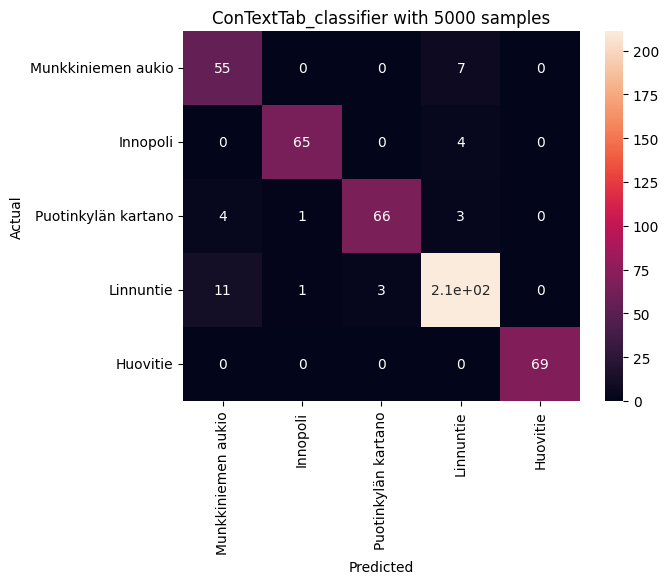

In [68]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [clf_imbalanced_bikes_train], clf_imbalanced_bikes_test, [ConTextTab_classifier], classes_of_interest6, ["imbalanced_bikes"], ["ConTextTab_classifier"], rskf, False, False)

#### XGBoost classifier

##### Preprosessing needed for tree methods

In [69]:
categories = ["Lähtöaseman nimi"]
int_vals = ["Kesto (sek.)", "Vuosi", "Kuukausi", "Lähtöpäivä", "Lähtö tunti", "Lähtö min.", "Lähtö sek.", "Palautuspäivä", "Palautustunti", "Palautus min.", "Palautus sek."]
float_vals = ["Kuljettu matka (m)"]
GBDT_clf_FI_Bikes = modify_df(clf_FI_Bikes, int_vals, float_vals, categories)

categories = ["Departure station name"]
int_vals = ["Duration (sec.)", "Year", "Month", "Departure day", "Departure hour", "Departure min.", "Departure sec.", "Return day", "Return hour", "Return min.", "Return sec."]
float_vals = ["Covered distance (m)"]
GBDT_clf_EN_Bikes = modify_df(clf_EN_Bikes, int_vals, float_vals, categories)
GBDT_imbalanced_bikes = modify_df(clf_imbalanced_bikes, int_vals, float_vals, categories)

In [70]:
GBDT_clf_FI_Bikes_test = GBDT_clf_FI_Bikes.iloc[:500]
GBDT_clf_FI_Bikes_train = GBDT_clf_FI_Bikes.iloc[500:]

GBDT_imbalanced_bikes_test = GBDT_imbalanced_bikes.iloc[:500]
GBDT_imbalanced_bikes_train = GBDT_imbalanced_bikes.iloc[500:]

GBDT_clf_EN_Bikes_test = GBDT_clf_EN_Bikes.iloc[:500]
GBDT_clf_EN_Bikes_train = GBDT_clf_EN_Bikes.iloc[500:]

In [71]:
clf_model_comparison([100, 1000, 2000, 5000], "Palautusaseman nimi", [GBDT_clf_FI_Bikes_train], GBDT_clf_FI_Bikes_test, [xgb_classifier], classes_of_interest2, ["FI_Bikes"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.08215761184692383 seconds
FI_Bikes_XGBoost_classifier with trainingset size 100, Accuracy: 0.682
Mean accuracy: 0.6749999999999999, Standard deviation: 0.10062305898749054
Total runtime for model fitting: 0.1952042579650879 seconds
FI_Bikes_XGBoost_classifier with trainingset size 1000, Accuracy: 0.918
Mean accuracy: 0.913, Standard deviation: 0.0207605394920267
Total runtime for model fitting: 0.2587747573852539 seconds
FI_Bikes_XGBoost_classifier with trainingset size 2000, Accuracy: 0.954
Mean accuracy: 0.92775, Standard deviation: 0.008620469824783317
Total runtime for model fitting: 0.3534090518951416 seconds
FI_Bikes_XGBoost_classifier with trainingset size 5000, Accuracy: 0.942
Mean accuracy: 0.9359, Standard deviation: 0.005374941860150633


In [72]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [GBDT_clf_EN_Bikes_train], GBDT_clf_EN_Bikes_test, [xgb_classifier], classes_of_interest2, ["EN_Bikes"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.07431292533874512 seconds
EN_Bikes_XGBoost_classifier with trainingset size 100, Accuracy: 0.764
Mean accuracy: 0.7749999999999999, Standard deviation: 0.08440971508067065
Total runtime for model fitting: 0.1931135654449463 seconds
EN_Bikes_XGBoost_classifier with trainingset size 1000, Accuracy: 0.908
Mean accuracy: 0.9055, Standard deviation: 0.02573421846491555
Total runtime for model fitting: 0.2583885192871094 seconds
EN_Bikes_XGBoost_classifier with trainingset size 2000, Accuracy: 0.928
Mean accuracy: 0.9145, Standard deviation: 0.009273618495495704
Total runtime for model fitting: 0.34655141830444336 seconds
EN_Bikes_XGBoost_classifier with trainingset size 5000, Accuracy: 0.942
Mean accuracy: 0.9337000000000002, Standard deviation: 0.007733692520394092


Total runtime for model fitting: 0.07471394538879395 seconds
not_imbalanced_bikes_XGBoost_classifier with trainingset size 100, Accuracy: 0.764
Mean accuracy: 0.7749999999999999, Standard deviation: 0.08440971508067065
Macro f1-score: 0.6599582973828012, Macro recall-score: 0.6326859378412583


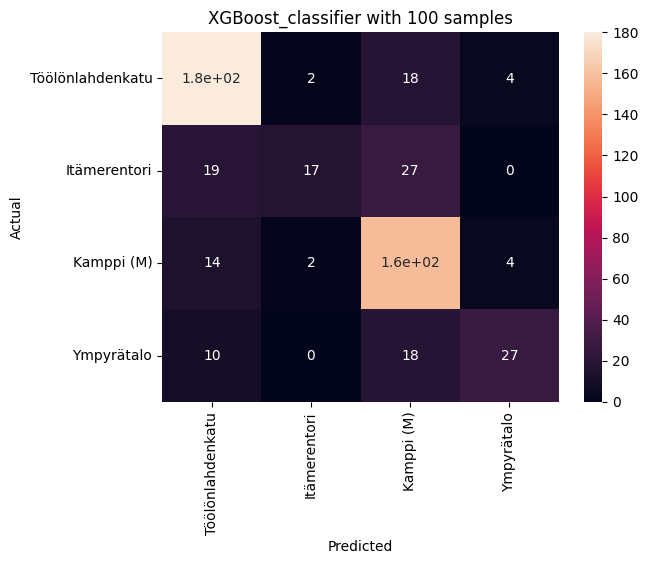

Total runtime for model fitting: 0.19220423698425293 seconds
not_imbalanced_bikes_XGBoost_classifier with trainingset size 1000, Accuracy: 0.908
Mean accuracy: 0.9055, Standard deviation: 0.02573421846491555
Macro f1-score: 0.8730397571211901, Macro recall-score: 0.8579974754627763


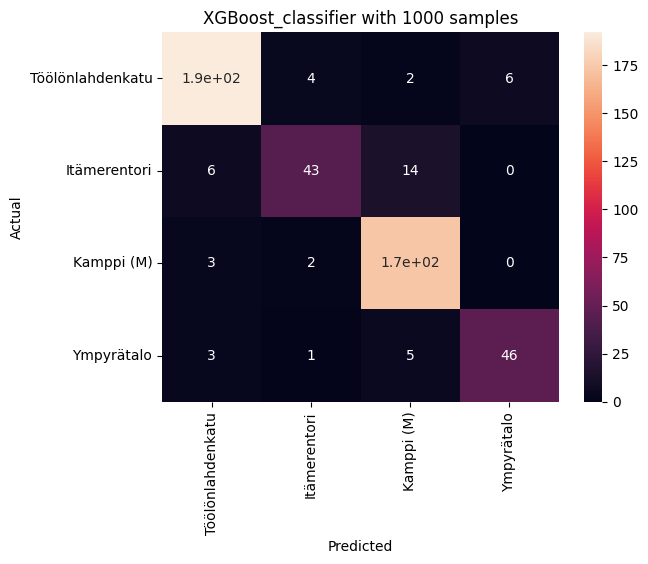

Total runtime for model fitting: 0.2566108703613281 seconds
not_imbalanced_bikes_XGBoost_classifier with trainingset size 2000, Accuracy: 0.928
Mean accuracy: 0.9145, Standard deviation: 0.009273618495495704
Macro f1-score: 0.902230167075093, Macro recall-score: 0.8961274175996582


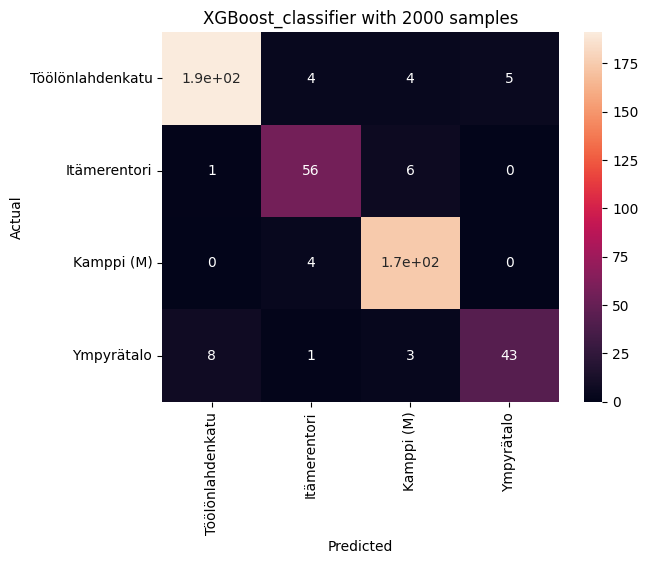

Total runtime for model fitting: 0.345233678817749 seconds
not_imbalanced_bikes_XGBoost_classifier with trainingset size 5000, Accuracy: 0.942
Mean accuracy: 0.9337000000000002, Standard deviation: 0.007733692520394092
Macro f1-score: 0.9230939205510209, Macro recall-score: 0.9266121940774948


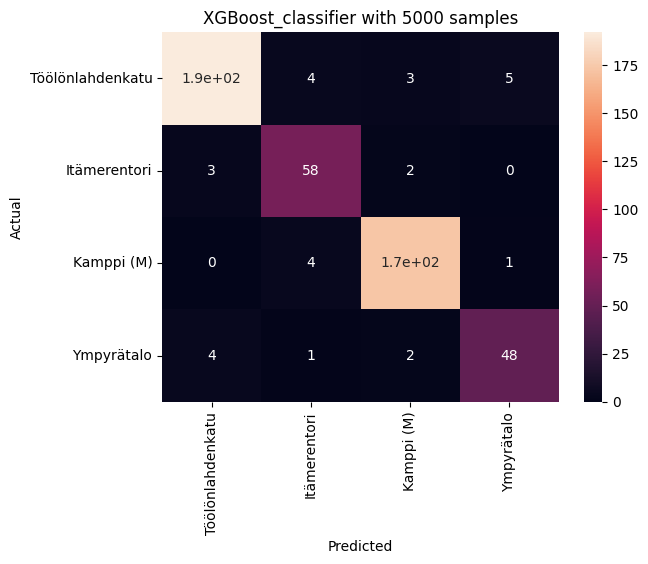

In [73]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [GBDT_clf_EN_Bikes_train], GBDT_clf_EN_Bikes_test, [xgb_classifier], classes_of_interest2, ["not_imbalanced_bikes"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.3415653705596924 seconds
imbalanced_bikes_XGBoost_classifier with trainingset size 100, Accuracy: 0.418
Mean accuracy: 0.45499999999999996, Standard deviation: 0.085
Macro f1-score: 0.2736798181019559, Macro recall-score: 0.28298430118484974


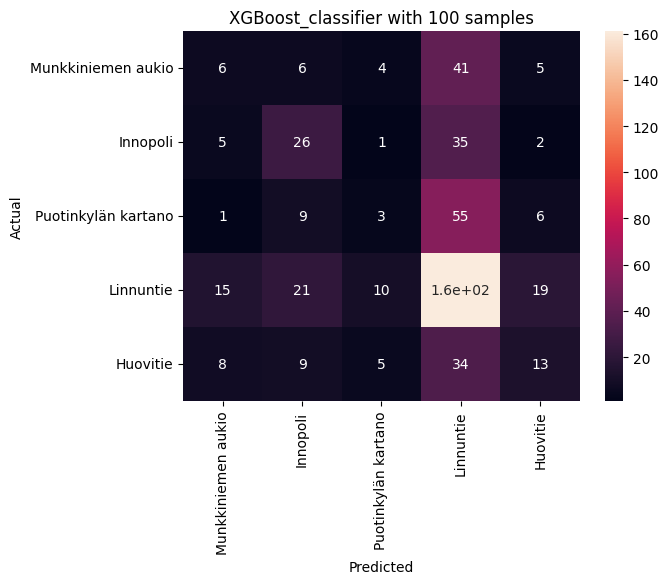

Total runtime for model fitting: 0.7722556591033936 seconds
imbalanced_bikes_XGBoost_classifier with trainingset size 1000, Accuracy: 0.806
Mean accuracy: 0.7755000000000001, Standard deviation: 0.025342651794948375
Macro f1-score: 0.7787581857383306, Macro recall-score: 0.7338592101515806


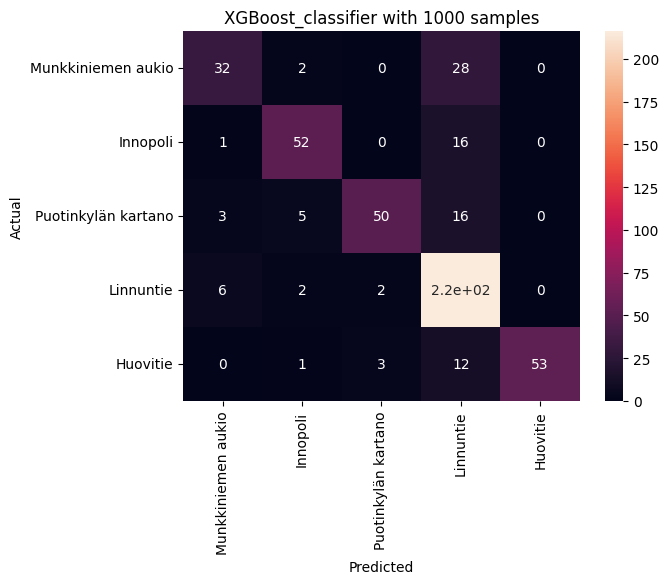

Total runtime for model fitting: 0.8662998676300049 seconds
imbalanced_bikes_XGBoost_classifier with trainingset size 2000, Accuracy: 0.868
Mean accuracy: 0.843, Standard deviation: 0.015644487847162034
Macro f1-score: 0.8554608186306629, Macro recall-score: 0.8189875747484754


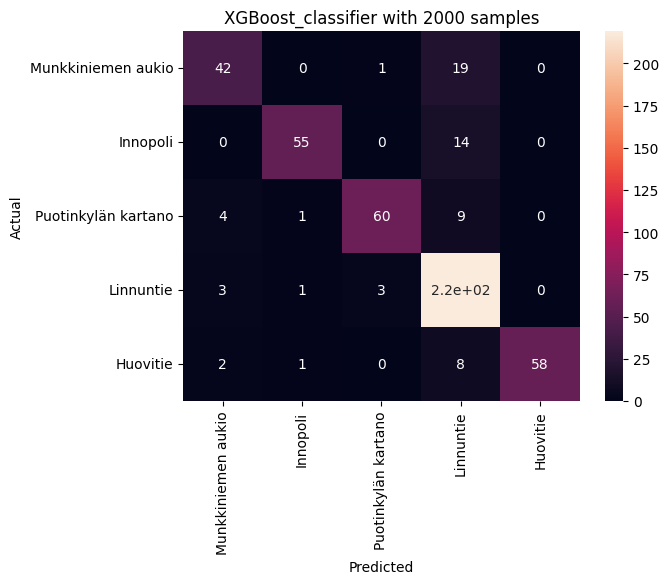

Total runtime for model fitting: 1.2085683345794678 seconds
imbalanced_bikes_XGBoost_classifier with trainingset size 5000, Accuracy: 0.908
Mean accuracy: 0.8976, Standard deviation: 0.0030397368307141354
Macro f1-score: 0.903946215067927, Macro recall-score: 0.87502634136327


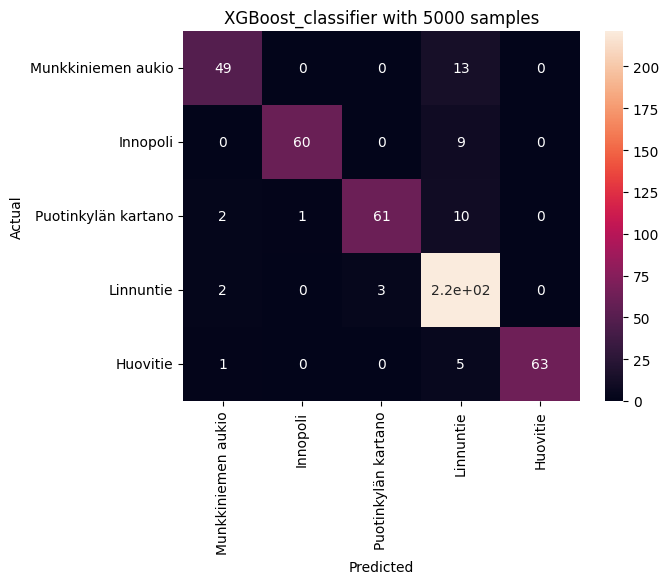

In [74]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [GBDT_imbalanced_bikes_train], GBDT_imbalanced_bikes_test, [xgb_classifier], classes_of_interest6, ["imbalanced_bikes"], ["XGBoost_classifier"], rskf, False, False)

#### CatBoost classifier

In [75]:
clf_model_comparison([100, 1000, 2000, 5000], "Palautusaseman nimi", [GBDT_clf_FI_Bikes_train], GBDT_clf_FI_Bikes_test, [cb_classifier], classes_of_interest2, ["FI_Bikes"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 1.2073993682861328 seconds
FI_Bikes_CatBoost_classifier with trainingset size 100, Accuracy: 0.77
Mean accuracy: 0.745, Standard deviation: 0.09340770846134704
Total runtime for model fitting: 2.5150606632232666 seconds
FI_Bikes_CatBoost_classifier with trainingset size 1000, Accuracy: 0.926
Mean accuracy: 0.925, Standard deviation: 0.02085665361461418
Total runtime for model fitting: 2.9563350677490234 seconds
FI_Bikes_CatBoost_classifier with trainingset size 2000, Accuracy: 0.948
Mean accuracy: 0.9339999999999999, Standard deviation: 0.010735455276791936
Total runtime for model fitting: 3.867079496383667 seconds
FI_Bikes_CatBoost_classifier with trainingset size 5000, Accuracy: 0.944
Mean accuracy: 0.9372, Standard deviation: 0.0063999999999999595


In [76]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [GBDT_clf_EN_Bikes_train], GBDT_clf_EN_Bikes_test, [cb_classifier], classes_of_interest2, ["EN_Bikes"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 1.213757038116455 seconds
EN_Bikes_CatBoost_classifier with trainingset size 100, Accuracy: 0.808
Mean accuracy: 0.8099999999999999, Standard deviation: 0.07999999999999999
Total runtime for model fitting: 2.6088719367980957 seconds
EN_Bikes_CatBoost_classifier with trainingset size 1000, Accuracy: 0.91
Mean accuracy: 0.9109999999999999, Standard deviation: 0.027459060435491955
Total runtime for model fitting: 3.103835105895996 seconds
EN_Bikes_CatBoost_classifier with trainingset size 2000, Accuracy: 0.914
Mean accuracy: 0.9200000000000002, Standard deviation: 0.009287087810503367
Total runtime for model fitting: 3.907778024673462 seconds
EN_Bikes_CatBoost_classifier with trainingset size 5000, Accuracy: 0.94
Mean accuracy: 0.9386000000000001, Standard deviation: 0.006118823416311297


Total runtime for model fitting: 1.2636816501617432 seconds
not_imbalanced_bikes_CatBoost_classifier with trainingset size 100, Accuracy: 0.808
Mean accuracy: 0.8099999999999999, Standard deviation: 0.07999999999999999
Macro f1-score: 0.706527464625264, Macro recall-score: 0.6741796088540966


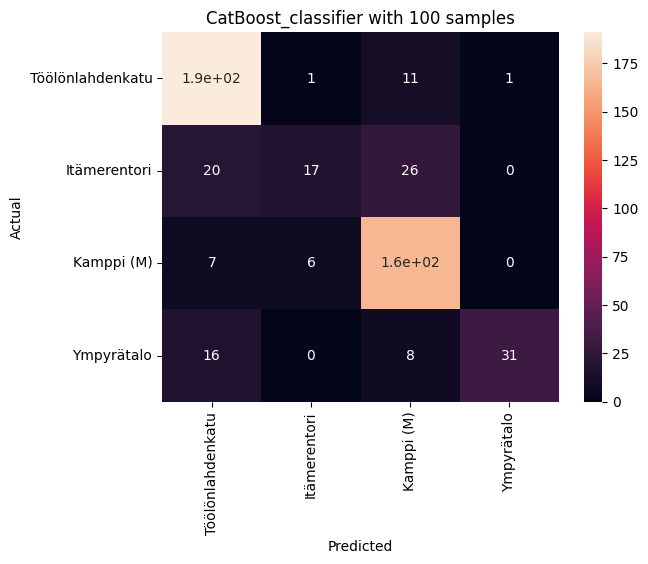

Total runtime for model fitting: 2.6233670711517334 seconds
not_imbalanced_bikes_CatBoost_classifier with trainingset size 1000, Accuracy: 0.91
Mean accuracy: 0.9109999999999999, Standard deviation: 0.027459060435491955
Macro f1-score: 0.8690011892372298, Macro recall-score: 0.8408155890888872


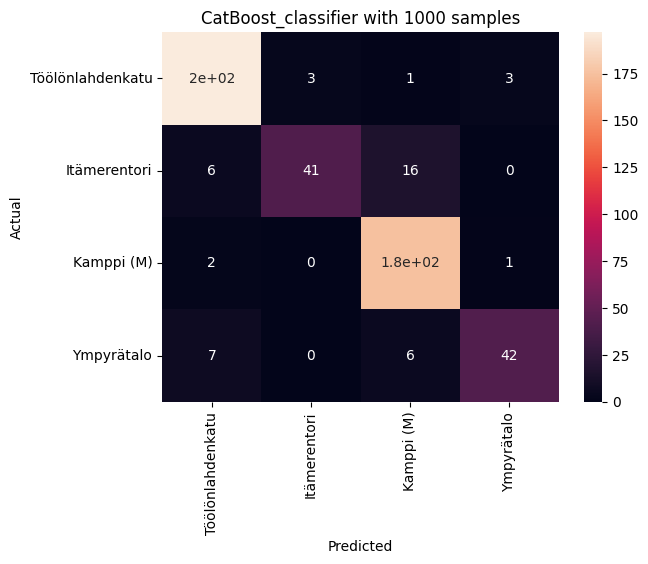

Total runtime for model fitting: 2.936006546020508 seconds
not_imbalanced_bikes_CatBoost_classifier with trainingset size 2000, Accuracy: 0.914
Mean accuracy: 0.9200000000000002, Standard deviation: 0.009287087810503367
Macro f1-score: 0.8803205020339435, Macro recall-score: 0.8597231521140972


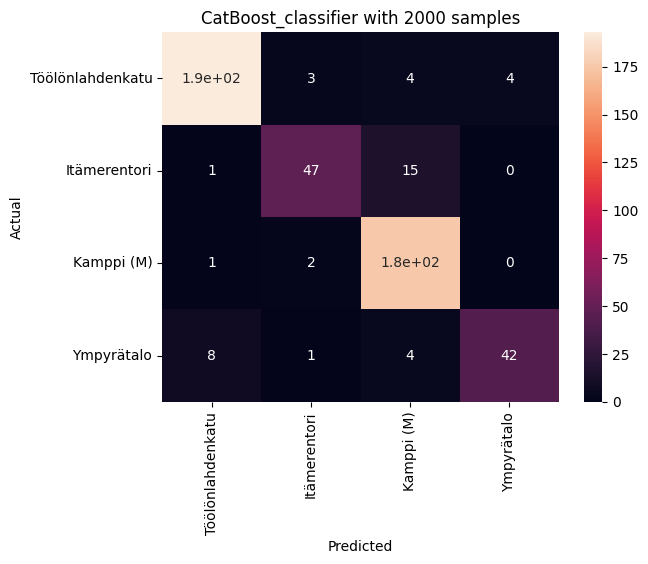

Total runtime for model fitting: 3.8514292240142822 seconds
not_imbalanced_bikes_CatBoost_classifier with trainingset size 5000, Accuracy: 0.94
Mean accuracy: 0.9386000000000001, Standard deviation: 0.006118823416311297
Macro f1-score: 0.9180933555933556, Macro recall-score: 0.9104782958467691


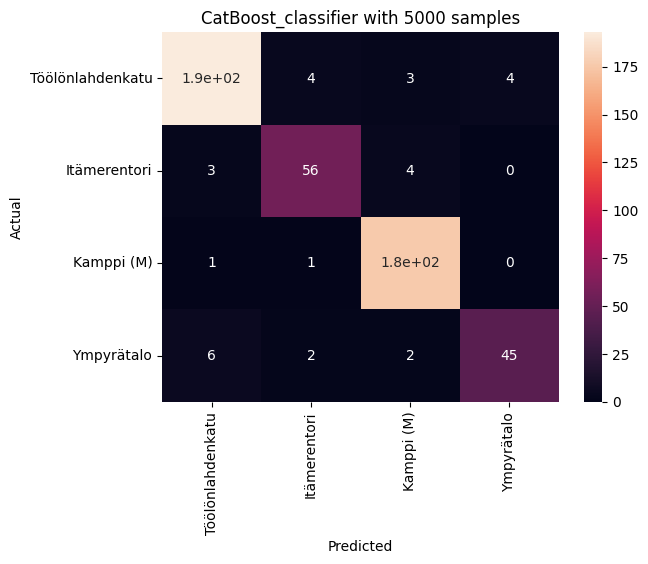

In [77]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [GBDT_clf_EN_Bikes_train], GBDT_clf_EN_Bikes_test, [cb_classifier], classes_of_interest2, ["not_imbalanced_bikes"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 1.867598533630371 seconds
imbalanced_bikes_CatBoost_classifier with trainingset size 100, Accuracy: 0.532
Mean accuracy: 0.48, Standard deviation: 0.07141428428542851
Macro f1-score: 0.37225832279996807, Macro recall-score: 0.353120972130765


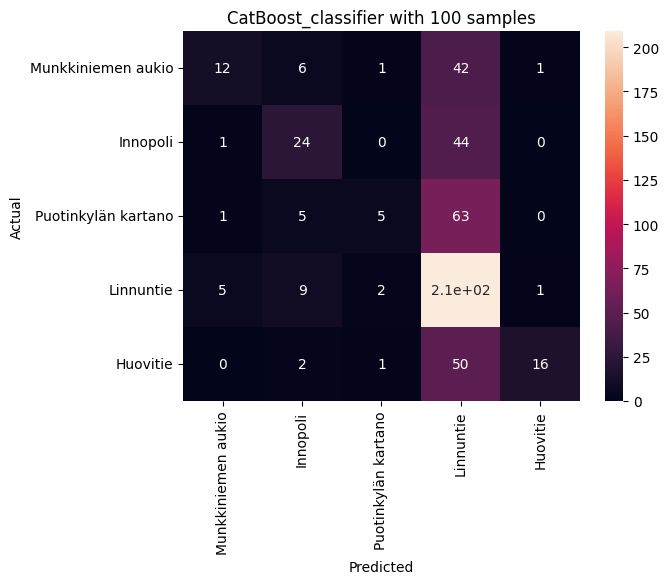

Total runtime for model fitting: 4.004098176956177 seconds
imbalanced_bikes_CatBoost_classifier with trainingset size 1000, Accuracy: 0.828
Mean accuracy: 0.8215, Standard deviation: 0.017471405209656128
Macro f1-score: 0.8059447473568069, Macro recall-score: 0.769314321706681


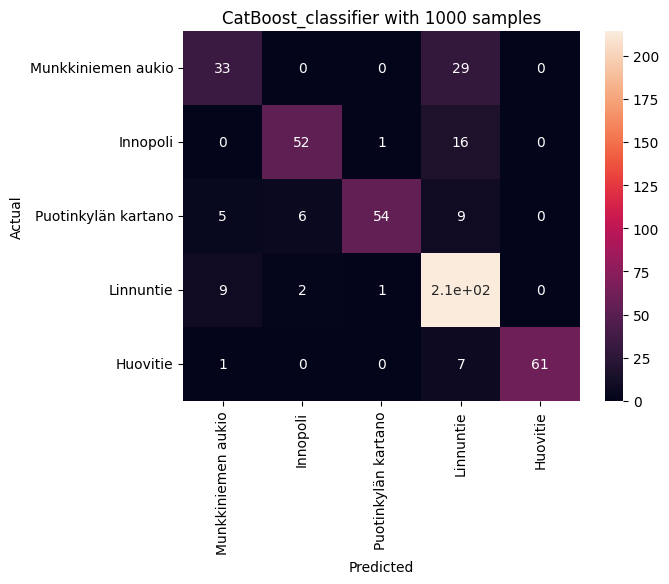

Total runtime for model fitting: 4.673358917236328 seconds
imbalanced_bikes_CatBoost_classifier with trainingset size 2000, Accuracy: 0.876
Mean accuracy: 0.8645000000000002, Standard deviation: 0.014866068747318493
Macro f1-score: 0.864912398530743, Macro recall-score: 0.8262273319752002


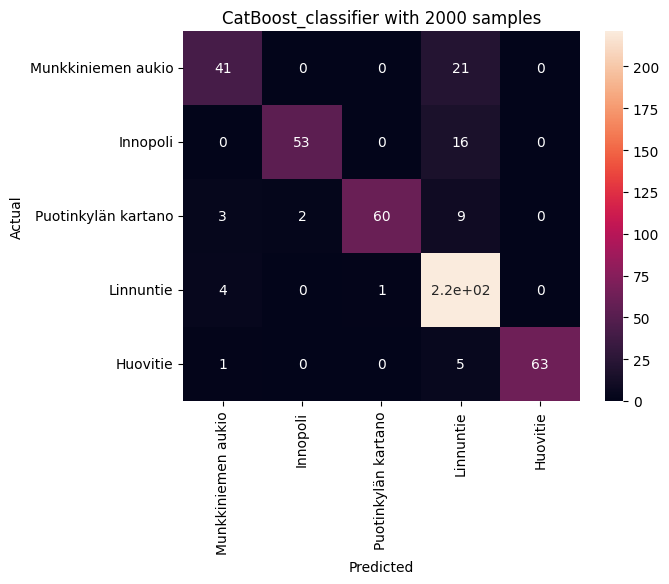

Total runtime for model fitting: 6.088165521621704 seconds
imbalanced_bikes_CatBoost_classifier with trainingset size 5000, Accuracy: 0.918
Mean accuracy: 0.899, Standard deviation: 0.005039841267341666
Macro f1-score: 0.9130452895483764, Macro recall-score: 0.8839225937948771


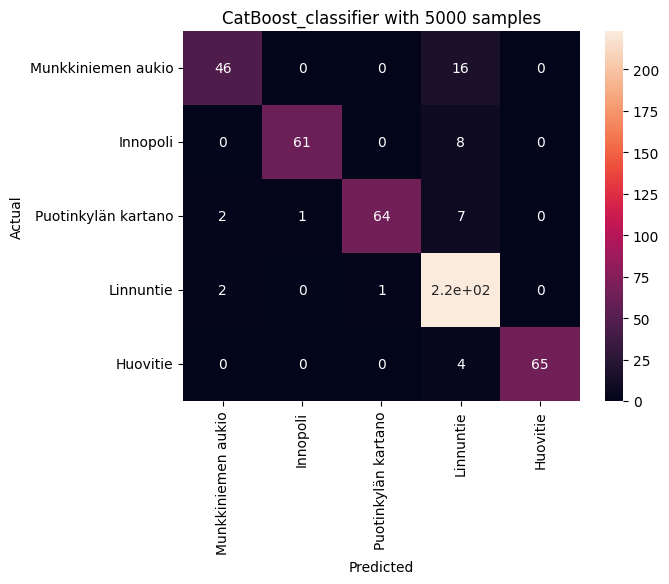

In [78]:
clf_model_comparison([100, 1000, 2000, 5000], "Return station name", [GBDT_imbalanced_bikes_train], GBDT_imbalanced_bikes_test, [cb_classifier], classes_of_interest6, ["imbalanced_bikes"], ["CatBoost_classifier"], rskf, False, False)

### City Bikes regression (trainingsets sizes 100, 1000, 2000 and 5000)

#### TabPFN regressor

In [79]:
reg_model_comparison([100, 1000, 2000, 5000], "Kuljettu matka (m)", [reg_FI_Bikes_train], reg_FI_Bikes_test, [TabPFN_regressor], ["FI_Bikes"], ["TabPFN_regressor"], k_folds)

/turso/home/hiltunek/venv/lib/python3.12/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:152: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/turso/home/hiltunek/venv/lib/python3.12/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:152: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/turso/home/hiltunek/venv/lib/python3.12/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:152: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/turso/home/hiltunek/venv/lib/python3.12/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:152: RuntimeWarning: overflow encountered in cast
  x_inv[pos] = np.expm1(np.log(x[pos] * lmbda + 1) / lmbda)
/turso/home/hiltunek/venv/lib/python3.12/site-packages/tabpfn/preprocessing/steps/safe_power_transformer.py:152: RuntimeWarning:

Training set size: 100, Mean R2 score: 0.6340470960536562, Standard deviation: 0.23460924326656377
Total runtime for model fitting: 0.26909303665161133 seconds
FI_Bikes_TabPFN_regressor with training set of 100: R2-score: 0.6523046192899671, mean absolute error: 576.5492006921768, mean squared error: 947370.1804639931
Training set size: 1000, Mean R2 score: 0.6502022156106027, Standard deviation: 0.09270590914623125
Total runtime for model fitting: 0.3430013656616211 seconds
FI_Bikes_TabPFN_regressor with training set of 1000: R2-score: 0.6973907445182785, mean absolute error: 554.8557600555197, mean squared error: 824523.4215949441
Training set size: 2000, Mean R2 score: 0.6903087536139599, Standard deviation: 0.04784750366914962
Total runtime for model fitting: 0.4010124206542969 seconds
FI_Bikes_TabPFN_regressor with training set of 2000: R2-score: 0.6989281031798313, mean absolute error: 542.92302412045, mean squared error: 820334.5602138727
Training set size: 5000, Mean R2 score: 

In [80]:
reg_model_comparison([100, 1000, 2000, 5000],"Covered distance (m)", [reg_EN_Bikes_train], reg_EN_Bikes_test, [TabPFN_regressor], ["EN_Bikes"], ["TabPFN_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.530017660696134, Standard deviation: 0.13635432120698718
Total runtime for model fitting: 0.2543001174926758 seconds
EN_Bikes_TabPFN_regressor with training set of 100: R2-score: 0.6621718817156571, mean absolute error: 565.6453810901642, mean squared error: 855876.1986698842
Training set size: 1000, Mean R2 score: 0.6817265106704253, Standard deviation: 0.056226502316460786
Total runtime for model fitting: 0.34047818183898926 seconds
EN_Bikes_TabPFN_regressor with training set of 1000: R2-score: 0.7557857515844776, mean absolute error: 490.636885948658, mean squared error: 618708.601452099
Training set size: 2000, Mean R2 score: 0.6901191611914097, Standard deviation: 0.018404598872025203
Total runtime for model fitting: 0.39835023880004883 seconds
EN_Bikes_TabPFN_regressor with training set of 2000: R2-score: 0.7630074918882009, mean absolute error: 482.10043433976176, mean squared error: 600412.5647861118
Training set size: 5000, Mean R2 scor

#### TabICL regressor

In [81]:
reg_model_comparison([100, 1000, 2000, 5000], "Kuljettu matka (m)", [reg_FI_Bikes_train], reg_FI_Bikes_test, [TabICL_regressor], ["FI_Bikes"], ["TabICL_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.5787369446676427, Standard deviation: 0.2767157572217138
Total runtime for model fitting: 0.49538397789001465 seconds
FI_Bikes_TabICL_regressor with training set of 100: R2-score: 0.6245032125349116, mean absolute error: 590.3138970184326, mean squared error: 1023121.0393937386
Training set size: 1000, Mean R2 score: 0.6859630540380618, Standard deviation: 0.07660177566397275
Total runtime for model fitting: 0.5075531005859375 seconds
FI_Bikes_TabICL_regressor with training set of 1000: R2-score: 0.69021061135927, mean absolute error: 554.641662070334, mean squared error: 844087.2249239229
Training set size: 2000, Mean R2 score: 0.6973920778734122, Standard deviation: 0.04721597396665884
Total runtime for model fitting: 0.5263588428497314 seconds
FI_Bikes_TabICL_regressor with training set of 2000: R2-score: 0.6898190284288856, mean absolute error: 545.528529499054, mean squared error: 845154.1760886675
Training set size: 5000, Mean R2 score: 0.

In [82]:
reg_model_comparison([100, 1000, 2000, 5000],"Covered distance (m)", [reg_EN_Bikes_train], reg_EN_Bikes_test, [TabICL_regressor], ["EN_Bikes"], ["TabICL_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.4712759137906698, Standard deviation: 0.17364517030744966
Total runtime for model fitting: 0.5322620868682861 seconds
EN_Bikes_TabICL_regressor with training set of 100: R2-score: 0.6850484419042493, mean absolute error: 551.7249361534118, mean squared error: 797919.2012704689
Training set size: 1000, Mean R2 score: 0.6921267832160697, Standard deviation: 0.04952531219109974
Total runtime for model fitting: 0.5536153316497803 seconds
EN_Bikes_TabICL_regressor with training set of 1000: R2-score: 0.7486041813317906, mean absolute error: 491.3191107094288, mean squared error: 636902.8686420701
Training set size: 2000, Mean R2 score: 0.6897987977192599, Standard deviation: 0.0227060393694152
Total runtime for model fitting: 0.5306649208068848 seconds
EN_Bikes_TabICL_regressor with training set of 2000: R2-score: 0.7596882684499174, mean absolute error: 483.15495231819153, mean squared error: 608821.7059592068
Training set size: 5000, Mean R2 score:

#### ConTextTab regressor

In [83]:
reg_model_comparison([100, 1000, 2000, 5000], "Kuljettu matka (m)", [reg_FI_Bikes_train], reg_FI_Bikes_test, [ConTextTab_regressor], ["FI_Bikes"], ["ConTextTab_regressor"], k_folds)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 5000, Mean R2 score: 0.5509926556672401, Standard deviation: 0.2769040867135789
Total runtime for model fitting: 0.0004363059997558594 seconds
FI_Bikes_ConTextTab_regressor with training set of 5000: R2-score: 0.7015454356430235, mean absolute error: 521.232, mean squared error: 813203.08


In [84]:
reg_model_comparison([100, 1000, 2000, 5000], "Covered distance (m)", [reg_EN_Bikes_train], reg_EN_Bikes_test, [ConTextTab_regressor], ["EN_Bikes"], ["ConTextTab_regressor"], k_folds)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 5000, Mean R2 score: 0.6935764909944513, Standard deviation: 0.009594924320715105
Total runtime for model fitting: 0.0004391670227050781 seconds
EN_Bikes_ConTextTab_regressor with training set of 5000: R2-score: 0.7678165853164718, mean absolute error: 479.536, mean squared error: 588228.888


#### XGBoost regressor

In [45]:
reg_FI_Bikes = reg_FI_Bikes.iloc[:10000]
reg_EN_Bikes = reg_EN_Bikes.iloc[:10000]

In [46]:
categories = ["Lähtöaseman nimi", "Palautusaseman nimi"]
int_vals = ["Kesto (sek.)", "Vuosi", "Kuukausi", "Lähtöpäivä", "Lähtö tunti", "Lähtö min.", "Lähtö sek.", "Palautuspäivä", "Palautustunti", "Palautus min.", "Palautus sek."]
float_vals = ["Kesto (sek.)"]
GBDT_reg_FI_Bikes = modify_df(reg_FI_Bikes, int_vals, float_vals, categories)

categories = ["Departure station name", "Return station name"]
int_vals = ["Duration (sec.)", "Year", "Month", "Departure day", "Departure hour", "Departure min.", "Departure sec.", "Return day", "Return hour", "Return min.", "Return sec."]
float_vals = ["Duration (sec.)"]
GBDT_reg_EN_Bikes = modify_df(reg_EN_Bikes, int_vals, float_vals, categories)

In [47]:
GBDT_reg_FI_Bikes_test = GBDT_reg_FI_Bikes.iloc[:500]
GBDT_reg_FI_Bikes_train = GBDT_reg_FI_Bikes.iloc[500:]

GBDT_reg_EN_Bikes_test = GBDT_reg_EN_Bikes.iloc[:500]
GBDT_reg_EN_Bikes_train = GBDT_reg_EN_Bikes.iloc[500:]

In [88]:
reg_model_comparison([100, 1000, 2000, 5000], "Kuljettu matka (m)", [GBDT_reg_FI_Bikes_train], GBDT_reg_FI_Bikes_test, [xgb_regressor], ["FI_Bikes"], ["XGBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.2100923983880744, Standard deviation: 0.9210835103852055
Total runtime for model fitting: 0.5687723159790039 seconds
FI_Bikes_XGBoost_regressor with training set of 100: R2-score: 0.5975544664070278, mean absolute error: 650.2651321105957, mean squared error: 1096548.6426892313
Training set size: 1000, Mean R2 score: 0.591789309010118, Standard deviation: 0.10657219869050095
Total runtime for model fitting: 0.6784183979034424 seconds
FI_Bikes_XGBoost_regressor with training set of 1000: R2-score: 0.6190570811586107, mean absolute error: 631.375141117096, mean squared error: 1037960.1852410621
Training set size: 2000, Mean R2 score: 0.6594796736540822, Standard deviation: 0.038432818855763856
Total runtime for model fitting: 0.7358386516571045 seconds
FI_Bikes_XGBoost_regressor with training set of 2000: R2-score: 0.6083760253542985, mean absolute error: 620.9168018093109, mean squared error: 1067062.9985836302
Training set size: 5000, Mean R2 sc

In [89]:
reg_model_comparison([100, 1000, 2000, 5000], "Covered distance (m)", [GBDT_reg_EN_Bikes_train], GBDT_reg_EN_Bikes_test, [xgb_regressor], ["EN_Bikes"], ["XGBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.49144372883122445, Standard deviation: 0.26426887408075167
Total runtime for model fitting: 0.5931675434112549 seconds
EN_Bikes_XGBoost_regressor with training set of 100: R2-score: 0.4396273855978099, mean absolute error: 734.8997192869186, mean squared error: 1419685.2100084038
Training set size: 1000, Mean R2 score: 0.617583944219283, Standard deviation: 0.10054379116055728
Total runtime for model fitting: 0.713768720626831 seconds
EN_Bikes_XGBoost_regressor with training set of 1000: R2-score: 0.6825598148399588, mean absolute error: 574.6196310157776, mean squared error: 804224.0544085345
Training set size: 2000, Mean R2 score: 0.6314360482074777, Standard deviation: 0.027512652183880482
Total runtime for model fitting: 0.8352124691009521 seconds
EN_Bikes_XGBoost_regressor with training set of 2000: R2-score: 0.7183641964032872, mean absolute error: 540.5968306221962, mean squared error: 713514.8554709997
Training set size: 5000, Mean R2 sc

#### CatBoost regressor

In [90]:
reg_model_comparison([100, 1000, 2000, 5000], "Kuljettu matka (m)", [GBDT_reg_FI_Bikes_train], GBDT_reg_FI_Bikes_test, [cb_regressor], ["FI_Bikes"], ["CatBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6310955950220684, Standard deviation: 0.20241776604307646
Total runtime for model fitting: 1.5153396129608154 seconds
FI_Bikes_CatBoost_regressor with training set of 100: R2-score: 0.6534629065829085, mean absolute error: 614.9176827060389, mean squared error: 944214.1798306162
Training set size: 1000, Mean R2 score: 0.6443133024202798, Standard deviation: 0.08977691272682789
Total runtime for model fitting: 2.674334764480591 seconds
FI_Bikes_CatBoost_regressor with training set of 1000: R2-score: 0.6209072741171368, mean absolute error: 620.6062058828278, mean squared error: 1032918.9401332536
Training set size: 2000, Mean R2 score: 0.6745691243252865, Standard deviation: 0.056464667242730006
Total runtime for model fitting: 2.5126378536224365 seconds
FI_Bikes_CatBoost_regressor with training set of 2000: R2-score: 0.6632170207768883, mean absolute error: 581.7638655629604, mean squared error: 917637.0164948645
Training set size: 5000, Mean R2

In [91]:
reg_model_comparison([100, 1000, 2000, 5000], "Covered distance (m)", [GBDT_reg_EN_Bikes_train], GBDT_reg_EN_Bikes_test, [cb_regressor], ["EN_Bikes"], ["CatBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.5573237485909284, Standard deviation: 0.10811912667835274
Total runtime for model fitting: 0.9645440578460693 seconds
EN_Bikes_CatBoost_regressor with training set of 100: R2-score: 0.564977801445218, mean absolute error: 675.8423489371189, mean squared error: 1102114.1387724988
Training set size: 1000, Mean R2 score: 0.6660810063002288, Standard deviation: 0.0522499821266977
Total runtime for model fitting: 2.1804568767547607 seconds
EN_Bikes_CatBoost_regressor with training set of 1000: R2-score: 0.7390102958532005, mean absolute error: 522.236846645769, mean squared error: 661208.6554889147
Training set size: 2000, Mean R2 score: 0.6562681525080505, Standard deviation: 0.01789945715757478
Total runtime for model fitting: 2.4684433937072754 seconds
EN_Bikes_CatBoost_regressor with training set of 2000: R2-score: 0.756468990226742, mean absolute error: 506.81244541710186, mean squared error: 616977.6392844283
Training set size: 5000, Mean R2 sc

## Weather 

### Weather classification (trainingsets sizes 100, 1000, 2000 and 5000)

#### TabPFN classifier

In [92]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [FI_kumpula_train], FI_kumpula_test, [TabPFN_classifier], classes_of_interest3, ["FI_kumpula"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.2397172451019287 seconds
FI_kumpula_TabPFN_classifier with trainingset size 100, Accuracy: 0.512
Mean accuracy: 0.49000000000000005, Standard deviation: 0.07348469228349536
Total runtime for model fitting: 0.4241452217102051 seconds
FI_kumpula_TabPFN_classifier with trainingset size 1000, Accuracy: 0.53
Mean accuracy: 0.5285, Standard deviation: 0.02693046601899047
Total runtime for model fitting: 0.36264944076538086 seconds
FI_kumpula_TabPFN_classifier with trainingset size 2000, Accuracy: 0.554
Mean accuracy: 0.53125, Standard deviation: 0.010738365797457286
Total runtime for model fitting: 0.595484733581543 seconds
FI_kumpula_TabPFN_classifier with trainingset size 5000, Accuracy: 0.586
Mean accuracy: 0.5763999999999999, Standard deviation: 0.01223274294669842


In [93]:
clf_model_comparison([100, 1000, 2000, 5000], "Current weather", [EN_kumpula_train], EN_kumpula_test, [TabPFN_classifier], classes_of_interest4, ["EN_kumpula"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.27154064178466797 seconds
EN_kumpula_TabPFN_classifier with trainingset size 100, Accuracy: 0.508
Mean accuracy: 0.4750000000000001, Standard deviation: 0.06800735254367722
Total runtime for model fitting: 0.35583925247192383 seconds
EN_kumpula_TabPFN_classifier with trainingset size 1000, Accuracy: 0.532
Mean accuracy: 0.5229999999999999, Standard deviation: 0.025806975801127886
Total runtime for model fitting: 0.36618471145629883 seconds
EN_kumpula_TabPFN_classifier with trainingset size 2000, Accuracy: 0.546
Mean accuracy: 0.5325, Standard deviation: 0.00961769203083568
Total runtime for model fitting: 0.5866725444793701 seconds
EN_kumpula_TabPFN_classifier with trainingset size 5000, Accuracy: 0.582
Mean accuracy: 0.573, Standard deviation: 0.010516653460107907


Total runtime for model fitting: 0.2539482116699219 seconds
not_imbalanced_weather_TabPFN_classifier with trainingset size 100, Accuracy: 0.512
Mean accuracy: 0.49000000000000005, Standard deviation: 0.07348469228349536
Macro f1-score: 0.2922802123582001, Macro recall-score: 0.3325629000487985


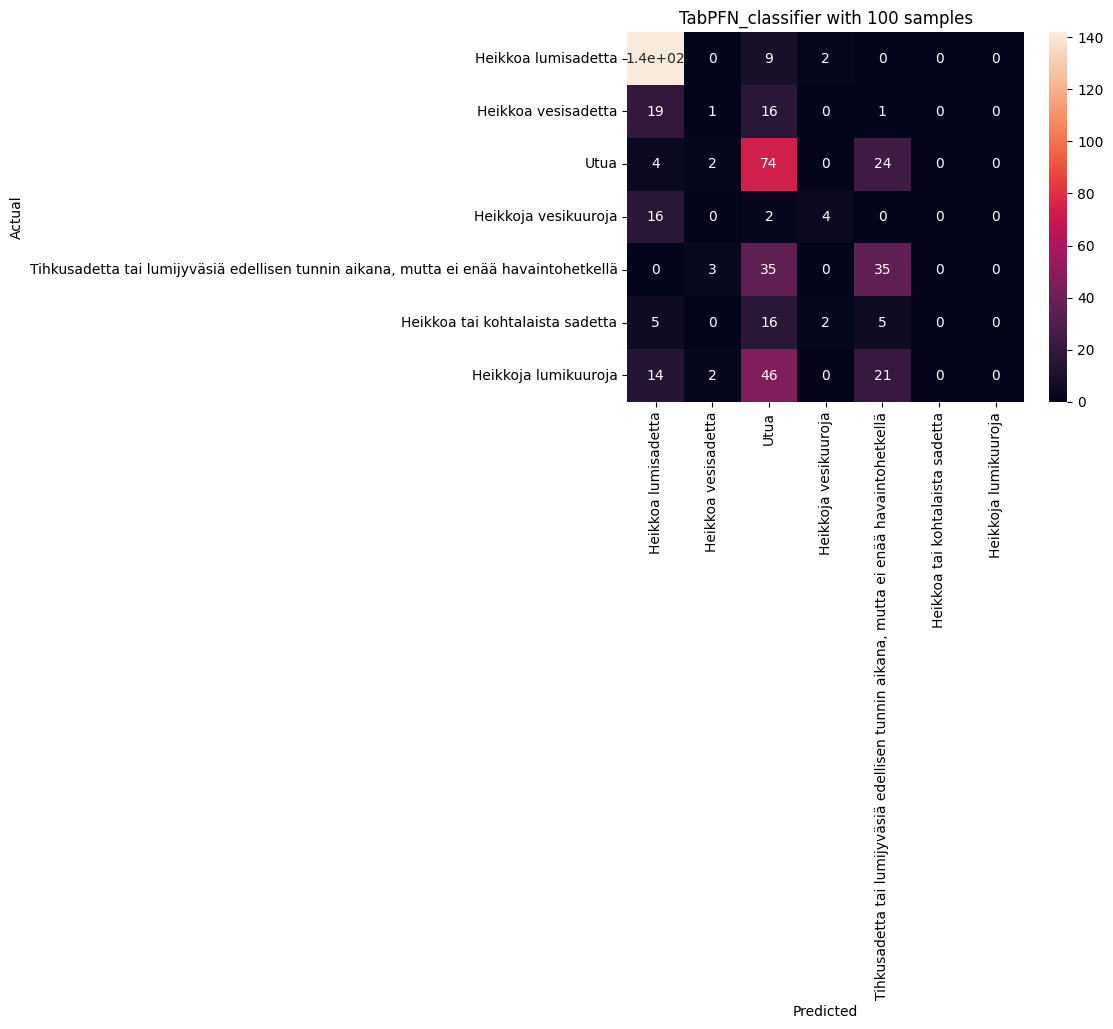

Total runtime for model fitting: 0.3738992214202881 seconds
not_imbalanced_weather_TabPFN_classifier with trainingset size 1000, Accuracy: 0.53
Mean accuracy: 0.5285, Standard deviation: 0.02693046601899047
Macro f1-score: 0.2615748951650211, Macro recall-score: 0.32123354439087964


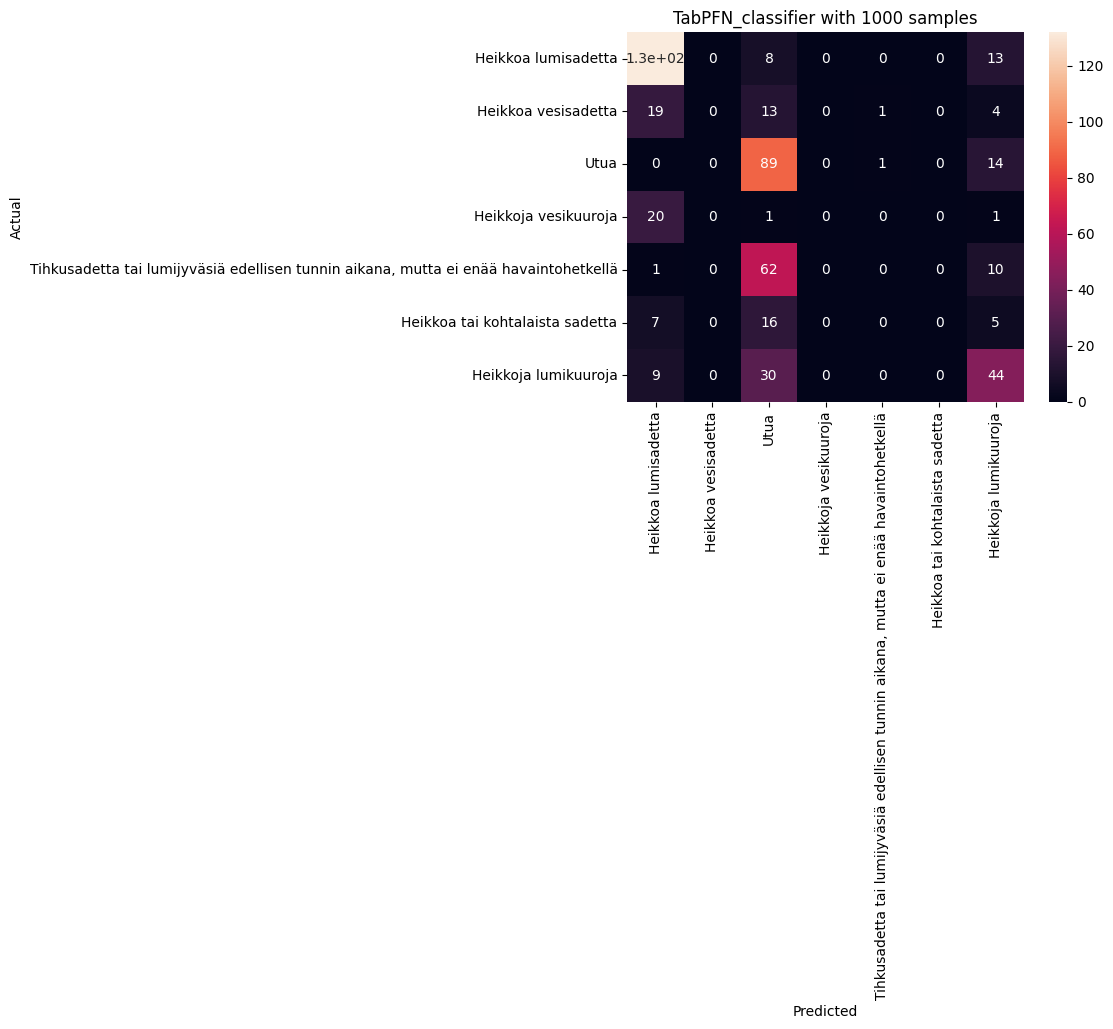

Total runtime for model fitting: 0.3946242332458496 seconds
not_imbalanced_weather_TabPFN_classifier with trainingset size 2000, Accuracy: 0.554
Mean accuracy: 0.53125, Standard deviation: 0.010738365797457286
Macro f1-score: 0.2924858591081498, Macro recall-score: 0.33802578144854584


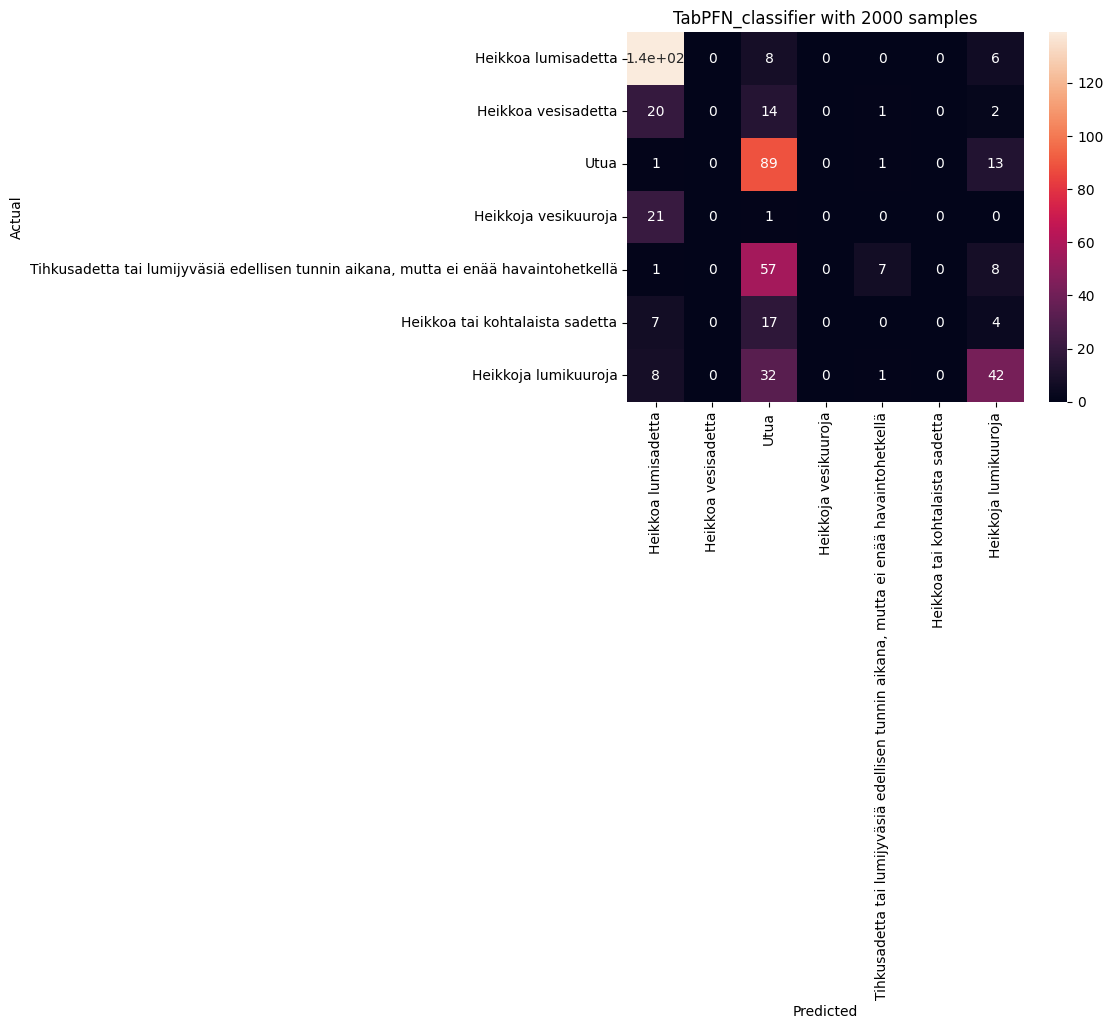

Total runtime for model fitting: 0.6139578819274902 seconds
not_imbalanced_weather_TabPFN_classifier with trainingset size 5000, Accuracy: 0.586
Mean accuracy: 0.5763999999999999, Standard deviation: 0.01223274294669842
Macro f1-score: 0.3399490199264073, Macro recall-score: 0.3716090804852783


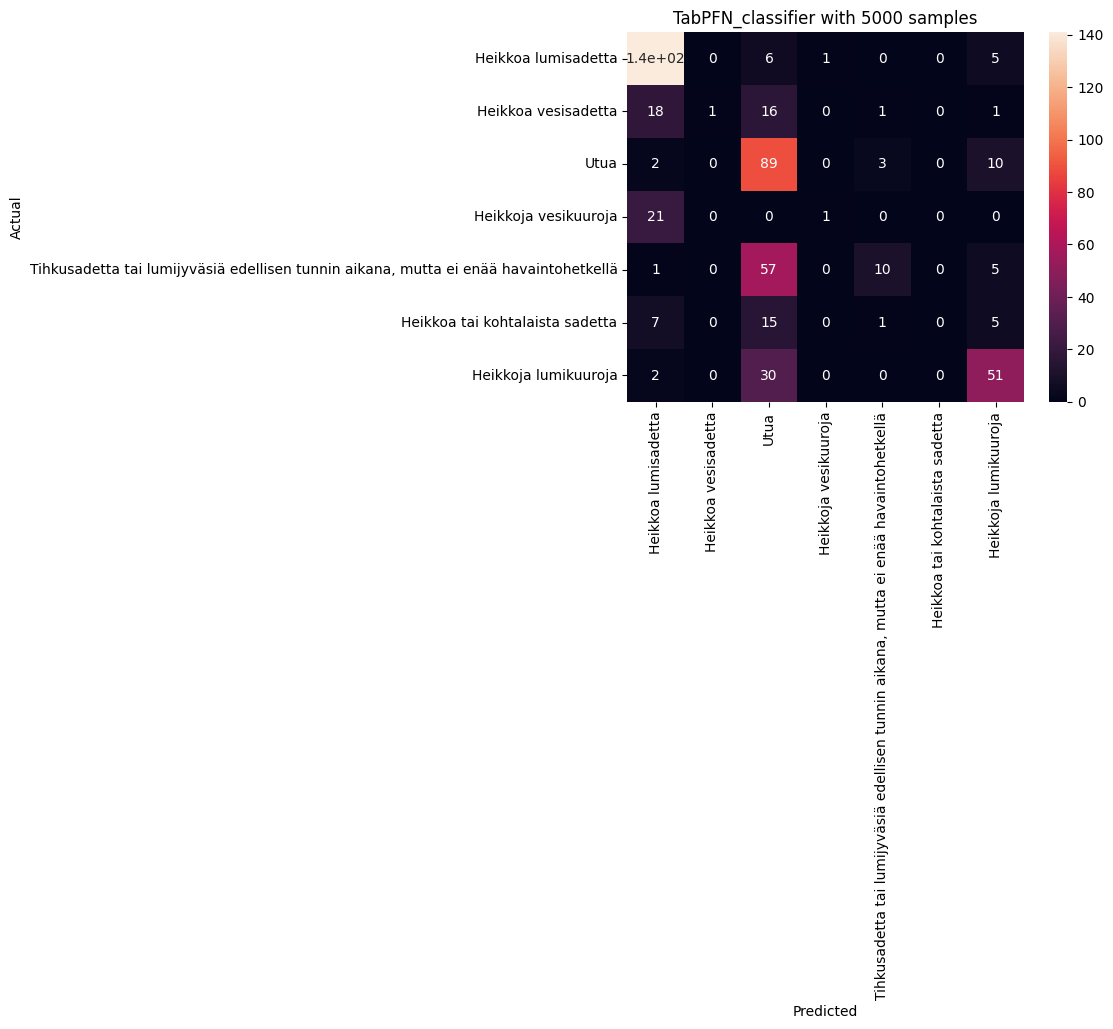

In [94]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [FI_kumpula_train], FI_kumpula_test, [TabPFN_classifier], classes_of_interest3, ["not_imbalanced_weather"], ["TabPFN_classifier"], rskf, False, False)

Total runtime for model fitting: 0.25623321533203125 seconds
imbalanced_weather_TabPFN_classifier with trainingset size 100, Accuracy: 0.18
Mean accuracy: 0.9399999999999998, Standard deviation: 0.03741657386773941
Macro f1-score: 0.16920786815523656, Macro recall-score: 0.4034891165172856


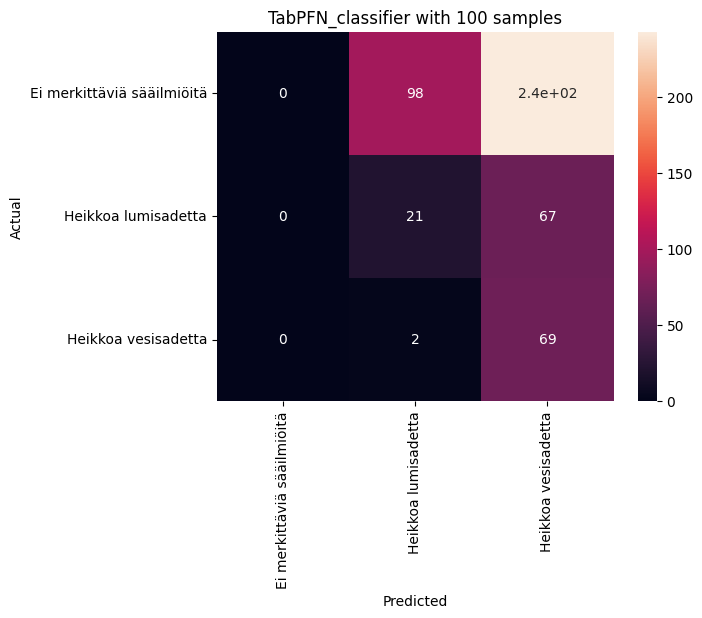

Total runtime for model fitting: 0.31633472442626953 seconds
imbalanced_weather_TabPFN_classifier with trainingset size 1000, Accuracy: 0.86
Mean accuracy: 0.8985000000000001, Standard deviation: 0.014840822079655841
Macro f1-score: 0.7525723935762879, Macro recall-score: 0.7458989027026283


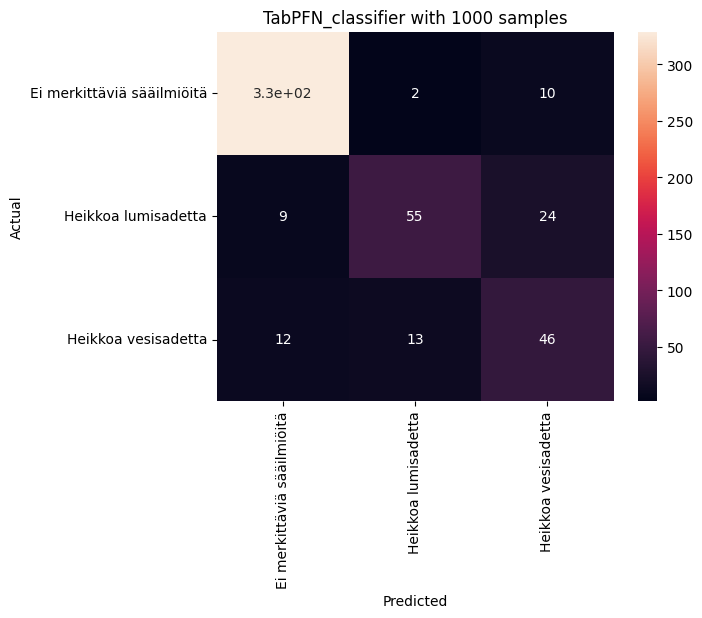

Total runtime for model fitting: 0.37302327156066895 seconds
imbalanced_weather_TabPFN_classifier with trainingset size 2000, Accuracy: 0.87
Mean accuracy: 0.92275, Standard deviation: 0.013297086146972186
Macro f1-score: 0.7648547068266763, Macro recall-score: 0.7620279349606928


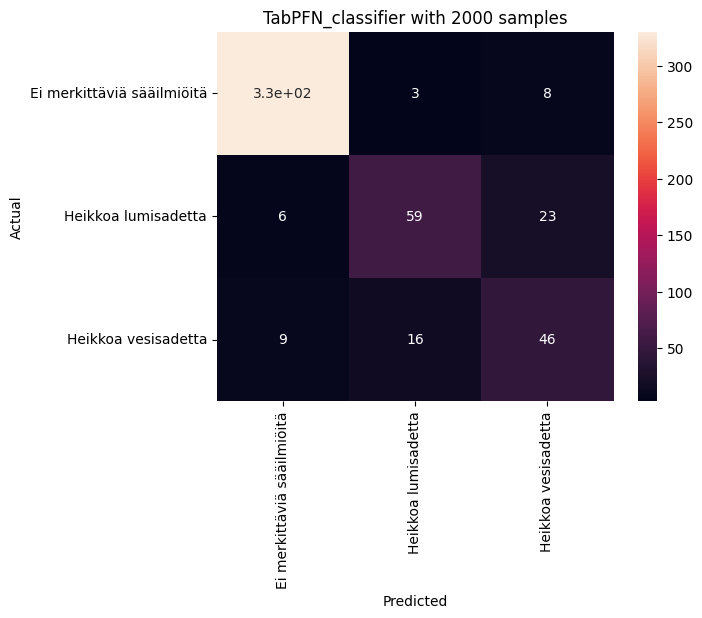

Total runtime for model fitting: 0.5444490909576416 seconds
imbalanced_weather_TabPFN_classifier with trainingset size 5000, Accuracy: 0.856
Mean accuracy: 0.9359999999999999, Standard deviation: 0.008820430828479936
Macro f1-score: 0.7483278129942038, Macro recall-score: 0.7494751008494761


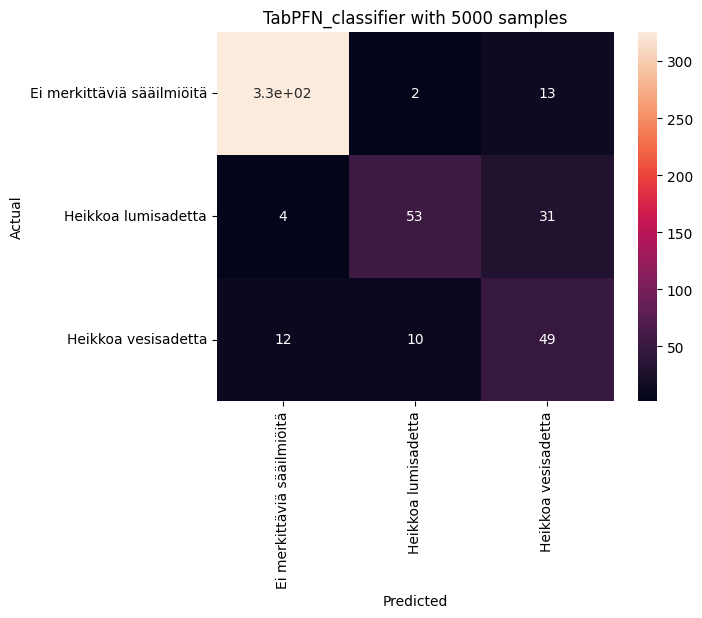

In [95]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [clf_imbalanced_weather_train], clf_imbalanced_weather_test, [TabPFN_classifier], classes_of_interest7, ["imbalanced_weather"], ["TabPFN_classifier"], rskf, False, False)

#### TabICL classifier

In [96]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [FI_kumpula_train], FI_kumpula_test, [TabICL_classifier], classes_of_interest3, ["FI_kumpula"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.50929856300354 seconds
FI_kumpula_TabICL_classifier with trainingset size 100, Accuracy: 0.428
Mean accuracy: 0.465, Standard deviation: 0.07762087348130012
Total runtime for model fitting: 0.5280075073242188 seconds
FI_kumpula_TabICL_classifier with trainingset size 1000, Accuracy: 0.512
Mean accuracy: 0.5025000000000001, Standard deviation: 0.0357246413557925
Total runtime for model fitting: 0.5511584281921387 seconds
FI_kumpula_TabICL_classifier with trainingset size 2000, Accuracy: 0.548
Mean accuracy: 0.5322500000000001, Standard deviation: 0.015266384640772051
Total runtime for model fitting: 0.6341192722320557 seconds
FI_kumpula_TabICL_classifier with trainingset size 5000, Accuracy: 0.582
Mean accuracy: 0.5746, Standard deviation: 0.01110135126910233


In [97]:
clf_model_comparison([100, 1000, 2000, 5000], "Current weather", [EN_kumpula_train], EN_kumpula_test, [TabICL_classifier], classes_of_interest4, ["EN_kumpula"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.50392746925354 seconds
EN_kumpula_TabICL_classifier with trainingset size 100, Accuracy: 0.436
Mean accuracy: 0.47000000000000003, Standard deviation: 0.08124038404635961
Total runtime for model fitting: 0.529259204864502 seconds
EN_kumpula_TabICL_classifier with trainingset size 1000, Accuracy: 0.512
Mean accuracy: 0.502, Standard deviation: 0.034146742157927755
Total runtime for model fitting: 0.5508804321289062 seconds
EN_kumpula_TabICL_classifier with trainingset size 2000, Accuracy: 0.542
Mean accuracy: 0.52775, Standard deviation: 0.011149551560488878
Total runtime for model fitting: 0.6590676307678223 seconds
EN_kumpula_TabICL_classifier with trainingset size 5000, Accuracy: 0.578
Mean accuracy: 0.5753, Standard deviation: 0.010237675517420943


Total runtime for model fitting: 0.513824462890625 seconds
not_imbalanced_weather_TabICL_classifier with trainingset size 100, Accuracy: 0.428
Mean accuracy: 0.465, Standard deviation: 0.07762087348130012
Macro f1-score: 0.2840026115539989, Macro recall-score: 0.3141582235868325


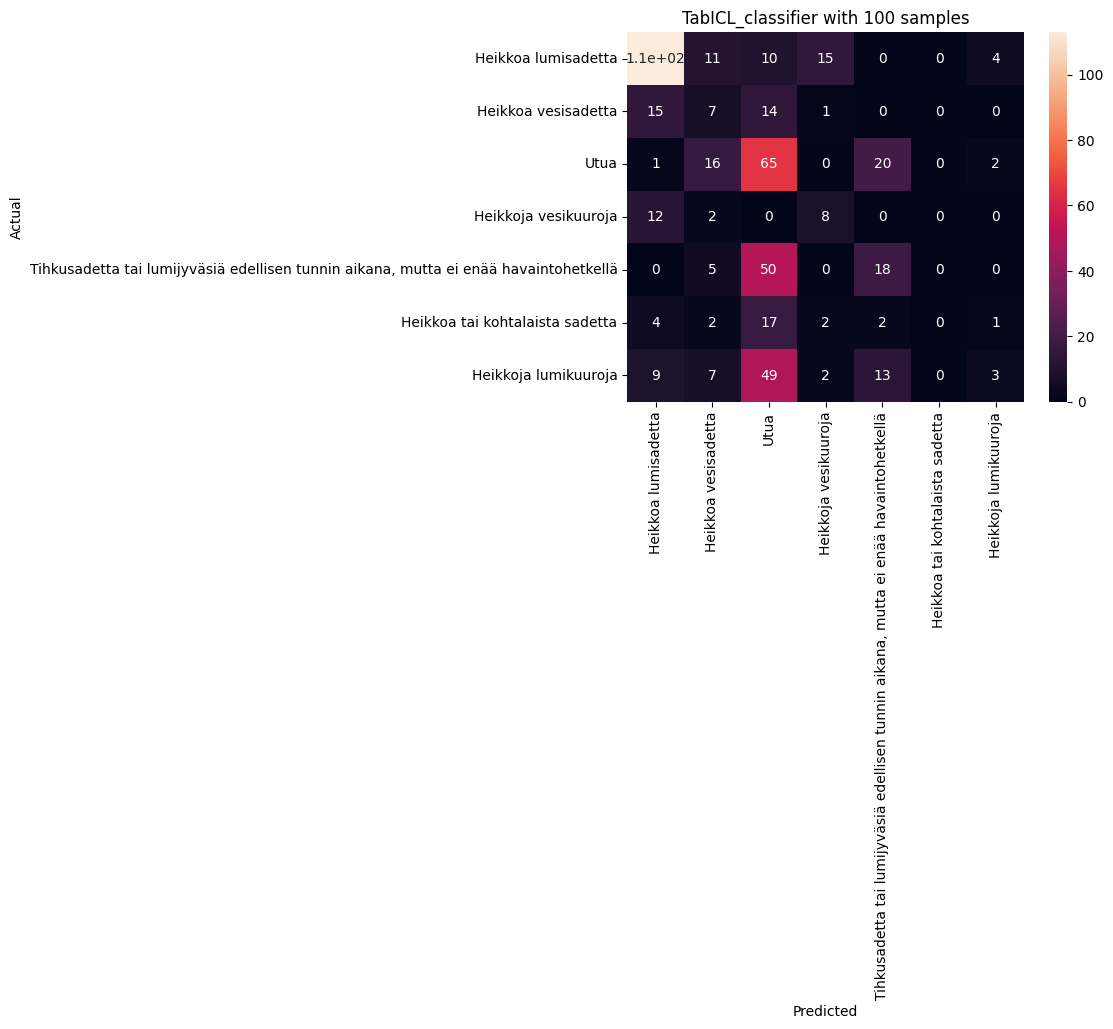

Total runtime for model fitting: 0.6238393783569336 seconds
not_imbalanced_weather_TabICL_classifier with trainingset size 1000, Accuracy: 0.512
Mean accuracy: 0.5025000000000001, Standard deviation: 0.0357246413557925
Macro f1-score: 0.25586932567803883, Macro recall-score: 0.3156324933433367


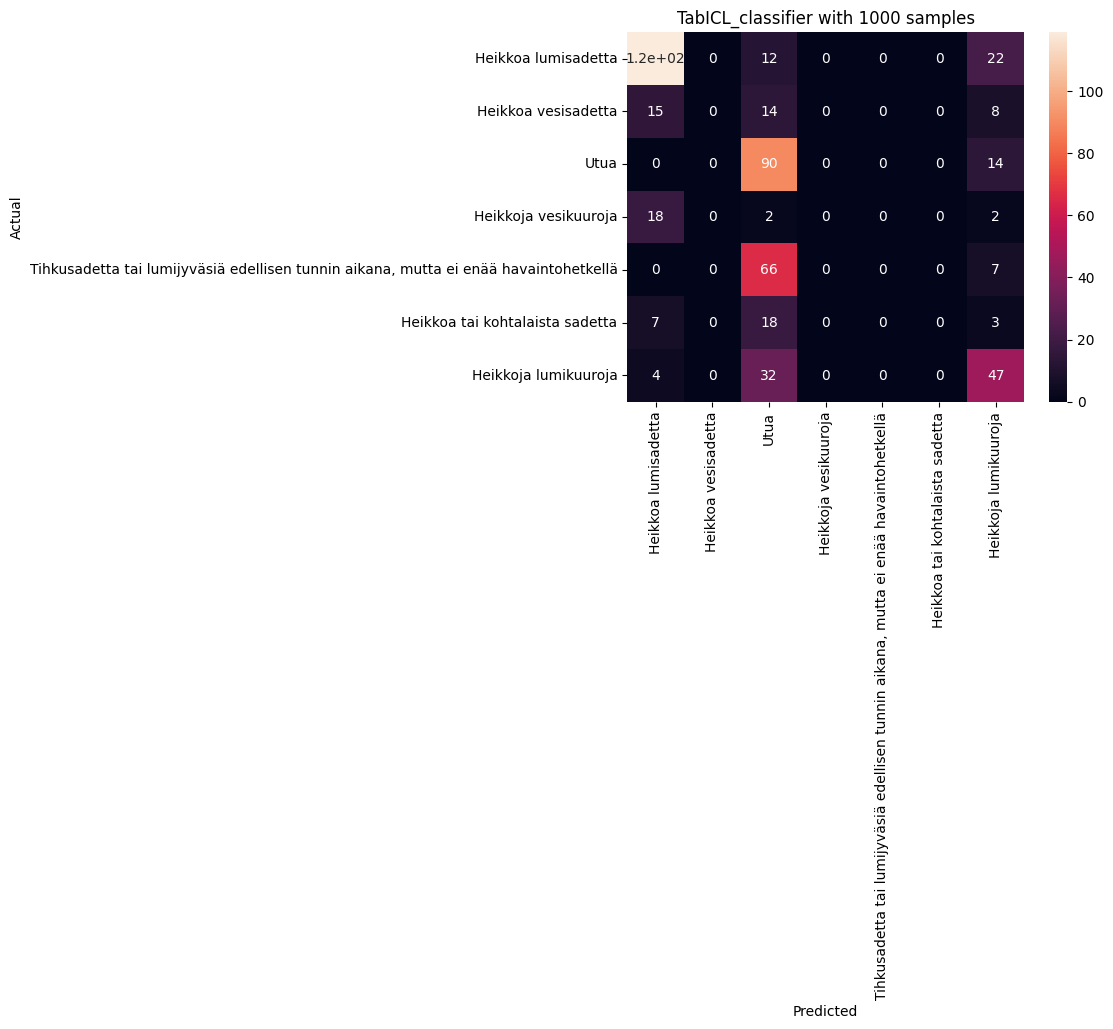

Total runtime for model fitting: 0.5758483409881592 seconds
not_imbalanced_weather_TabICL_classifier with trainingset size 2000, Accuracy: 0.548
Mean accuracy: 0.5322500000000001, Standard deviation: 0.015266384640772051
Macro f1-score: 0.28387181680594853, Macro recall-score: 0.3362964006513223


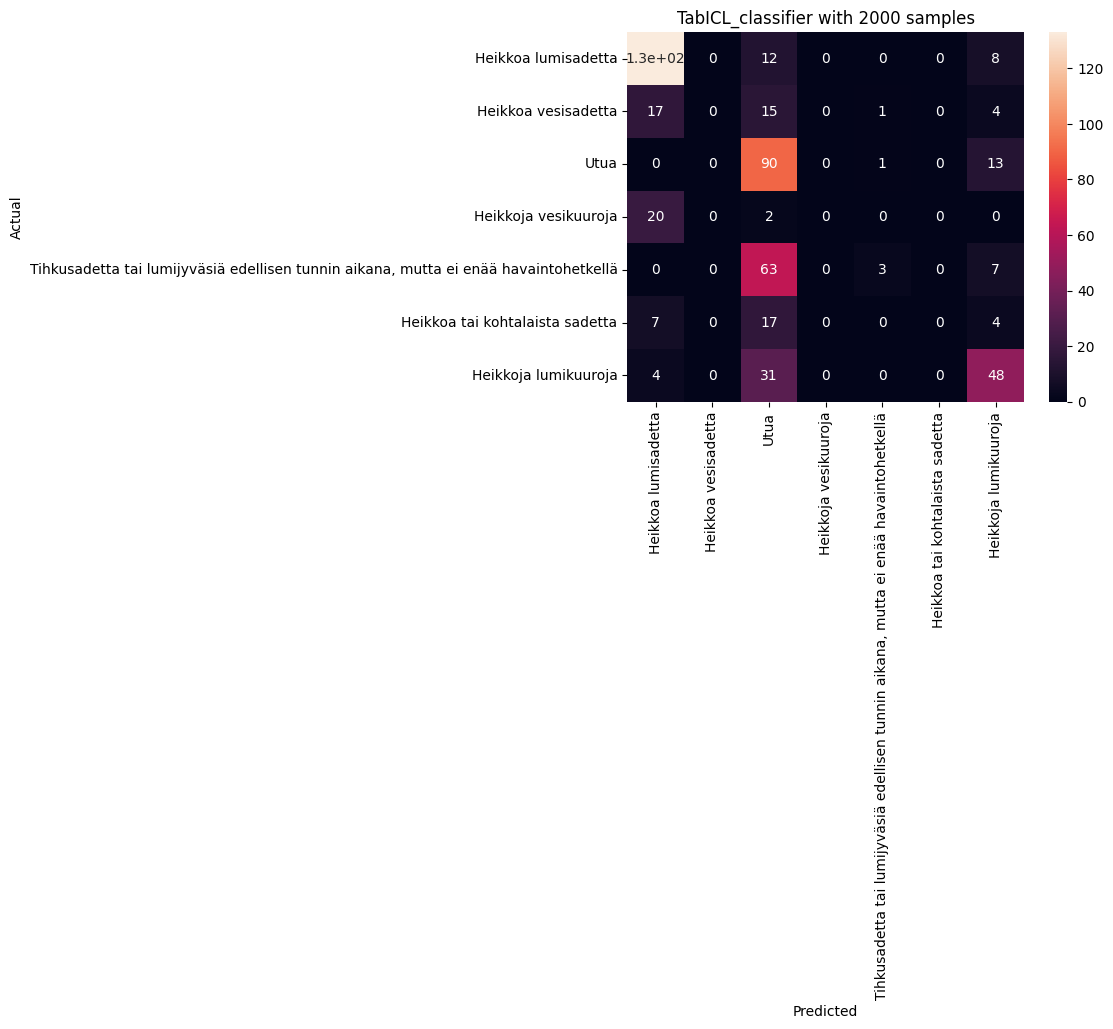

Total runtime for model fitting: 0.6332247257232666 seconds
not_imbalanced_weather_TabICL_classifier with trainingset size 5000, Accuracy: 0.582
Mean accuracy: 0.5746, Standard deviation: 0.01110135126910233
Macro f1-score: 0.32563962737974467, Macro recall-score: 0.3668945030883518


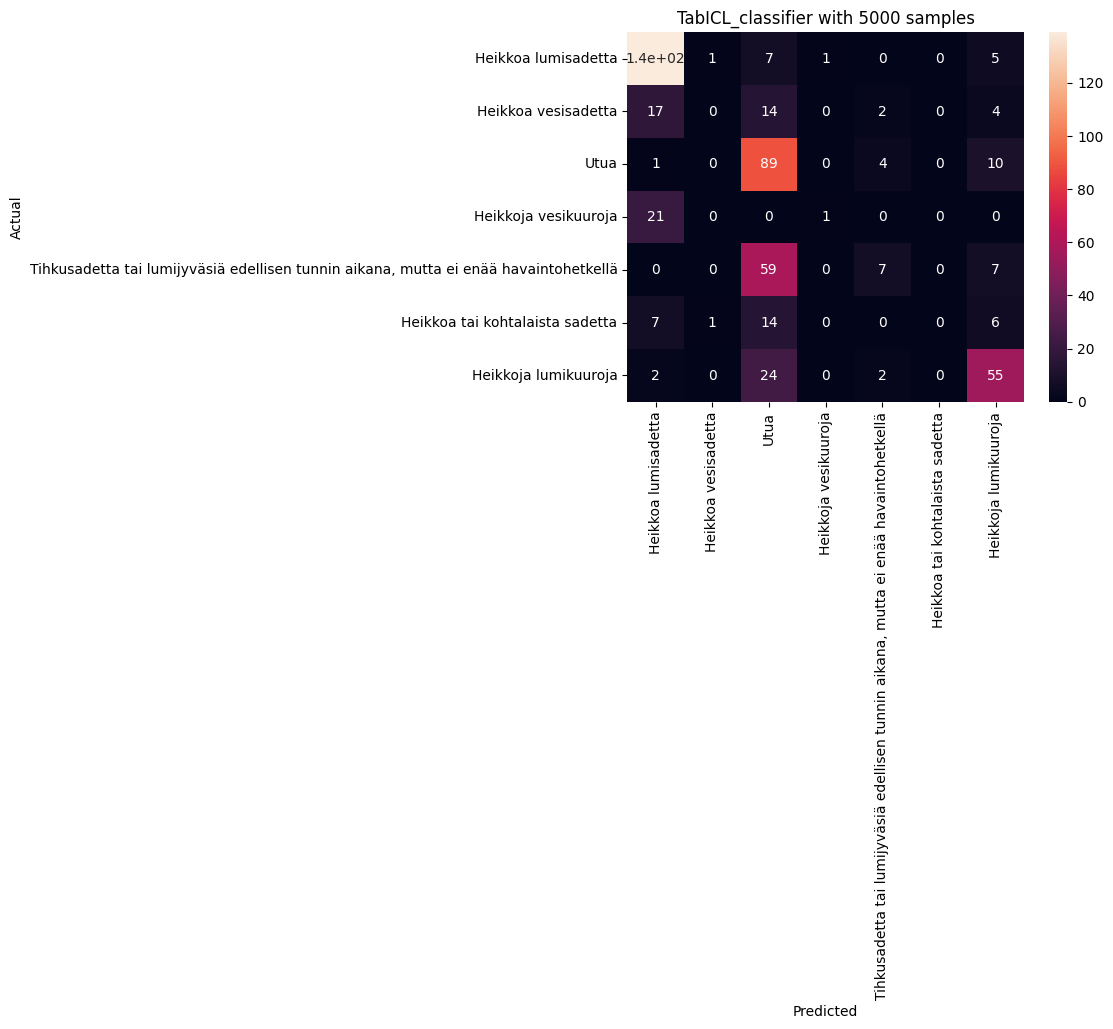

In [98]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [FI_kumpula_train], FI_kumpula_test, [TabICL_classifier], classes_of_interest3, ["not_imbalanced_weather"], ["TabICL_classifier"], rskf, False, False)

Total runtime for model fitting: 0.49591994285583496 seconds
imbalanced_weather_TabICL_classifier with trainingset size 100, Accuracy: 0.186
Mean accuracy: 0.945, Standard deviation: 0.026925824035672508
Macro f1-score: 0.18043837328690682, Macro recall-score: 0.4112249253094324


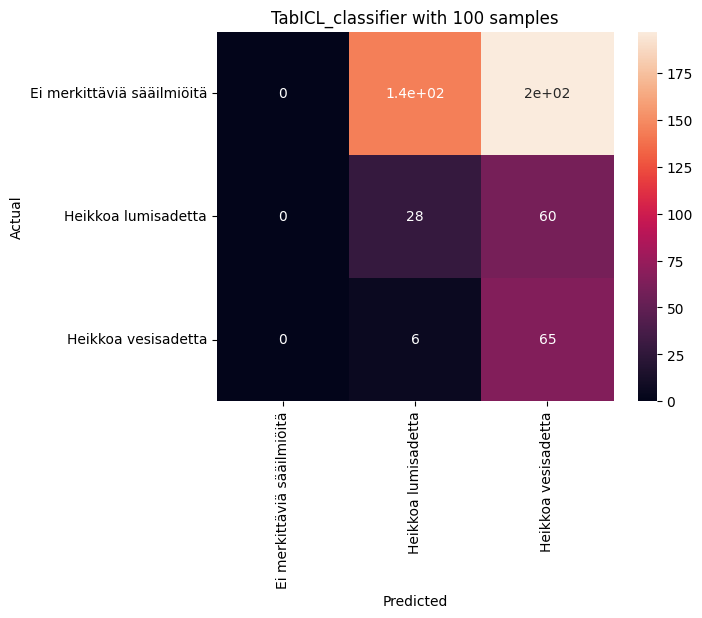

Total runtime for model fitting: 0.5214648246765137 seconds
imbalanced_weather_TabICL_classifier with trainingset size 1000, Accuracy: 0.866
Mean accuracy: 0.9045, Standard deviation: 0.0068738635424337655
Macro f1-score: 0.7641289793916042, Macro recall-score: 0.7637902193217959


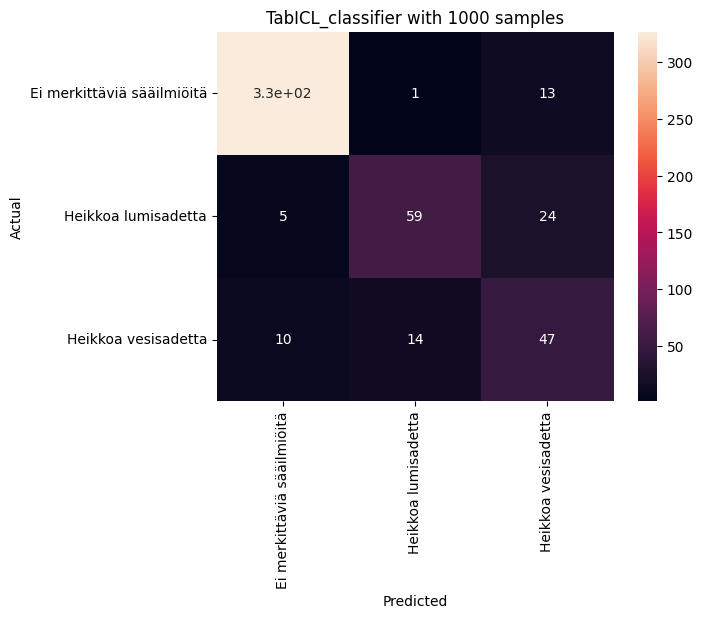

Total runtime for model fitting: 0.5297164916992188 seconds
imbalanced_weather_TabICL_classifier with trainingset size 2000, Accuracy: 0.88
Mean accuracy: 0.9235, Standard deviation: 0.011629703349613
Macro f1-score: 0.781371869033075, Macro recall-score: 0.7808778378973744


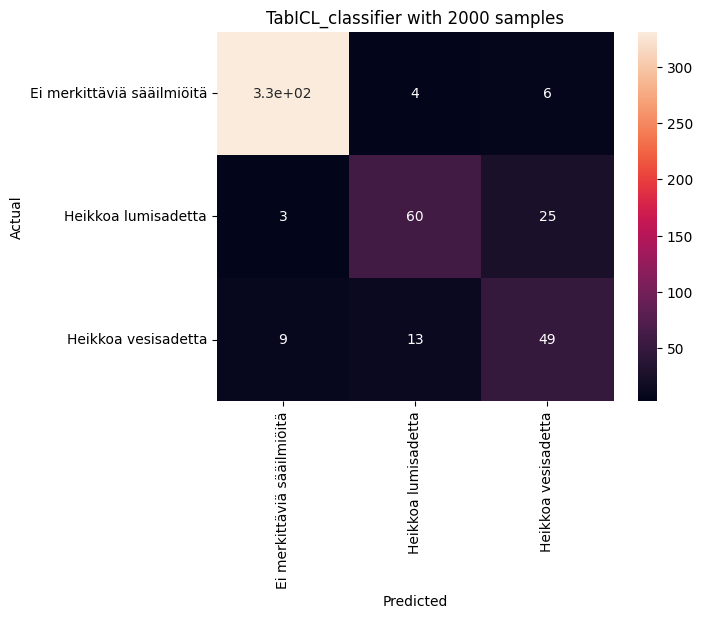

Total runtime for model fitting: 0.5665140151977539 seconds
imbalanced_weather_TabICL_classifier with trainingset size 5000, Accuracy: 0.874
Mean accuracy: 0.9401999999999999, Standard deviation: 0.006584831053261687
Macro f1-score: 0.7708108694604134, Macro recall-score: 0.7686072446408657


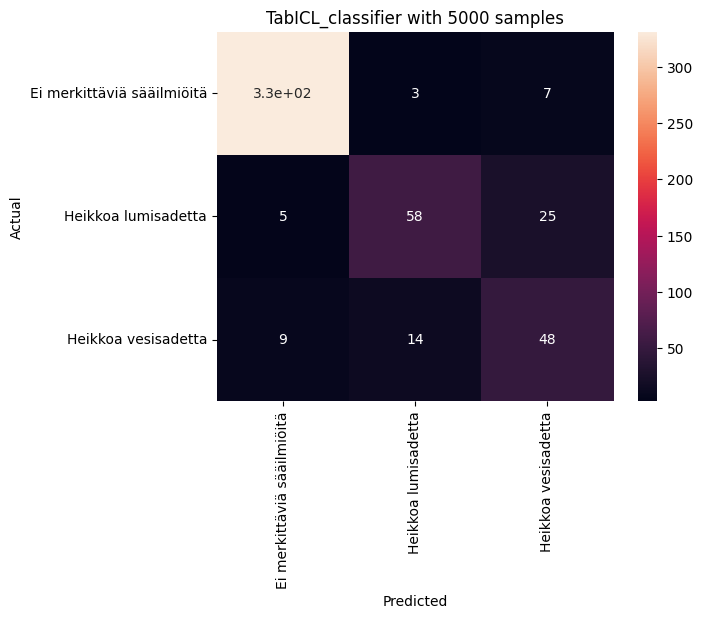

In [99]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [clf_imbalanced_weather_train], clf_imbalanced_weather_test, [TabICL_classifier], classes_of_interest7, ["imbalanced_weather"], ["TabICL_classifier"], rskf, False, False)

#### ConTextTab classifier

In [100]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [FI_kumpula_train], FI_kumpula_test, [ConTextTab_classifier], classes_of_interest3, ["FI_kumpula"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.004110813140869141 seconds
FI_kumpula_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.606
Mean accuracy: 0.6166, Standard deviation: 0.01570477634352048


In [101]:
clf_model_comparison([100, 1000, 2000, 5000], "Current weather", [EN_kumpula_train], EN_kumpula_test, [ConTextTab_classifier], classes_of_interest4, ["EN_kumpula"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.004147052764892578 seconds
EN_kumpula_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.602
Mean accuracy: 0.6296, Standard deviation: 0.013979985693841047


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0005817413330078125 seconds
not_imbalanced_weather_ConTextTab_classifier with trainingset size 100, Accuracy: 0.478
Mean accuracy: 0.4800000000000001, Standard deviation: 0.06403124237432847
Macro f1-score: 0.3234710432768423, Macro recall-score: 0.33729278946391206


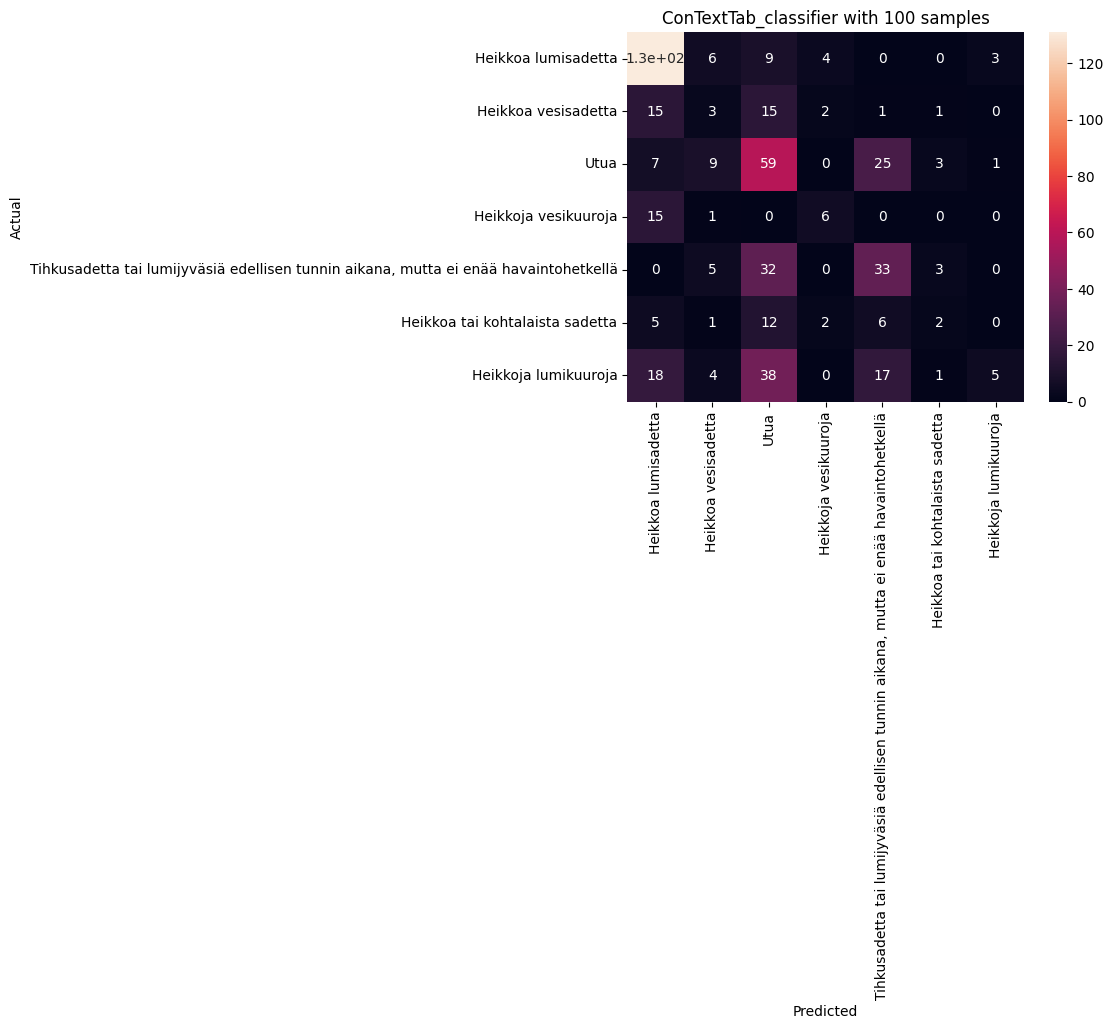

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0012655258178710938 seconds
not_imbalanced_weather_ConTextTab_classifier with trainingset size 1000, Accuracy: 0.576
Mean accuracy: 0.5570000000000002, Standard deviation: 0.016911534525287732
Macro f1-score: 0.40584349709031425, Macro recall-score: 0.40684782182221235


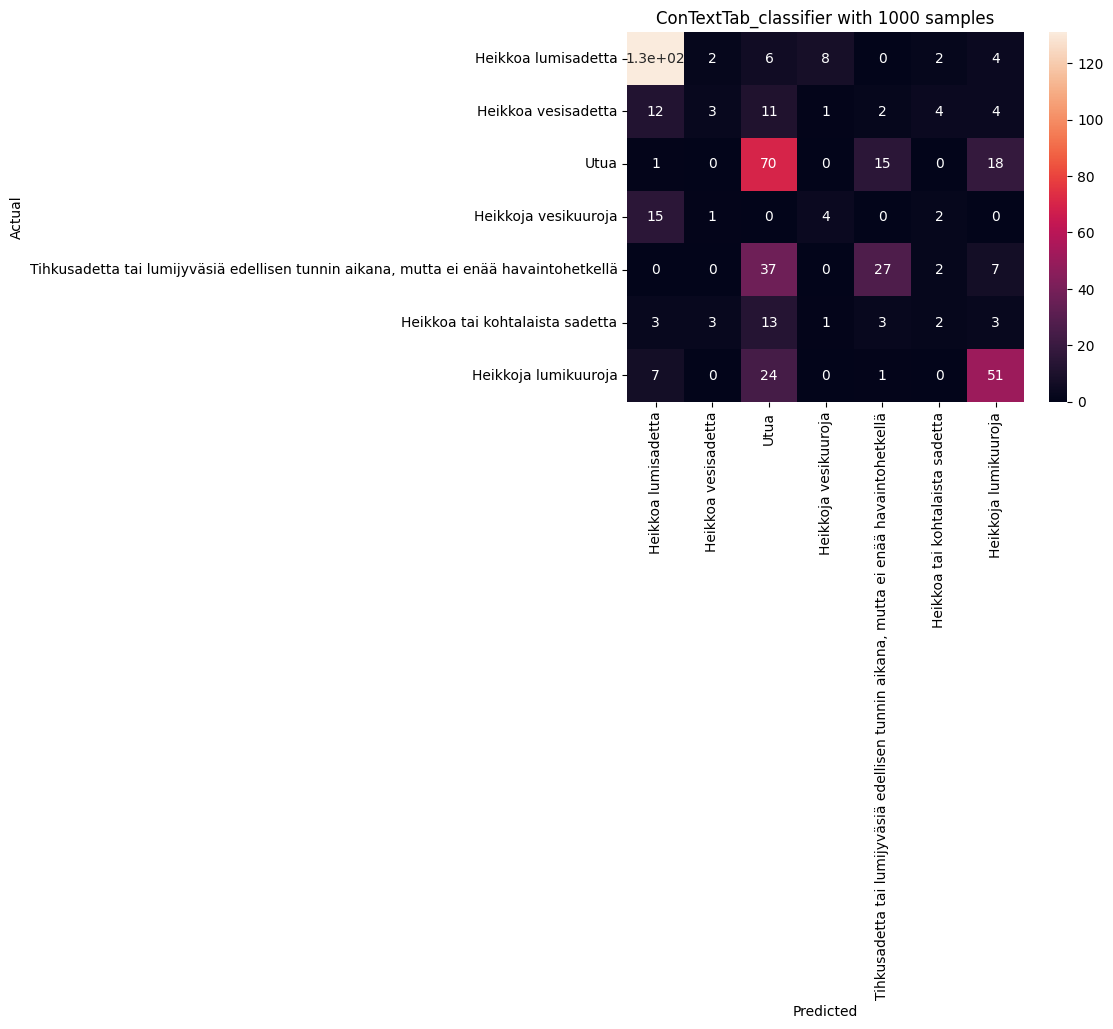

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0017805099487304688 seconds
not_imbalanced_weather_ConTextTab_classifier with trainingset size 2000, Accuracy: 0.564
Mean accuracy: 0.5744999999999999, Standard deviation: 0.021236760581595293
Macro f1-score: 0.41358165855085127, Macro recall-score: 0.4133493248352593


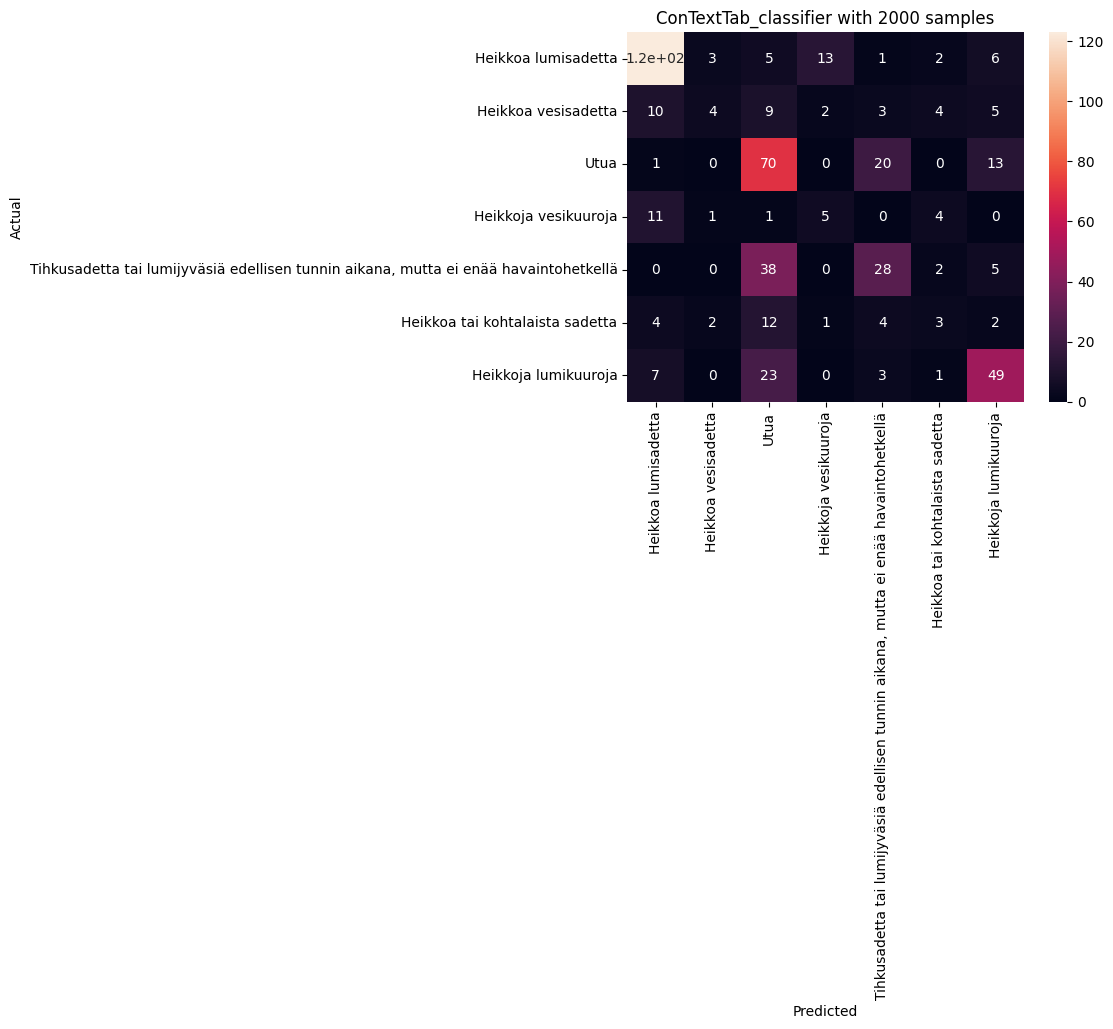

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.003974437713623047 seconds
not_imbalanced_weather_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.606
Mean accuracy: 0.6166, Standard deviation: 0.01570477634352048
Macro f1-score: 0.4505155854828627, Macro recall-score: 0.4418137900855464


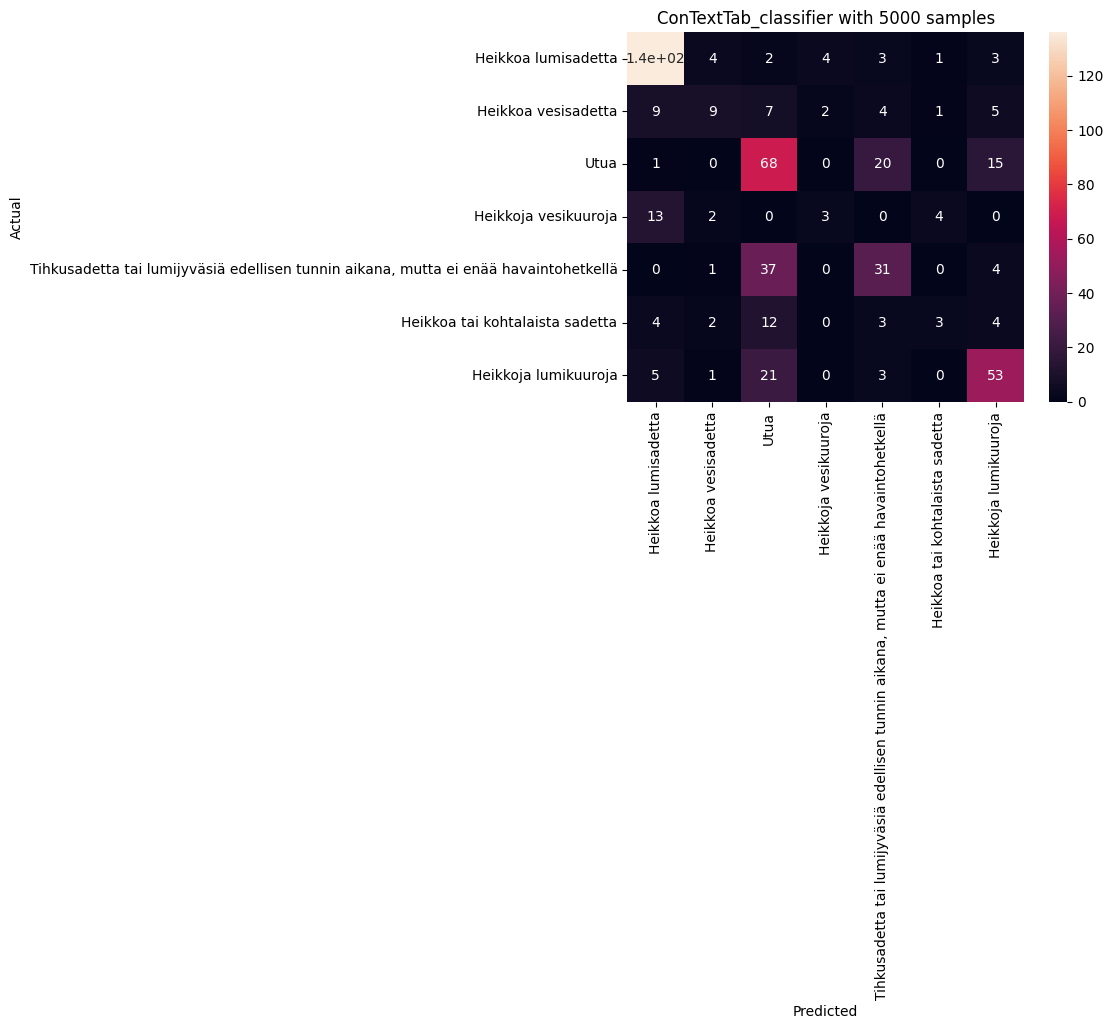

In [102]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [FI_kumpula_train], FI_kumpula_test, [ConTextTab_classifier], classes_of_interest3, ["not_imbalanced_weather"], ["ConTextTab_classifier"], rskf, False, False)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0007426738739013672 seconds
imbalanced_weather_ConTextTab_classifier with trainingset size 100, Accuracy: 0.22
Mean accuracy: 0.93, Standard deviation: 0.04582575694955839
Macro f1-score: 0.2194144953578916, Macro recall-score: 0.4783397353819889


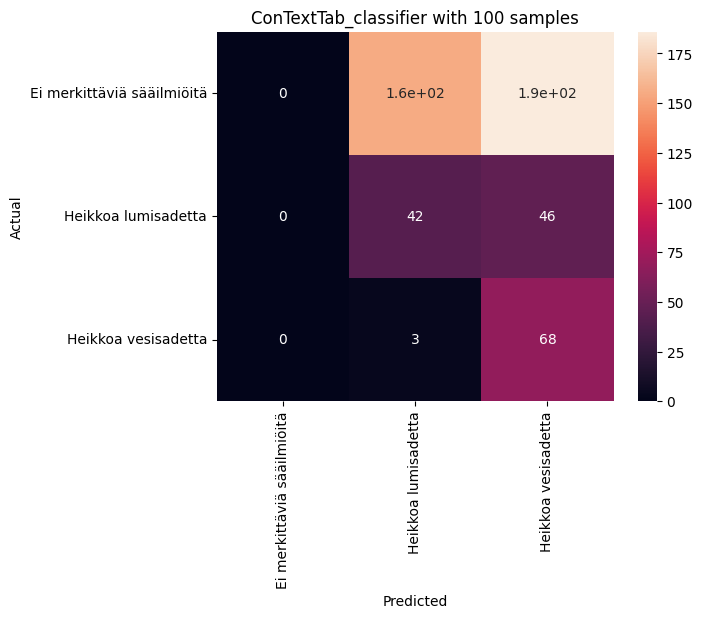

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0012831687927246094 seconds
imbalanced_weather_ConTextTab_classifier with trainingset size 1000, Accuracy: 0.844
Mean accuracy: 0.9014999999999999, Standard deviation: 0.011842719282327021
Macro f1-score: 0.7404385474203368, Macro recall-score: 0.7335439813858714


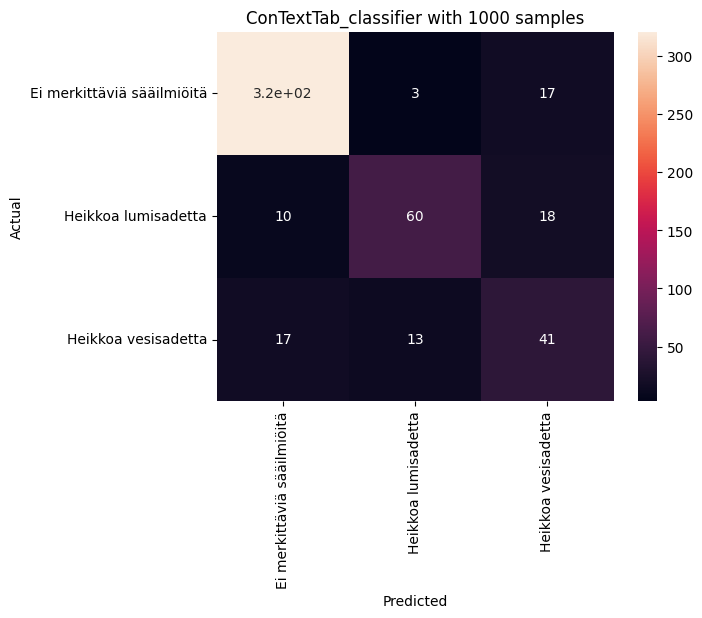

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.0016317367553710938 seconds
imbalanced_weather_ConTextTab_classifier with trainingset size 2000, Accuracy: 0.824
Mean accuracy: 0.9200000000000002, Standard deviation: 0.013601470508735454
Macro f1-score: 0.7207069136762102, Macro recall-score: 0.74208693018325


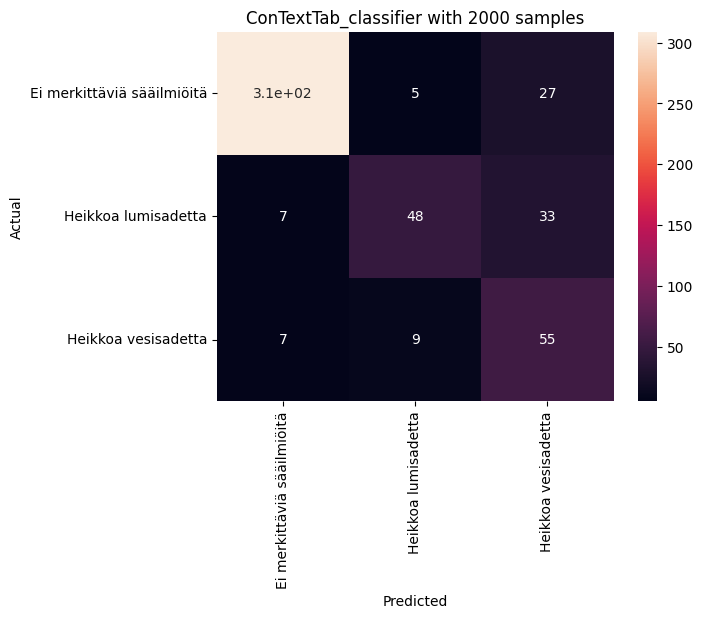

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total runtime for model fitting: 0.004486799240112305 seconds
imbalanced_weather_ConTextTab_classifier with trainingset size 5000, Accuracy: 0.85
Mean accuracy: 0.9361, Standard deviation: 0.007725930364687436
Macro f1-score: 0.7526192227245437, Macro recall-score: 0.765129142400837


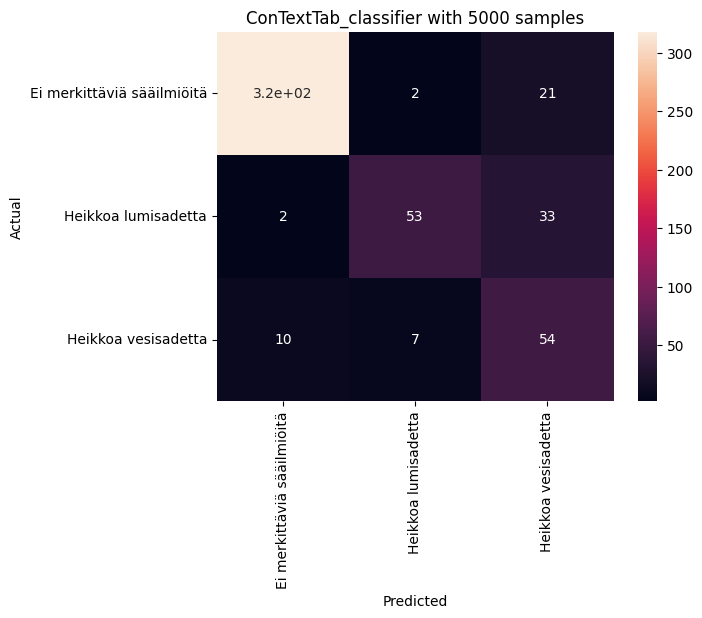

In [103]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [clf_imbalanced_weather_train], clf_imbalanced_weather_test, [ConTextTab_classifier], classes_of_interest7, ["imbalanced_weather"], ["ConTextTab_classifier"], rskf, False, False)

#### XGBoost classifier

In [16]:
int_vals = ["Vuosi", "Kuukausi", "Päivä", "Tunti (Paikallinen aika)", "Pilvisyys (1/8)"]
float_vals = ["Ilman lämpötila keskiarvo (°C)", "Näkyvyys keskiarvo (m)", "Suhteellinen kosteus keskiarvo (%)", "Tuulen suunta keskiarvo (°)", "Keskituulen nopeus keskiarvo (m/s)"]
GBDT_FI_kumpula = modify_df(FI_kumpula, int_vals, float_vals)
GBDT_imbalanced_weather = modify_df(clf_imbalanced_weather , int_vals, float_vals)

int_vals = ["Year",  "Month", "Day", "Hour (Local time)", "Cloudiness (1/8)"]
float_vals = ["Average air temperature (°C)", "Average visibility (m)", "Relative humidity average (%)", "Average wind direction (°)", "Average wind speed (m/s)"]
GBDT_EN_kumpula = modify_df(EN_kumpula, int_vals, float_vals)

In [17]:
GBDT_FI_kumpula_test = GBDT_FI_kumpula.iloc[:500]
GBDT_FI_kumpula_train = GBDT_FI_kumpula.iloc[500:]

GBDT_EN_kumpula_test = GBDT_EN_kumpula.iloc[:500]
GBDT_EN_kumpula_train = GBDT_EN_kumpula.iloc[500:]

GBDT_imbalanced_weather_test = GBDT_imbalanced_weather.iloc[:500]
GBDT_imbalanced_weather_train = GBDT_imbalanced_weather.iloc[500:]

In [107]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [GBDT_FI_kumpula_train], GBDT_FI_kumpula_test, [xgb_classifier], classes_of_interest3, ["FI_kumpula"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.11739587783813477 seconds
FI_kumpula_XGBoost_classifier with trainingset size 100, Accuracy: 0.474
Mean accuracy: 0.45000000000000007, Standard deviation: 0.05916079783099616
Total runtime for model fitting: 0.466278076171875 seconds
FI_kumpula_XGBoost_classifier with trainingset size 1000, Accuracy: 0.582
Mean accuracy: 0.5565, Standard deviation: 0.02202839077191066
Total runtime for model fitting: 0.6493008136749268 seconds
FI_kumpula_XGBoost_classifier with trainingset size 2000, Accuracy: 0.558
Mean accuracy: 0.57725, Standard deviation: 0.017444555024419515
Total runtime for model fitting: 0.8365397453308105 seconds
FI_kumpula_XGBoost_classifier with trainingset size 5000, Accuracy: 0.592
Mean accuracy: 0.6122000000000001, Standard deviation: 0.01401998573465752


In [108]:
clf_model_comparison([100, 1000, 2000, 5000], "Current weather", [GBDT_EN_kumpula_train], GBDT_EN_kumpula_test, [xgb_classifier], classes_of_interest4, ["EN_kumpula"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.11369061470031738 seconds
EN_kumpula_XGBoost_classifier with trainingset size 100, Accuracy: 0.474
Mean accuracy: 0.45000000000000007, Standard deviation: 0.05916079783099616
Total runtime for model fitting: 0.46387434005737305 seconds
EN_kumpula_XGBoost_classifier with trainingset size 1000, Accuracy: 0.582
Mean accuracy: 0.5565, Standard deviation: 0.02202839077191066
Total runtime for model fitting: 0.6273376941680908 seconds
EN_kumpula_XGBoost_classifier with trainingset size 2000, Accuracy: 0.558
Mean accuracy: 0.57725, Standard deviation: 0.017444555024419515
Total runtime for model fitting: 0.8259074687957764 seconds
EN_kumpula_XGBoost_classifier with trainingset size 5000, Accuracy: 0.592
Mean accuracy: 0.6122000000000001, Standard deviation: 0.01401998573465752


Total runtime for model fitting: 0.11329770088195801 seconds
not_imbalanced_weather_XGBoost_classifier with trainingset size 100, Accuracy: 0.474
Mean accuracy: 0.45000000000000007, Standard deviation: 0.05916079783099616
Macro f1-score: 0.3531319712059379, Macro recall-score: 0.3561328791368901


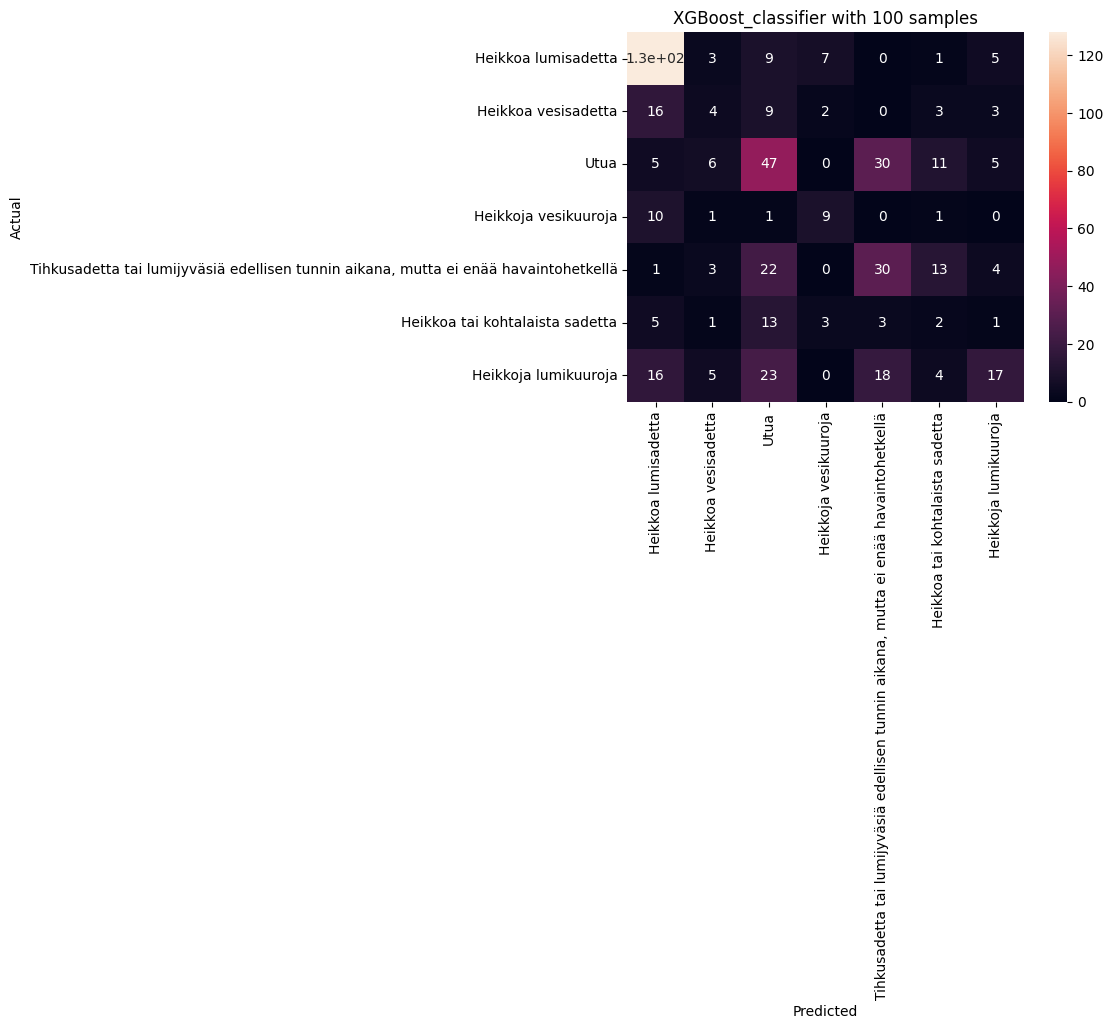

Total runtime for model fitting: 0.5021724700927734 seconds
not_imbalanced_weather_XGBoost_classifier with trainingset size 1000, Accuracy: 0.582
Mean accuracy: 0.5565, Standard deviation: 0.02202839077191066
Macro f1-score: 0.44188288840486034, Macro recall-score: 0.4384263833367951


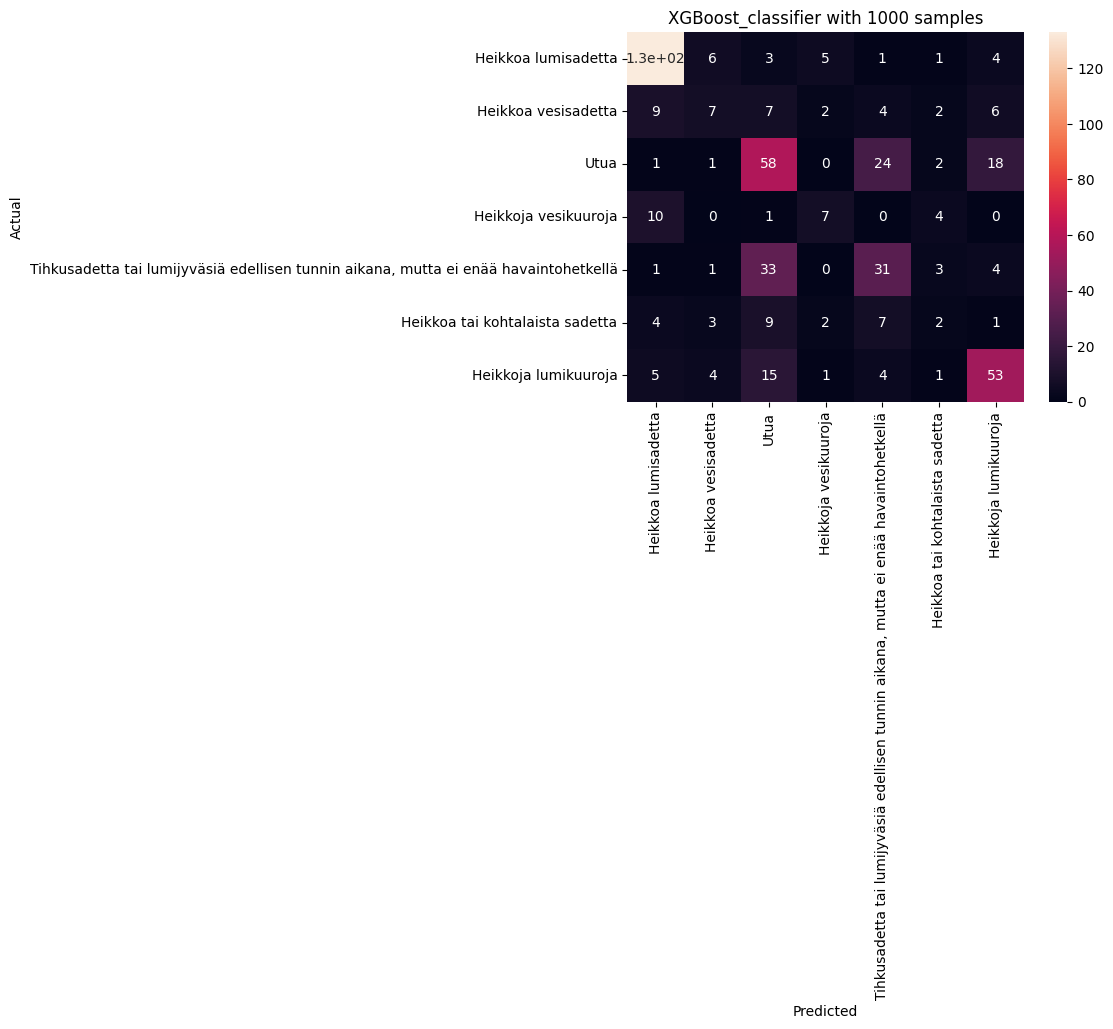

Total runtime for model fitting: 0.6206402778625488 seconds
not_imbalanced_weather_XGBoost_classifier with trainingset size 2000, Accuracy: 0.558
Mean accuracy: 0.57725, Standard deviation: 0.017444555024419515
Macro f1-score: 0.42037106059539486, Macro recall-score: 0.4143572550139419


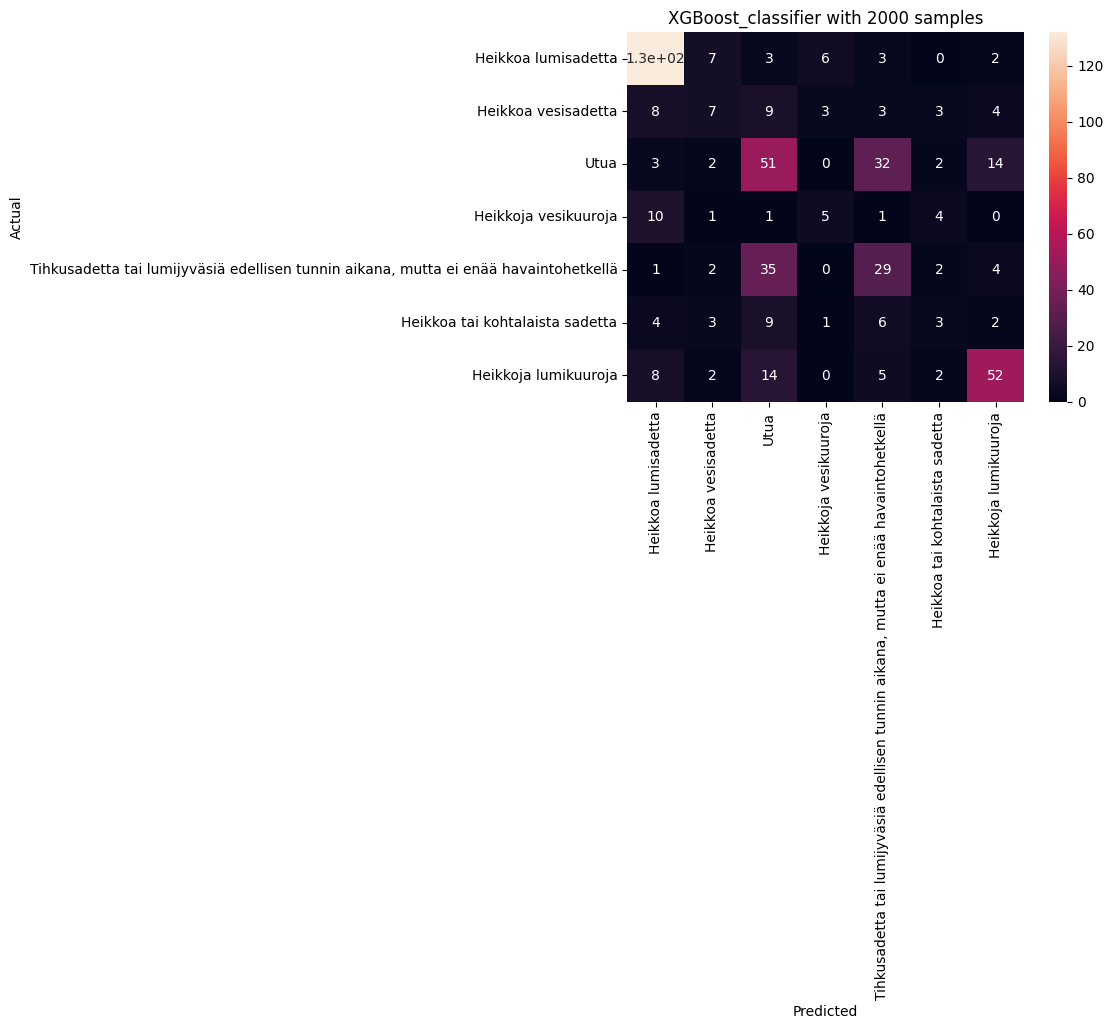

Total runtime for model fitting: 0.8142256736755371 seconds
not_imbalanced_weather_XGBoost_classifier with trainingset size 5000, Accuracy: 0.592
Mean accuracy: 0.6122000000000001, Standard deviation: 0.01401998573465752
Macro f1-score: 0.45849037844168145, Macro recall-score: 0.45264629197413403


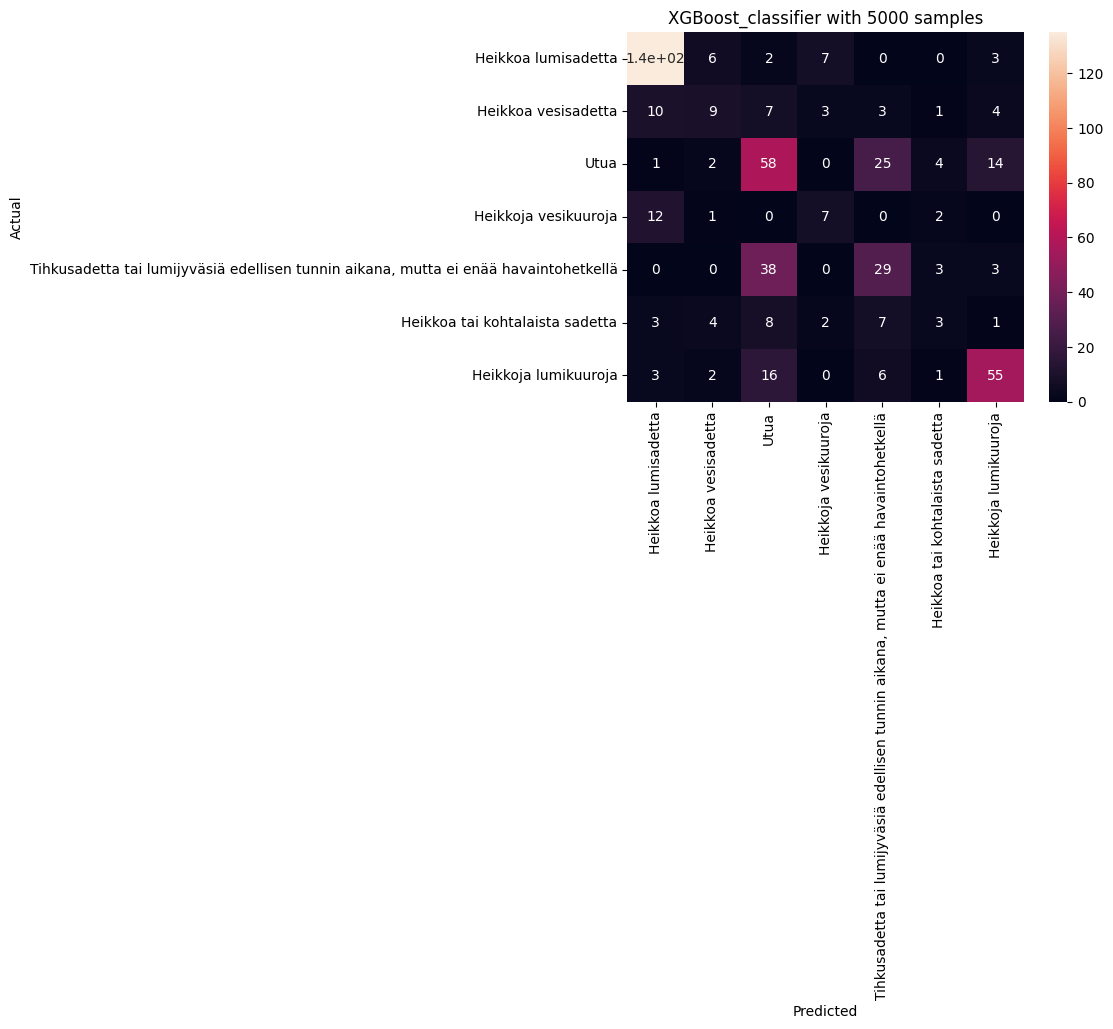

In [109]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [GBDT_FI_kumpula_train], GBDT_FI_kumpula_test, [xgb_classifier], classes_of_interest3, ["not_imbalanced_weather"], ["XGBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.03264498710632324 seconds
imbalanced_weather_XGBoost_classifier with trainingset size 100, Accuracy: 0.386
Mean accuracy: 0.9, Standard deviation: 0.022360679774997894
Macro f1-score: 0.26862923185922466, Macro recall-score: 0.3516617790811339


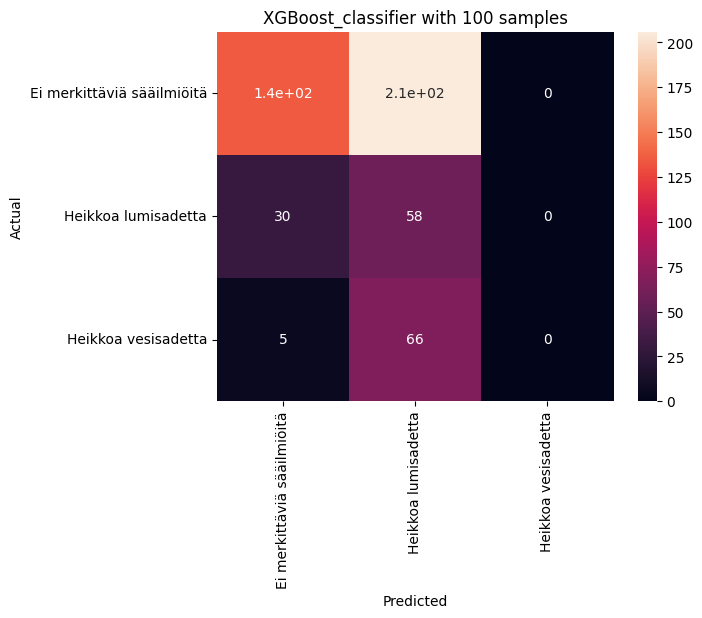

Total runtime for model fitting: 0.2273259162902832 seconds
imbalanced_weather_XGBoost_classifier with trainingset size 1000, Accuracy: 0.834
Mean accuracy: 0.8719999999999999, Standard deviation: 0.012688577540449532
Macro f1-score: 0.7305917484839823, Macro recall-score: 0.7417117563641872


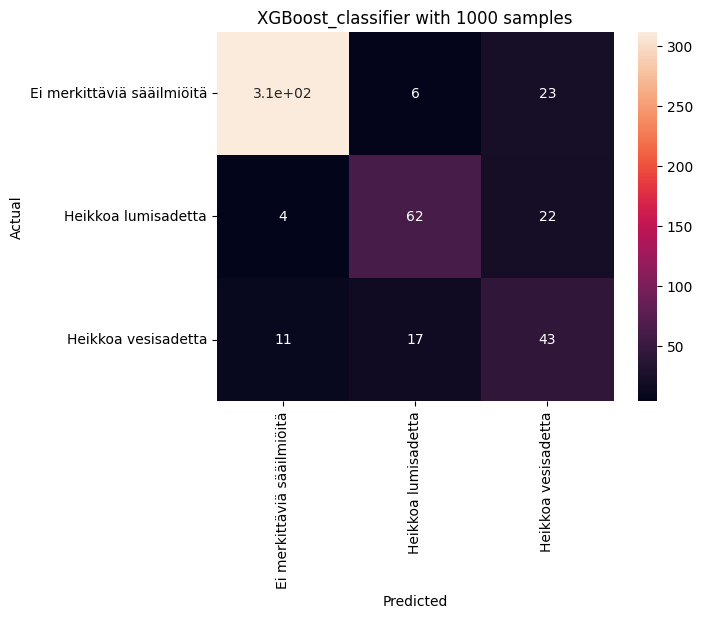

Total runtime for model fitting: 0.24897480010986328 seconds
imbalanced_weather_XGBoost_classifier with trainingset size 2000, Accuracy: 0.866
Mean accuracy: 0.8932499999999999, Standard deviation: 0.012552390210633209
Macro f1-score: 0.7622576316490012, Macro recall-score: 0.7589869618492971


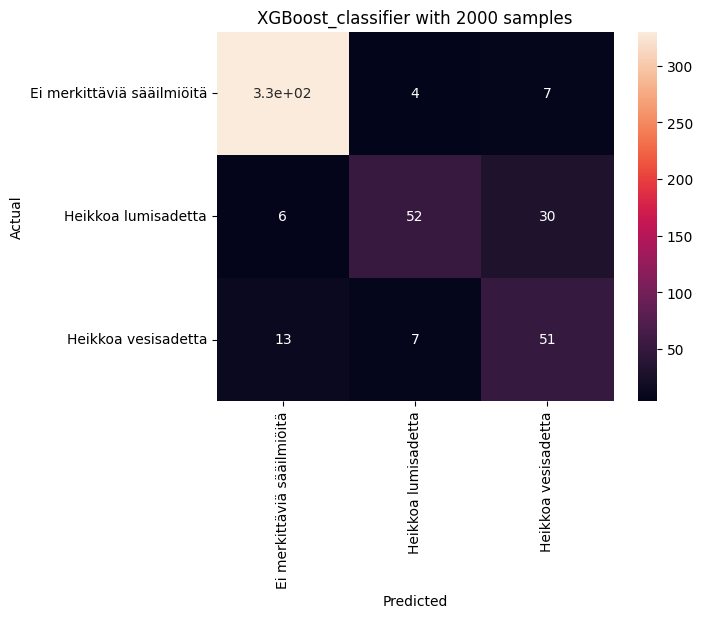

Total runtime for model fitting: 0.3312346935272217 seconds
imbalanced_weather_XGBoost_classifier with trainingset size 5000, Accuracy: 0.848
Mean accuracy: 0.9056000000000001, Standard deviation: 0.006003332407921459
Macro f1-score: 0.7383770330689797, Macro recall-score: 0.7436616276348217


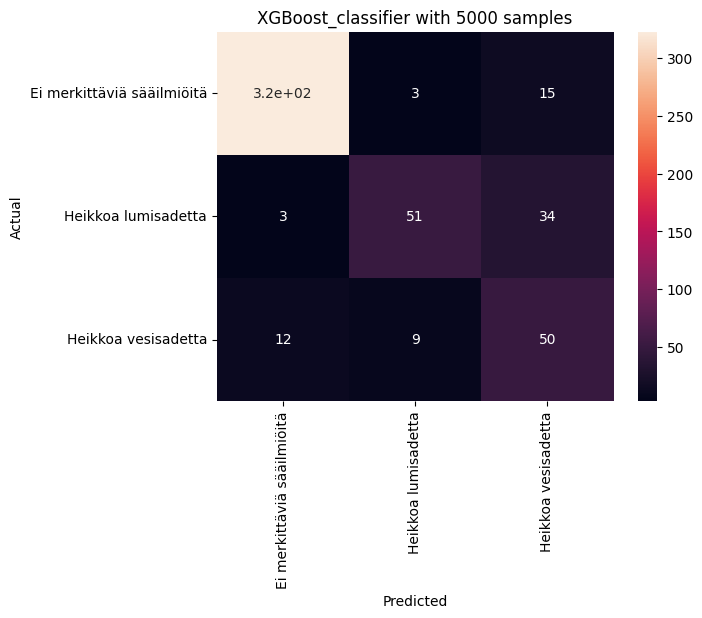

In [18]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [GBDT_imbalanced_weather_train], GBDT_imbalanced_weather_test, [xgb_classifier], classes_of_interest7, ["imbalanced_weather"], ["XGBoost_classifier"], rskf, False, False)

#### CatBoost classifier

In [19]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [GBDT_FI_kumpula_train], GBDT_FI_kumpula_test, [cb_classifier], classes_of_interest3, ["FI_kumpula"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 2.0420968532562256 seconds
FI_kumpula_CatBoost_classifier with trainingset size 100, Accuracy: 0.5
Mean accuracy: 0.51, Standard deviation: 0.0888819441731559
Total runtime for model fitting: 4.840914726257324 seconds
FI_kumpula_CatBoost_classifier with trainingset size 1000, Accuracy: 0.588
Mean accuracy: 0.5615, Standard deviation: 0.023457408211479774
Total runtime for model fitting: 5.531550645828247 seconds
FI_kumpula_CatBoost_classifier with trainingset size 2000, Accuracy: 0.586
Mean accuracy: 0.5850000000000001, Standard deviation: 0.022500000000000006
Total runtime for model fitting: 7.291949987411499 seconds
FI_kumpula_CatBoost_classifier with trainingset size 5000, Accuracy: 0.61
Mean accuracy: 0.6275999999999999, Standard deviation: 0.011757550765359266


In [20]:
clf_model_comparison([100, 1000, 2000, 5000], "Current weather", [GBDT_EN_kumpula_train], GBDT_EN_kumpula_test, [cb_classifier], classes_of_interest4, ["EN_kumpula"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 1.9267759323120117 seconds
EN_kumpula_CatBoost_classifier with trainingset size 100, Accuracy: 0.5
Mean accuracy: 0.51, Standard deviation: 0.0888819441731559
Total runtime for model fitting: 4.762523174285889 seconds
EN_kumpula_CatBoost_classifier with trainingset size 1000, Accuracy: 0.588
Mean accuracy: 0.5615, Standard deviation: 0.023457408211479774
Total runtime for model fitting: 5.3736512660980225 seconds
EN_kumpula_CatBoost_classifier with trainingset size 2000, Accuracy: 0.586
Mean accuracy: 0.5850000000000001, Standard deviation: 0.022500000000000006
Total runtime for model fitting: 8.095513343811035 seconds
EN_kumpula_CatBoost_classifier with trainingset size 5000, Accuracy: 0.61
Mean accuracy: 0.6275999999999999, Standard deviation: 0.011757550765359266


Total runtime for model fitting: 1.937560796737671 seconds
not_imbalanced_weather_CatBoost_classifier with trainingset size 100, Accuracy: 0.5
Mean accuracy: 0.51, Standard deviation: 0.0888819441731559
Macro f1-score: 0.3497552093707161, Macro recall-score: 0.3592252967267703


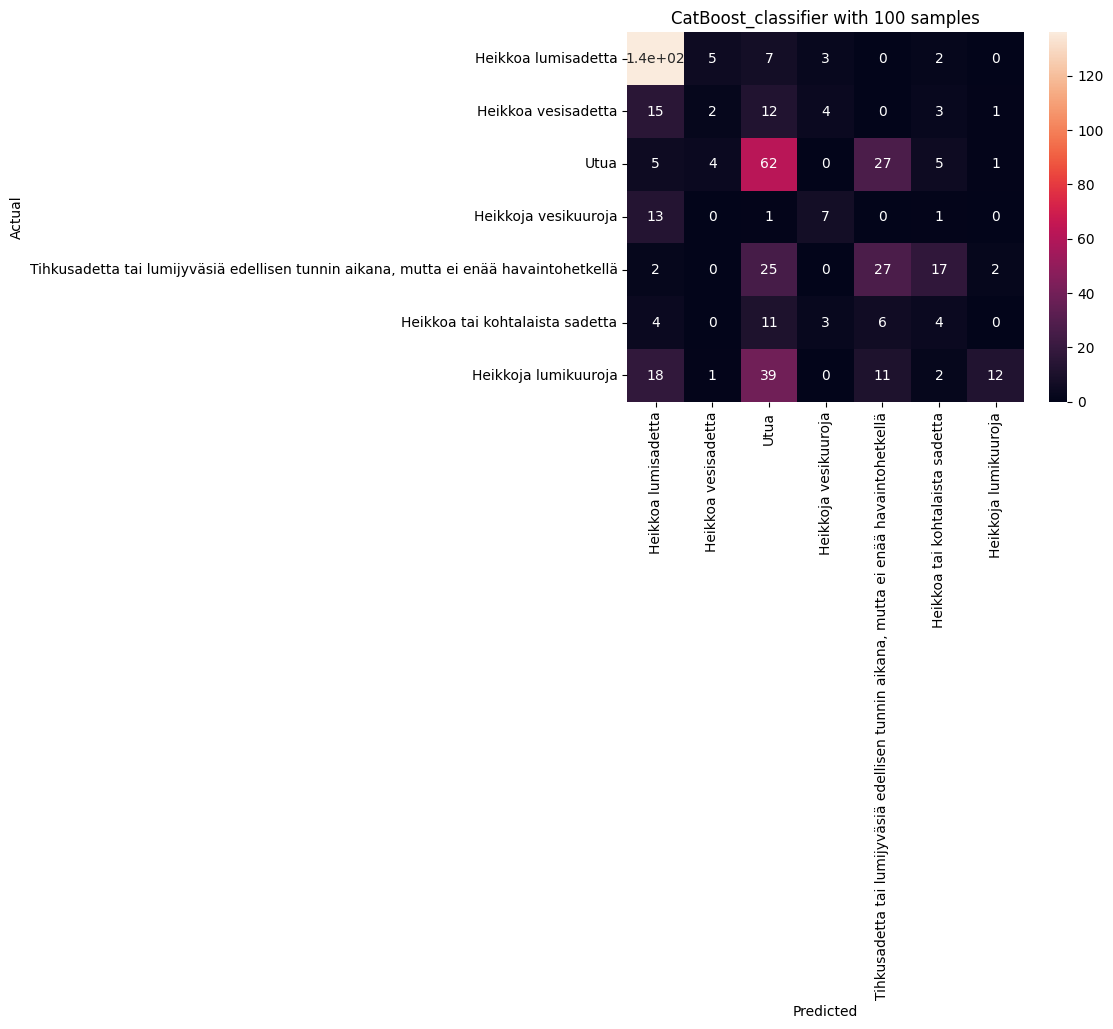

Total runtime for model fitting: 5.012079477310181 seconds
not_imbalanced_weather_CatBoost_classifier with trainingset size 1000, Accuracy: 0.588
Mean accuracy: 0.5615, Standard deviation: 0.023457408211479774
Macro f1-score: 0.42604805833339615, Macro recall-score: 0.4293532558283169


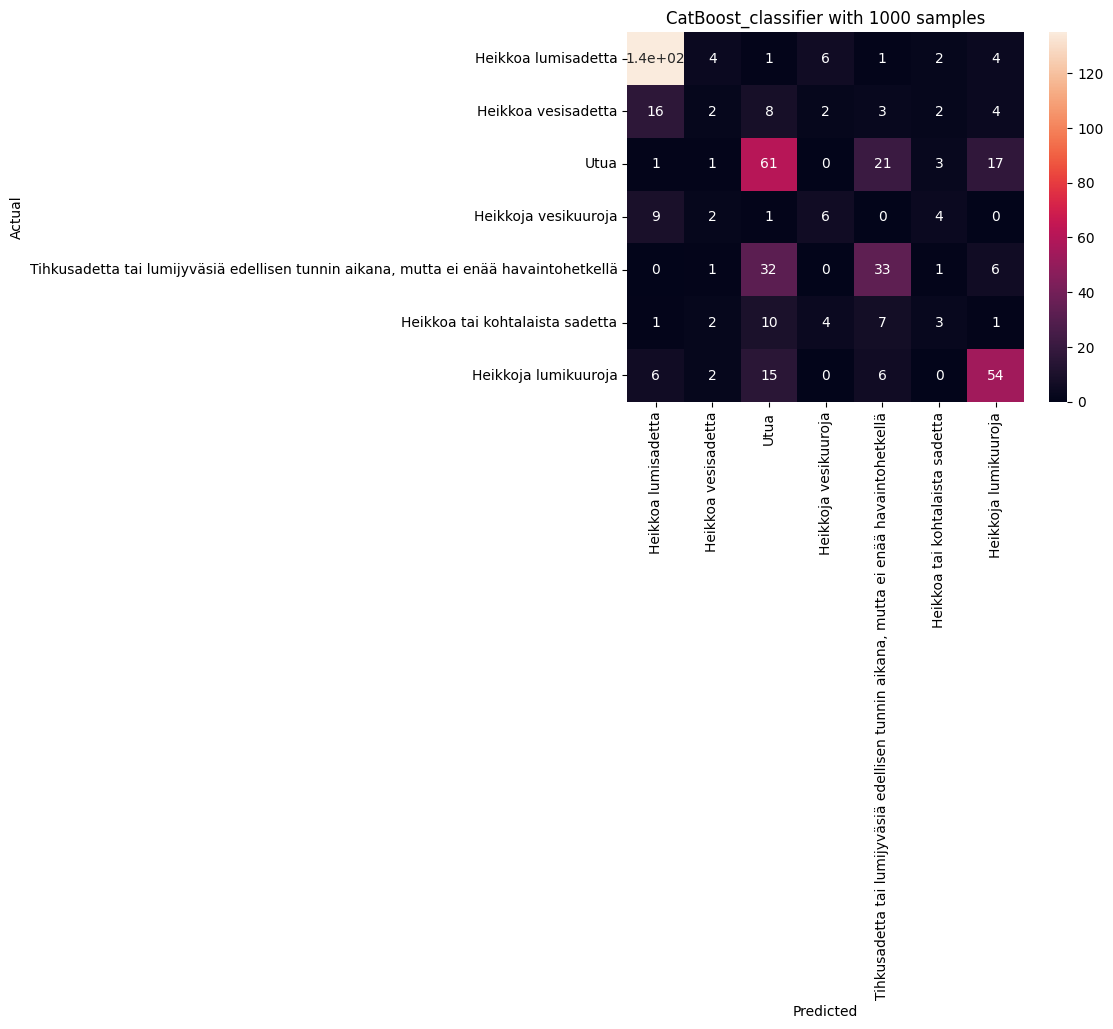

Total runtime for model fitting: 5.630126237869263 seconds
not_imbalanced_weather_CatBoost_classifier with trainingset size 2000, Accuracy: 0.586
Mean accuracy: 0.5850000000000001, Standard deviation: 0.022500000000000006
Macro f1-score: 0.42876556440930774, Macro recall-score: 0.4286953860300198


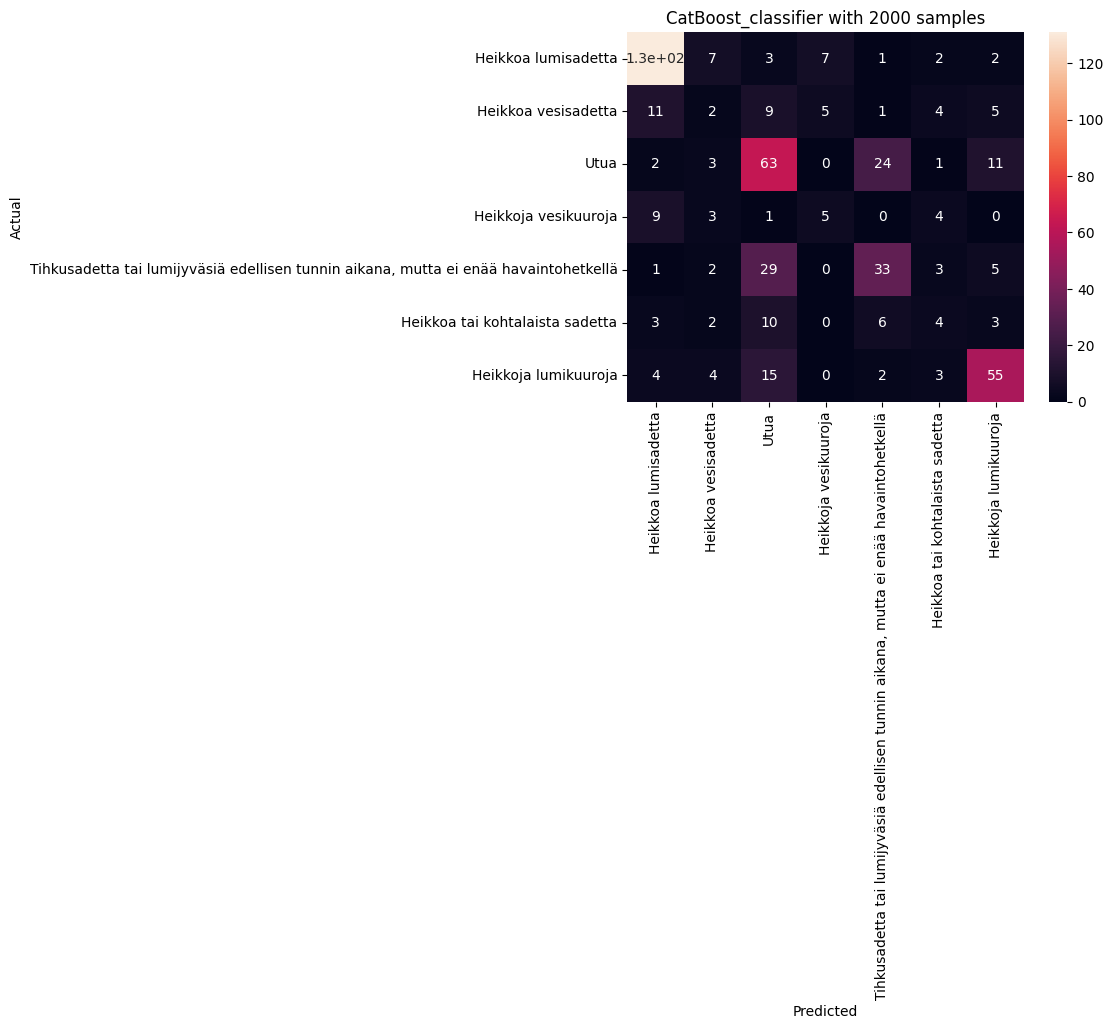

Total runtime for model fitting: 7.398755311965942 seconds
not_imbalanced_weather_CatBoost_classifier with trainingset size 5000, Accuracy: 0.61
Mean accuracy: 0.6275999999999999, Standard deviation: 0.011757550765359266
Macro f1-score: 0.44990022183778616, Macro recall-score: 0.45107640261838267


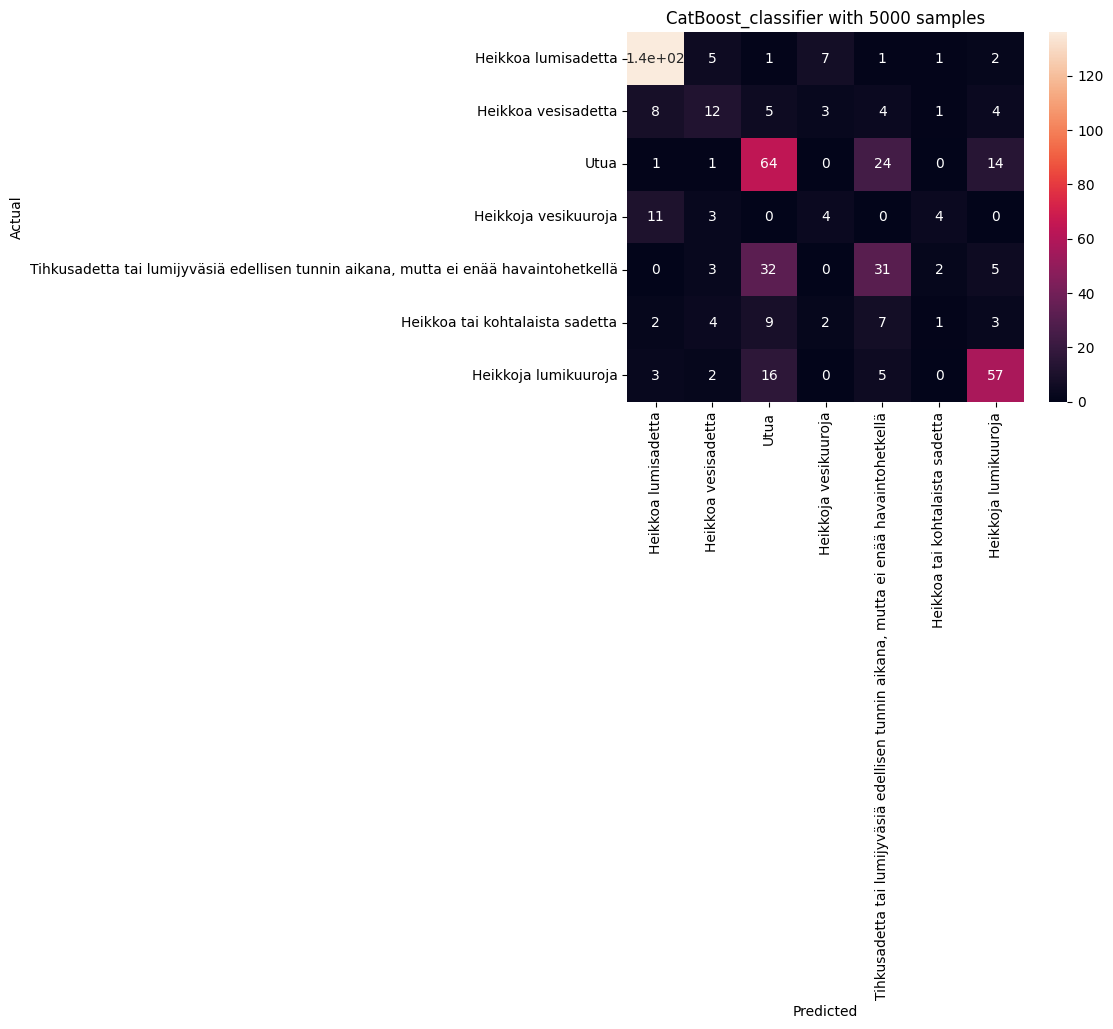

In [21]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [GBDT_FI_kumpula_train], GBDT_FI_kumpula_test, [cb_classifier], classes_of_interest3, ["not_imbalanced_weather"], ["CatBoost_classifier"], rskf, False, False)

Total runtime for model fitting: 0.9915854930877686 seconds
imbalanced_weather_CatBoost_classifier with trainingset size 100, Accuracy: 0.194
Mean accuracy: 0.8949999999999999, Standard deviation: 0.06499999999999999
Macro f1-score: 0.19112619112619111, Macro recall-score: 0.4263764404609475


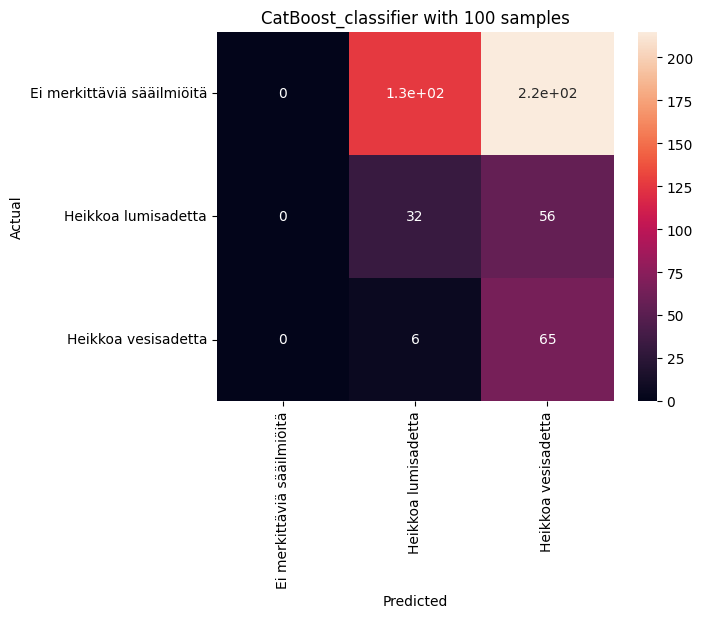

Total runtime for model fitting: 2.5409176349639893 seconds
imbalanced_weather_CatBoost_classifier with trainingset size 1000, Accuracy: 0.794
Mean accuracy: 0.8825000000000001, Standard deviation: 0.013086252328302414
Macro f1-score: 0.6960194120770401, Macro recall-score: 0.7239753280189446


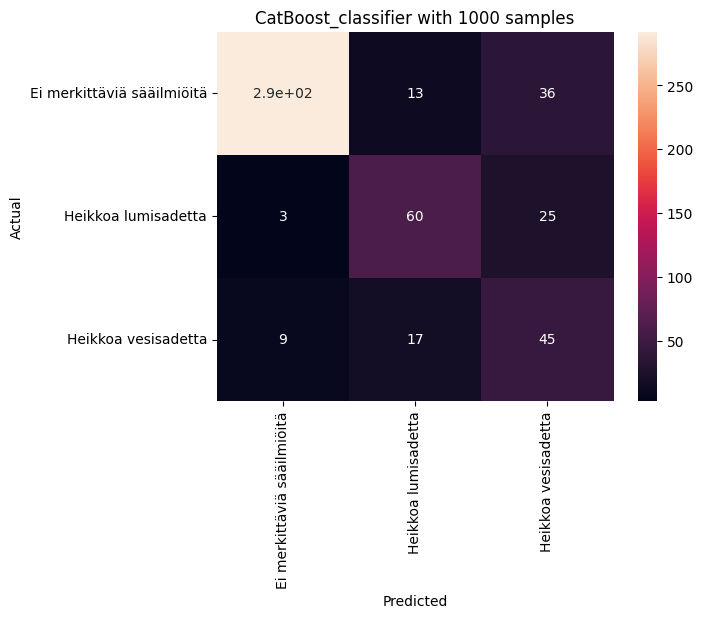

Total runtime for model fitting: 2.8497610092163086 seconds
imbalanced_weather_CatBoost_classifier with trainingset size 2000, Accuracy: 0.826
Mean accuracy: 0.90175, Standard deviation: 0.013183796873435225
Macro f1-score: 0.7199704667481658, Macro recall-score: 0.7356298101413957


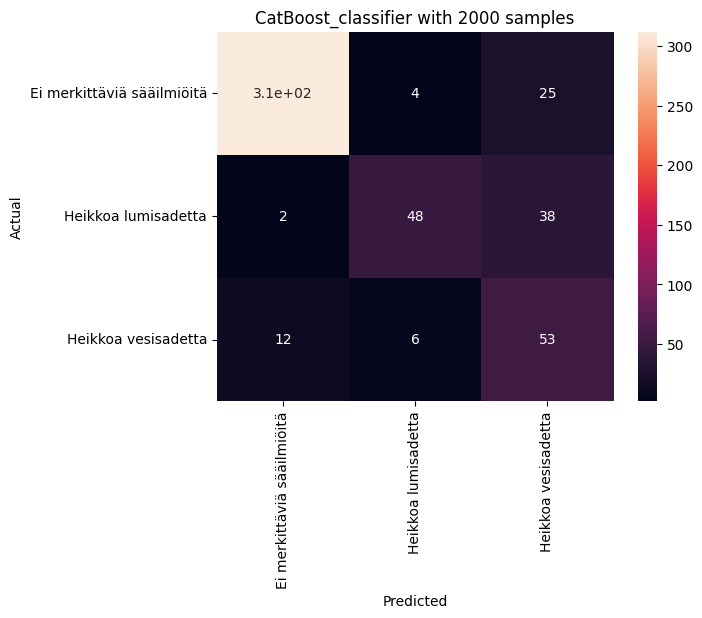

Total runtime for model fitting: 3.759751796722412 seconds
imbalanced_weather_CatBoost_classifier with trainingset size 5000, Accuracy: 0.836
Mean accuracy: 0.9116, Standard deviation: 0.006135144660071192
Macro f1-score: 0.738417021358234, Macro recall-score: 0.7535727561852051


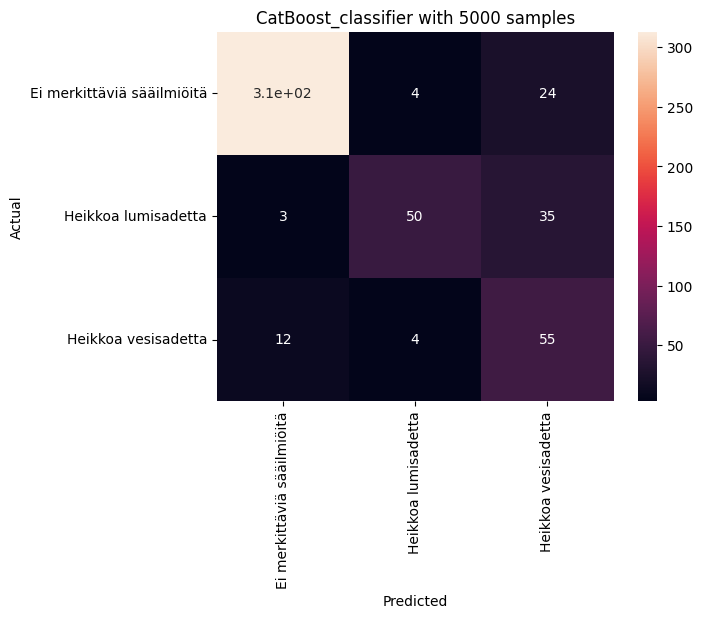

In [22]:
clf_model_comparison([100, 1000, 2000, 5000], "Vallitseva sää", [GBDT_imbalanced_weather_train], GBDT_imbalanced_weather_test, [cb_classifier], classes_of_interest7, ["imbalanced_weather"], ["CatBoost_classifier"], rskf, False, False)

### Weather regression (trainingsets sizes 100, 1000, 2000 and 5000)

#### TabPFN regressor

In [23]:
reg_model_comparison([100, 1000, 2000, 5000], "Ilman lämpötila keskiarvo (°C)", [FI_kumpula_train], FI_kumpula_test, [TabPFN_regressor], ["FI_kumpula"], ["TabPFN_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6976953468064027, Standard deviation: 0.09878138017948264
Total runtime for model fitting: 0.26450347900390625 seconds
FI_kumpula_TabPFN_regressor with training set of 100: R2-score: 0.8176012499933927, mean absolute error: 2.592602925794944, mean squared error: 11.50557041245098
Training set size: 1000, Mean R2 score: 0.8939887103130306, Standard deviation: 0.018414770095827444
Total runtime for model fitting: 0.3640446662902832 seconds
FI_kumpula_TabPFN_regressor with training set of 1000: R2-score: 0.8997175010718262, mean absolute error: 1.8245647617660463, mean squared error: 6.325741555316838
Training set size: 2000, Mean R2 score: 0.9179145912249504, Standard deviation: 0.00477525419762408
Total runtime for model fitting: 0.4527468681335449 seconds
FI_kumpula_TabPFN_regressor with training set of 2000: R2-score: 0.9259929650234849, mean absolute error: 1.50459144986663, mean squared error: 4.66830585137328
Training set size: 5000, Mean R2

In [24]:
reg_model_comparison([100, 1000, 2000, 5000], "Average air temperature (°C)", [EN_kumpula_train], EN_kumpula_test, [TabPFN_regressor], ["EN_kumpula"], ["TabPFN_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6910468740664182, Standard deviation: 0.12706851916341025
Total runtime for model fitting: 0.2597224712371826 seconds
EN_kumpula_TabPFN_regressor with training set of 100: R2-score: 0.8094300915877334, mean absolute error: 2.67741513569206, mean squared error: 12.02100069025825
Training set size: 1000, Mean R2 score: 0.8961228313065226, Standard deviation: 0.016354061791782063
Total runtime for model fitting: 0.34583544731140137 seconds
EN_kumpula_TabPFN_regressor with training set of 1000: R2-score: 0.905040276063464, mean absolute error: 1.782598510078341, mean squared error: 5.9899850742351255
Training set size: 2000, Mean R2 score: 0.9187026785312146, Standard deviation: 0.005317713991097377
Total runtime for model fitting: 0.42176055908203125 seconds
EN_kumpula_TabPFN_regressor with training set of 2000: R2-score: 0.9288097716617525, mean absolute error: 1.4909875180199743, mean squared error: 4.490623892951562
Training set size: 5000, Mean

#### TabICL regressor

In [25]:
reg_model_comparison([100, 1000, 2000, 5000], "Ilman lämpötila keskiarvo (°C)", [FI_kumpula_train], FI_kumpula_test, [TabICL_regressor], ["FI_kumpula"], ["TabICL_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6485021468125746, Standard deviation: 0.19149429348435534
Total runtime for model fitting: 0.6129765510559082 seconds
FI_kumpula_TabICL_regressor with training set of 100: R2-score: 0.7876681734199757, mean absolute error: 2.8568985671222213, mean squared error: 13.393725458273723
Training set size: 1000, Mean R2 score: 0.8939105204397274, Standard deviation: 0.014939468518952451
Total runtime for model fitting: 0.6313056945800781 seconds
FI_kumpula_TabICL_regressor with training set of 1000: R2-score: 0.8903707602759254, mean absolute error: 1.9318570237189534, mean squared error: 6.915326650336783
Training set size: 2000, Mean R2 score: 0.8984269801952008, Standard deviation: 0.005912646073501853
Total runtime for model fitting: 0.6702446937561035 seconds
FI_kumpula_TabICL_regressor with training set of 2000: R2-score: 0.9008670231296569, mean absolute error: 1.7105008578561247, mean squared error: 6.25323060347886
Training set size: 5000, Mea

In [26]:
reg_model_comparison([100, 1000, 2000, 5000], "Average air temperature (°C)", [EN_kumpula_train], EN_kumpula_test, [TabICL_regressor], ["EN_kumpula"], ["TabICL_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6495793365501095, Standard deviation: 0.1796045861673977
Total runtime for model fitting: 0.5937099456787109 seconds
EN_kumpula_TabICL_regressor with training set of 100: R2-score: 0.7917605627318082, mean absolute error: 2.8320010630905625, mean squared error: 13.135580743023509
Training set size: 1000, Mean R2 score: 0.8916469227427258, Standard deviation: 0.015159833783382681
Total runtime for model fitting: 0.6206033229827881 seconds
EN_kumpula_TabICL_regressor with training set of 1000: R2-score: 0.888964865411489, mean absolute error: 1.9559528147153555, mean squared error: 7.004009398188351
Training set size: 2000, Mean R2 score: 0.8979021029040174, Standard deviation: 0.006539859482746743
Total runtime for model fitting: 0.6693079471588135 seconds
EN_kumpula_TabICL_regressor with training set of 2000: R2-score: 0.9018347655064252, mean absolute error: 1.715231627306342, mean squared error: 6.192186171668793
Training set size: 5000, Mean 

#### ConTextTab regressor

In [27]:
reg_model_comparison([100, 1000, 2000, 5000], "Ilman lämpötila keskiarvo (°C)", [FI_kumpula_train], FI_kumpula_test, [ConTextTab_regressor], ["FI_kumpula"], ["ConTextTab_regressor"], k_folds)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 5000, Mean R2 score: 0.9700159767410279, Standard deviation: 0.0014084480475476933
Total runtime for model fitting: 0.0003857612609863281 seconds
FI_kumpula_ConTextTab_regressor with training set of 5000: R2-score: 0.9719418582249326, mean absolute error: 0.900904296875, mean squared error: 1.7698856259918214


In [28]:
reg_model_comparison([100, 1000, 2000, 5000], "Average air temperature (°C)", [EN_kumpula_train], EN_kumpula_test, [ConTextTab_regressor], ["EN_kumpula"], ["ConTextTab_regressor"], k_folds)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 5000, Mean R2 score: 0.9736084527694098, Standard deviation: 0.0013299959053667079
Total runtime for model fitting: 0.0004355907440185547 seconds
EN_kumpula_ConTextTab_regressor with training set of 5000: R2-score: 0.9769338925094995, mean absolute error: 0.81354765625, mean squared error: 1.4549920098876956


#### XGBoost regressor

In [50]:
categories = ["Vallitseva sää"]
int_vals = ["Vuosi", "Kuukausi", "Päivä", "Tunti (Paikallinen aika)", "Pilvisyys (1/8)"]
float_vals = ["Ilman lämpötila keskiarvo (°C)", "Näkyvyys keskiarvo (m)", "Suhteellinen kosteus keskiarvo (%)", "Tuulen suunta keskiarvo (°)", "Keskituulen nopeus keskiarvo (m/s)"]
GBDT_FI_kumpula = modify_df(FI_kumpula, int_vals, float_vals, categories)

categories = ["Current weather"]
int_vals = ["Year",  "Month", "Day", "Hour (Local time)", "Cloudiness (1/8)"]
float_vals = ["Average air temperature (°C)", "Average visibility (m)", "Relative humidity average (%)", "Average wind direction (°)", "Average wind speed (m/s)"]
GBDT_EN_kumpula = modify_df(EN_kumpula, int_vals, float_vals, categories)

In [51]:
GBDT_FI_kumpula_test = GBDT_FI_kumpula.iloc[:500]
GBDT_FI_kumpula_train = GBDT_FI_kumpula.iloc[500:]

GBDT_EN_kumpula_test = GBDT_EN_kumpula.iloc[:500]
GBDT_EN_kumpula_train = GBDT_EN_kumpula.iloc[500:]

In [31]:
reg_model_comparison([100, 1000, 2000, 5000], "Ilman lämpötila keskiarvo (°C)", [GBDT_FI_kumpula_train], GBDT_FI_kumpula_test, [xgb_regressor], ["FI_kumpula"], ["XGBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6643448429636191, Standard deviation: 0.16591107660739696
Total runtime for model fitting: 0.05600118637084961 seconds
FI_kumpula_XGBoost_regressor with training set of 100: R2-score: 0.7760151280714251, mean absolute error: 2.828317574865371, mean squared error: 14.128790439653125
Training set size: 1000, Mean R2 score: 0.8898190078364939, Standard deviation: 0.02359102937137416
Total runtime for model fitting: 0.1254715919494629 seconds
FI_kumpula_XGBoost_regressor with training set of 1000: R2-score: 0.895543735503277, mean absolute error: 1.8668176249936226, mean squared error: 6.589019421158938
Training set size: 2000, Mean R2 score: 0.9145332312101135, Standard deviation: 0.010940306382955048
Total runtime for model fitting: 0.1404716968536377 seconds
FI_kumpula_XGBoost_regressor with training set of 2000: R2-score: 0.9189919612881475, mean absolute error: 1.6392004437878727, mean squared error: 5.109923688292876
Training set size: 5000, M

In [32]:
reg_model_comparison([100, 1000, 2000, 5000], "Average air temperature (°C)", [GBDT_EN_kumpula_train], GBDT_EN_kumpula_test, [xgb_regressor], ["EN_kumpula"], ["XGBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6643448429636191, Standard deviation: 0.16591107660739696
Total runtime for model fitting: 0.0481572151184082 seconds
EN_kumpula_XGBoost_regressor with training set of 100: R2-score: 0.7760151280714251, mean absolute error: 2.828317574865371, mean squared error: 14.128790439653125
Training set size: 1000, Mean R2 score: 0.8898174934629942, Standard deviation: 0.02359311196910673
Total runtime for model fitting: 0.11753082275390625 seconds
EN_kumpula_XGBoost_regressor with training set of 1000: R2-score: 0.895543735503277, mean absolute error: 1.8668176249936226, mean squared error: 6.589019421158938
Training set size: 2000, Mean R2 score: 0.9145303925806347, Standard deviation: 0.010936792227710912
Total runtime for model fitting: 0.13251447677612305 seconds
EN_kumpula_XGBoost_regressor with training set of 2000: R2-score: 0.9189904561948817, mean absolute error: 1.6395057511761784, mean squared error: 5.11001862839826
Training set size: 5000, M

#### CatBoost regressor

In [33]:
reg_model_comparison([100, 1000, 2000, 5000], "Ilman lämpötila keskiarvo (°C)", [GBDT_FI_kumpula_train], GBDT_FI_kumpula_test, [cb_regressor], ["FI_kumpula"], ["CatBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.6951832573948169, Standard deviation: 0.08856583568902249
Total runtime for model fitting: 0.6004049777984619 seconds
FI_kumpula_CatBoost_regressor with training set of 100: R2-score: 0.8130092876614993, mean absolute error: 2.5390581862474266, mean squared error: 11.79522780286078
Training set size: 1000, Mean R2 score: 0.9090841761303187, Standard deviation: 0.021066658860151553
Total runtime for model fitting: 1.0232677459716797 seconds
FI_kumpula_CatBoost_regressor with training set of 1000: R2-score: 0.9129162507911684, mean absolute error: 1.7314702475913972, mean squared error: 5.493174751834311
Training set size: 2000, Mean R2 score: 0.9275745014220987, Standard deviation: 0.008089152998098932
Total runtime for model fitting: 1.1927146911621094 seconds
FI_kumpula_CatBoost_regressor with training set of 2000: R2-score: 0.9384131329039268, mean absolute error: 1.4574858647932383, mean squared error: 3.8848513810015812
Training set size: 50

In [34]:
reg_model_comparison([100, 1000, 2000, 5000], "Average air temperature (°C)", [GBDT_EN_kumpula_train], GBDT_EN_kumpula_test, [cb_regressor], ["EN_kumpula"], ["CatBoost_regressor"], k_folds)

Training set size: 100, Mean R2 score: 0.7059562889516989, Standard deviation: 0.08064556599634984
Total runtime for model fitting: 0.616671085357666 seconds
EN_kumpula_CatBoost_regressor with training set of 100: R2-score: 0.8106119311793372, mean absolute error: 2.549469300137467, mean squared error: 11.946451173680277
Training set size: 1000, Mean R2 score: 0.9107938605195193, Standard deviation: 0.0193102939761692
Total runtime for model fitting: 1.0600640773773193 seconds
EN_kumpula_CatBoost_regressor with training set of 1000: R2-score: 0.9124841020792152, mean absolute error: 1.7487694082936196, mean squared error: 5.520434354402031
Training set size: 2000, Mean R2 score: 0.9257979856485408, Standard deviation: 0.008094846128685345
Total runtime for model fitting: 1.3125262260437012 seconds
EN_kumpula_CatBoost_regressor with training set of 2000: R2-score: 0.9360578133268882, mean absolute error: 1.4707297438556317, mean squared error: 4.033423096742288
Training set size: 5000, 

## Regression plots

In [35]:
iterations=[]
for n in range(100, 10000, 200):
    iterations.append(n)

In [42]:
data_points = reg_model_comparison2(iterations, "ka_maksettu/paiva", [reg_FI_diagnoses_train, GBDT_reg_FI_diagnoses_train], [reg_FI_diagnoses_test, GBDT_reg_FI_diagnoses_test], [TabPFN_regressor, TabICL_regressor, ConTextTab_regressor, xgb_regressor, cb_regressor], ["FI_diagnoses"], ["TabPFN_regressor", "TabICL_regressor", "ConTextTab_regressor", "XGBoost_regressor", "CatBoost_regressor"], k_folds, False)

Training set size: 100, Mean R2 score: 0.4849504708066747, Standard deviation: 0.2844035502855647
Total runtime for model fitting: 0.26082754135131836 seconds
Training set size: 300, Mean R2 score: 0.5577561537445043, Standard deviation: 0.16247774859859876
Total runtime for model fitting: 0.2906177043914795 seconds
Training set size: 500, Mean R2 score: 0.6073323199109313, Standard deviation: 0.023499750771900148
Total runtime for model fitting: 0.30530786514282227 seconds
Training set size: 700, Mean R2 score: 0.6318525939136759, Standard deviation: 0.06222762701424385
Total runtime for model fitting: 0.314119815826416 seconds
Training set size: 900, Mean R2 score: 0.6771648767036431, Standard deviation: 0.07891558168321629
Total runtime for model fitting: 0.33365535736083984 seconds
Training set size: 1100, Mean R2 score: 0.6593095850000132, Standard deviation: 0.032528123346726785
Total runtime for model fitting: 0.3469059467315674 seconds
Training set size: 1300, Mean R2 score: 0.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 9900, Mean R2 score: 0.6867907479001251, Standard deviation: 0.01557945445571959
Total runtime for model fitting: 0.0005071163177490234 seconds
Training set size: 100, Mean R2 score: 0.2888479162662434, Standard deviation: 0.2656192617661757
Total runtime for model fitting: 0.0856633186340332 seconds
Training set size: 300, Mean R2 score: 0.540973505699096, Standard deviation: 0.11925018688989689
Total runtime for model fitting: 0.13769006729125977 seconds
Training set size: 500, Mean R2 score: 0.4323481908858722, Standard deviation: 0.0906751762147102
Total runtime for model fitting: 0.10934567451477051 seconds
Training set size: 700, Mean R2 score: 0.5369124924575687, Standard deviation: 0.08835008152367153
Total runtime for model fitting: 0.11346650123596191 seconds
Training set size: 900, Mean R2 score: 0.6006978225097352, Standard deviation: 0.08062949615513469
Total runtime for model fitting: 0.11871647834777832 seconds
Training set size: 1100, Mean R2 score: 0

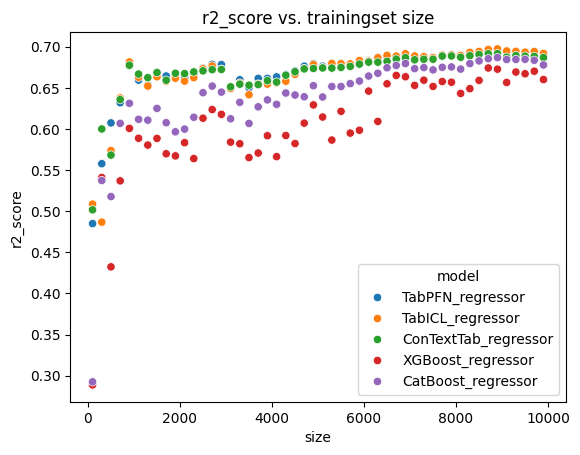

In [43]:
create_scatterplot(data_points,"FI_diagnoses")

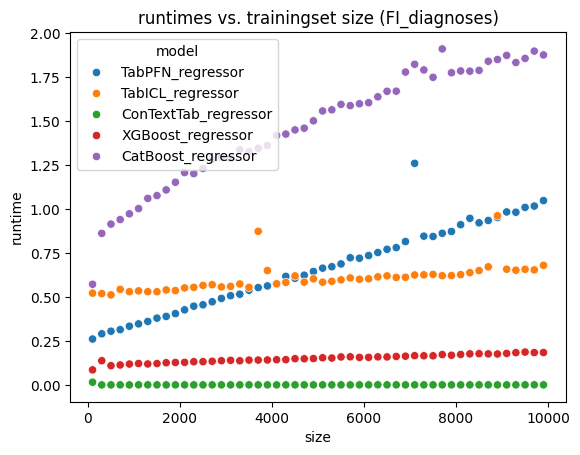

In [44]:
create_scatterplot_runtimes(data_points,"FI_diagnoses")

Training set size: 100, Mean R2 score: 0.530017660696134, Standard deviation: 0.13635432120698718
Total runtime for model fitting: 0.24503612518310547 seconds
Training set size: 300, Mean R2 score: 0.7284066858449583, Standard deviation: 0.06095143832979016
Total runtime for model fitting: 0.2718064785003662 seconds
Training set size: 500, Mean R2 score: 0.6791240570810178, Standard deviation: 0.1086778849937198
Total runtime for model fitting: 0.2800564765930176 seconds
Training set size: 700, Mean R2 score: 0.6132474121032964, Standard deviation: 0.13270364384496033
Total runtime for model fitting: 0.3620944023132324 seconds
Training set size: 900, Mean R2 score: 0.6658674605189553, Standard deviation: 0.02727327185552586
Total runtime for model fitting: 0.37842774391174316 seconds
Training set size: 1100, Mean R2 score: 0.6775900736677583, Standard deviation: 0.06004298610121168
Total runtime for model fitting: 0.4040994644165039 seconds
Training set size: 1300, Mean R2 score: 0.674

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 9900, Mean R2 score: 0.6667007448907232, Standard deviation: 0.02373225895670053
Total runtime for model fitting: 0.0004425048828125 seconds
Training set size: 100, Mean R2 score: 0.49144372883122445, Standard deviation: 0.26426887408075167
Total runtime for model fitting: 0.8094484806060791 seconds
Training set size: 300, Mean R2 score: 0.634784096095047, Standard deviation: 0.1867934642736409
Total runtime for model fitting: 0.5830826759338379 seconds
Training set size: 500, Mean R2 score: 0.6059935623338444, Standard deviation: 0.09757414675167321
Total runtime for model fitting: 0.5290613174438477 seconds
Training set size: 700, Mean R2 score: 0.4869447361792617, Standard deviation: 0.17696731221126424
Total runtime for model fitting: 0.5354039669036865 seconds
Training set size: 900, Mean R2 score: 0.5688443537806591, Standard deviation: 0.08357319803372909
Total runtime for model fitting: 0.5603086948394775 seconds
Training set size: 1100, Mean R2 score: 0.6282

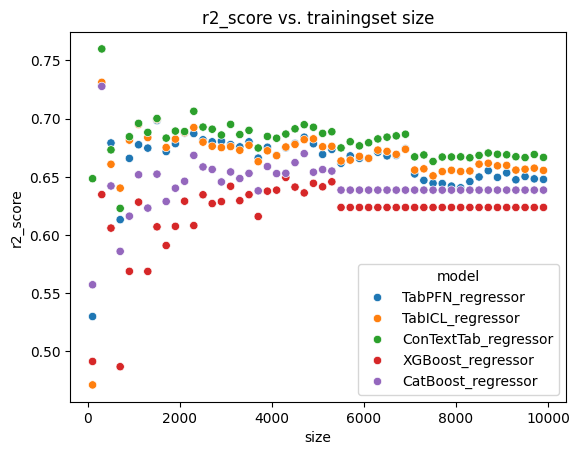

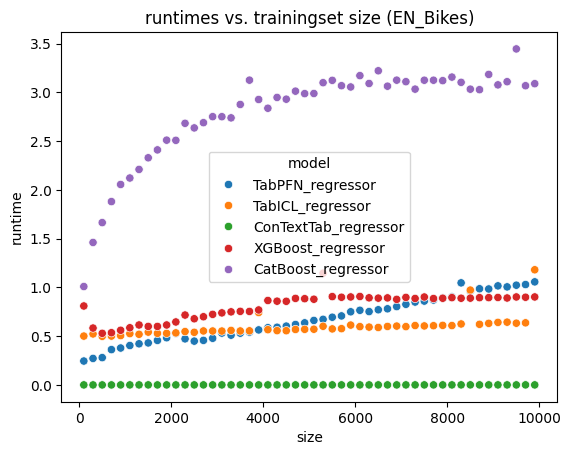

In [48]:
data_points = reg_model_comparison2(iterations, "Covered distance (m)", [reg_EN_Bikes_train, GBDT_reg_EN_Bikes_train], [reg_EN_Bikes_test, GBDT_reg_EN_Bikes_test], [TabPFN_regressor, TabICL_regressor, ConTextTab_regressor, xgb_regressor, cb_regressor], ["EN_Bikes"], ["TabPFN_regressor", "TabICL_regressor", "ConTextTab_regressor", "XGBoost_regressor", "CatBoost_regressor"], k_folds, False)
create_scatterplot(data_points,"EN_Bikes")
create_scatterplot_runtimes(data_points,"EN_Bikes")

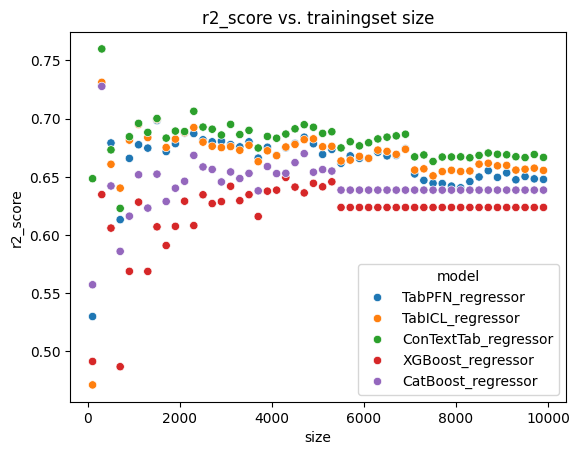

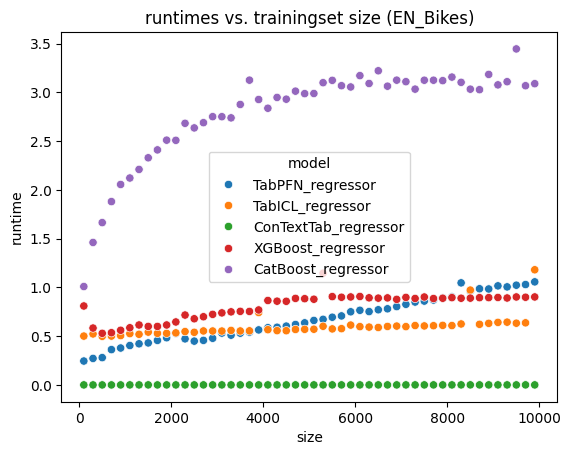

In [49]:
create_scatterplot(data_points,"EN_Bikes")
create_scatterplot_runtimes(data_points,"EN_Bikes")

In [52]:
data_points = reg_model_comparison2(iterations, "Ilman lämpötila keskiarvo (°C)", [FI_kumpula_train, GBDT_FI_kumpula_train], [FI_kumpula_test, GBDT_FI_kumpula_test], [TabPFN_regressor, TabICL_regressor, ConTextTab_regressor, xgb_regressor, cb_regressor], ["FI_kumpula"], ["TabPFN_regressor", "TabICL_regressor", "ConTextTab_regressor", "XGBoost_regressor", "CatBoost_regressor"], k_folds, False)

Training set size: 100, Mean R2 score: 0.6976953468064027, Standard deviation: 0.09878138017948264
Total runtime for model fitting: 0.23865485191345215 seconds
Training set size: 300, Mean R2 score: 0.829073657849106, Standard deviation: 0.03313252216884849
Total runtime for model fitting: 0.26130104064941406 seconds
Training set size: 500, Mean R2 score: 0.8520208974329494, Standard deviation: 0.024859339680556727
Total runtime for model fitting: 0.27524781227111816 seconds
Training set size: 700, Mean R2 score: 0.8746727051315734, Standard deviation: 0.019760789760789304
Total runtime for model fitting: 0.2928149700164795 seconds
Training set size: 900, Mean R2 score: 0.8931121929170077, Standard deviation: 0.018576108034923412
Total runtime for model fitting: 0.31385302543640137 seconds
Training set size: 1100, Mean R2 score: 0.8927622972662966, Standard deviation: 0.015606462373398864
Total runtime for model fitting: 0.3277859687805176 seconds
Training set size: 1300, Mean R2 score

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Training set size: 9900, Mean R2 score: 0.977645068464345, Standard deviation: 0.0008404985135027515
Total runtime for model fitting: 0.0005936622619628906 seconds
Training set size: 100, Mean R2 score: 0.6643448429636191, Standard deviation: 0.16591107660739696
Total runtime for model fitting: 0.05655169486999512 seconds
Training set size: 300, Mean R2 score: 0.8194953842397817, Standard deviation: 0.041297728891418486
Total runtime for model fitting: 0.10198497772216797 seconds
Training set size: 500, Mean R2 score: 0.8522774201824357, Standard deviation: 0.03476614614499517
Total runtime for model fitting: 0.111785888671875 seconds
Training set size: 700, Mean R2 score: 0.8821818768990175, Standard deviation: 0.009878526943027903
Total runtime for model fitting: 0.12018537521362305 seconds
Training set size: 900, Mean R2 score: 0.891086940653276, Standard deviation: 0.015823783789333662
Total runtime for model fitting: 0.11869406700134277 seconds
Training set size: 1100, Mean R2 sco

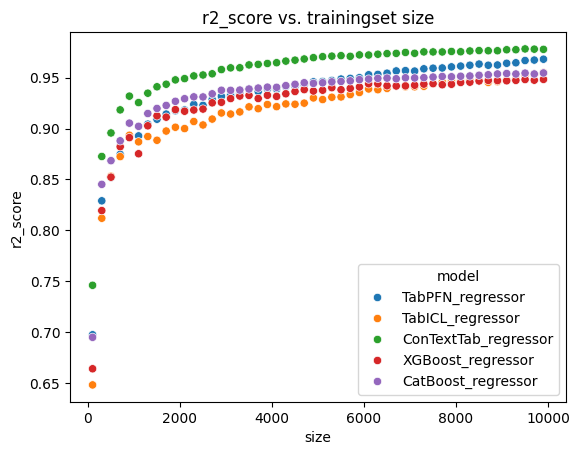

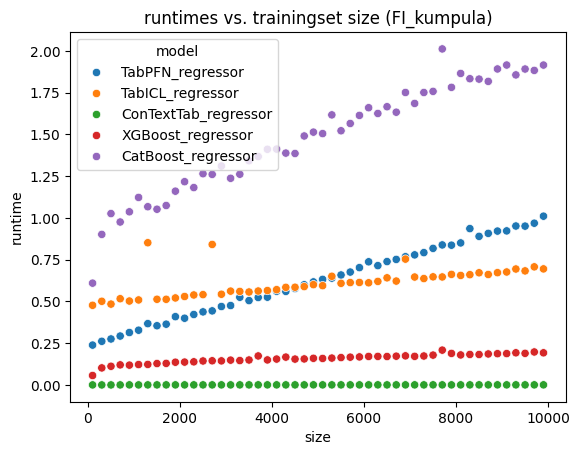

In [53]:
create_scatterplot(data_points,"FI_kumpula")
create_scatterplot_runtimes(data_points,"FI_kumpula")